In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("journée data/data 2021-2026 journée mondiale du handicap.csv", sep=";")

# convertir la date
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# créer les séries temporelles par keyword
ts = df.pivot_table(
    index="date",
    columns="keyword",
    values="interest"
)

keywords = df["keyword"].unique()
print(keywords)
# liste keywords : ['Journée mondiale du handicap'
#  'Journée mondiale de lutte contre le cancer'
#  "Journée mondiale de lutte contre l'obésité"
#  'Journée mondiale de la trisomie 21'
#  'Journée mondiale de la santé mentale']"

ts_handicap = df[df["keyword"]=="JournÃ©e mondiale du handicap"] \
                .set_index("date")["interest"]


['JournÃ©e mondiale du handicap'
 'JournÃ©e mondiale de lutte contre le cancer'
 "JournÃ©e mondiale de lutte contre l'obÃ©sitÃ©"
 'JournÃ©e mondiale de la trisomie 21'
 'JournÃ©e mondiale de la santÃ© mentale']


In [45]:
def detect_anomalies(series, window_size=10, threshold=3):

    anomalies = []
    
    values = series.values
    dates = series.index

    for t in range(window_size, len(series)):
        window = series[t-window_size:t]

        mean = np.mean(window)
        std = np.std(window)

        if std == 0:
            continue

        z_score = (values[t] - mean) / std

        if z_score > threshold:
            date_str = dates[t].strftime("%Y-%m-%d")
            anomalies.append(dates[t])

    return anomalies

Exemple handicap

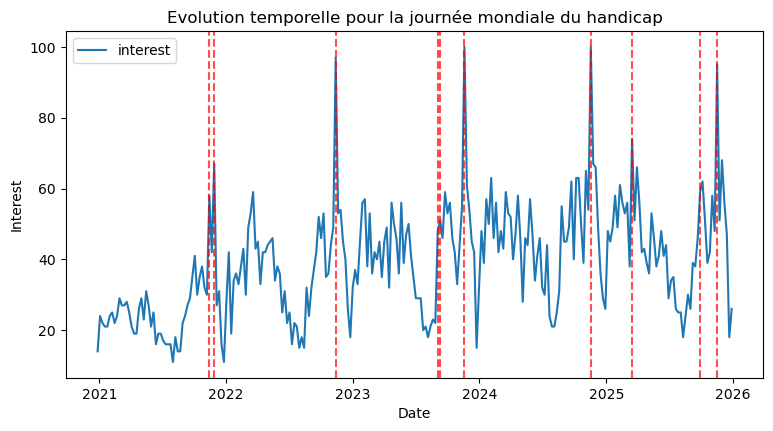

In [8]:
ts_handicap = df[df["keyword"]=="JournÃ©e mondiale du handicap"] \
                .set_index("date")["interest"]
                
anomalies = detect_anomalies(ts_handicap)
plt.figure(figsize=(9,4.5))
plt.plot(ts_handicap.index, ts_handicap.values, label="interest")
for d in anomalies : 
    plt.axvline(x=d, color="red", linestyle="--", alpha=0.7)
    plt.xlabel("Date")
    plt.ylabel("Interest")
    plt.title("Evolution temporelle pour la journée mondiale du handicap")
    plt.legend()

plt.show()

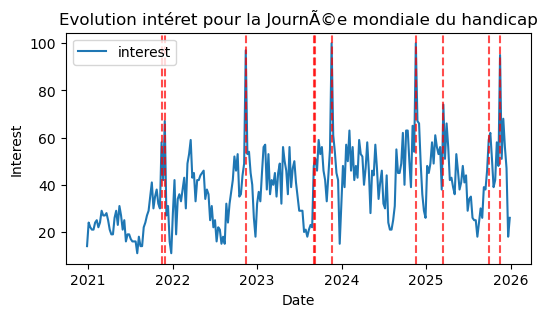

[Timestamp('2021-11-14 00:00:00'), Timestamp('2021-11-28 00:00:00'), Timestamp('2022-11-13 00:00:00'), Timestamp('2023-09-03 00:00:00'), Timestamp('2023-09-10 00:00:00'), Timestamp('2023-11-19 00:00:00'), Timestamp('2024-11-17 00:00:00'), Timestamp('2025-03-16 00:00:00'), Timestamp('2025-09-28 00:00:00'), Timestamp('2025-11-16 00:00:00')]


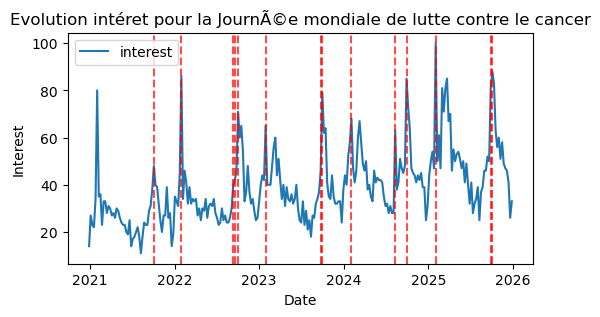

[Timestamp('2021-10-03 00:00:00'), Timestamp('2022-01-30 00:00:00'), Timestamp('2022-09-11 00:00:00'), Timestamp('2022-09-18 00:00:00'), Timestamp('2022-10-02 00:00:00'), Timestamp('2023-01-29 00:00:00'), Timestamp('2023-09-24 00:00:00'), Timestamp('2023-10-01 00:00:00'), Timestamp('2024-02-04 00:00:00'), Timestamp('2024-08-11 00:00:00'), Timestamp('2024-09-29 00:00:00'), Timestamp('2025-02-02 00:00:00'), Timestamp('2025-09-28 00:00:00'), Timestamp('2025-10-05 00:00:00')]


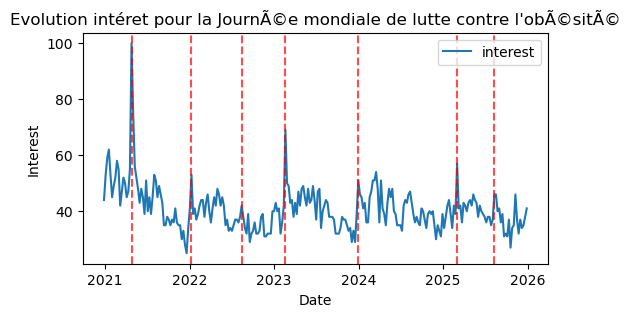

[Timestamp('2021-04-25 00:00:00'), Timestamp('2022-01-09 00:00:00'), Timestamp('2022-08-14 00:00:00'), Timestamp('2023-02-19 00:00:00'), Timestamp('2023-12-31 00:00:00'), Timestamp('2025-03-02 00:00:00'), Timestamp('2025-08-10 00:00:00')]


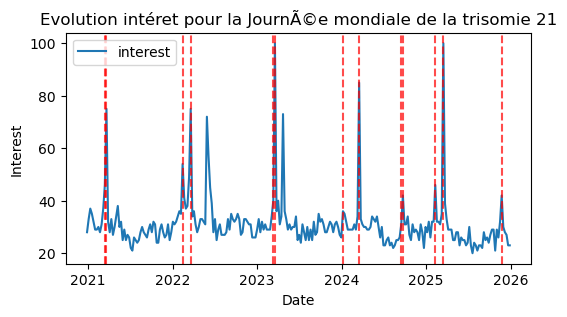

[Timestamp('2021-03-14 00:00:00'), Timestamp('2021-03-21 00:00:00'), Timestamp('2022-02-13 00:00:00'), Timestamp('2022-03-20 00:00:00'), Timestamp('2023-03-12 00:00:00'), Timestamp('2023-03-19 00:00:00'), Timestamp('2024-01-07 00:00:00'), Timestamp('2024-03-17 00:00:00'), Timestamp('2024-09-15 00:00:00'), Timestamp('2024-09-22 00:00:00'), Timestamp('2025-02-09 00:00:00'), Timestamp('2025-03-16 00:00:00'), Timestamp('2025-11-23 00:00:00')]


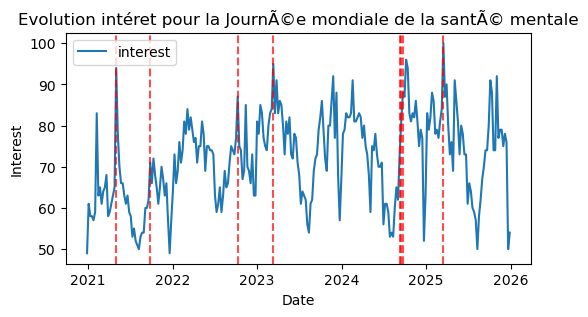

[Timestamp('2021-05-02 00:00:00'), Timestamp('2021-09-26 00:00:00'), Timestamp('2022-10-09 00:00:00'), Timestamp('2023-03-12 00:00:00'), Timestamp('2024-09-08 00:00:00'), Timestamp('2024-09-15 00:00:00'), Timestamp('2024-09-22 00:00:00'), Timestamp('2025-03-16 00:00:00')]


In [9]:
for key in keywords:
    tsk = df[df["keyword"]==key].set_index("date")["interest"]
    anomalies = detect_anomalies(tsk)
    plt.figure(figsize=(6,3))
    plt.plot(tsk.index, tsk.values, label="interest")
    for d in anomalies : 
        plt.axvline(x=d, color="red", linestyle="--", alpha=0.7)
        plt.xlabel("Date")
        plt.ylabel("Interest")
        plt.title(f"Evolution intéret pour la {key}")
        plt.legend()

    plt.show()
    print(anomalies)

handicap : 3 décembre /
cancer : 4 février /
obésité : 4 mars /
trisomie 21 : 21 mars /
santé mentale : 10 octobre

Comparaison media cloud / Google trend

In [10]:
df_google_trend = pd.read_csv("google_trends_health_FR_weekly_2021_2026.csv")

# convertir la date
df_google_trend["date"] = pd.to_datetime(df_google_trend["date"], dayfirst=True)

# créer les séries temporelles par keyword
ts_ggl_t = df_google_trend.pivot_table(
    index="date",
    columns="keyword",
    values="interest"
)

df_media_cloud = pd.read_csv("mediacloud_health_FR_2021_2026.csv", sep=",")

# convertir la date
df_media_cloud["date"] = pd.to_datetime(df_media_cloud["date"], dayfirst=True)

# créer les séries temporelles par keyword
ts_md = df_media_cloud.pivot_table(
    index="date",
    columns="keyword",
    values="count"
)

KeyError: 'date'

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [27]:

def run_sarima(series, order=None, seasonal_order=None, s=52, forecast_steps=12, test_size=52):

    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.seasonal import STL
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    # ── Auto ARIMA si les ordres ne sont pas spécifiés ────
    if order is None or seasonal_order is None:
        from pmdarima import auto_arima
        print("Recherche automatique des ordres avec auto_arima...")
        auto_model = auto_arima(
            series[:-test_size],
            seasonal=True, m=s,
            stepwise=True, trace=True,
            information_criterion='aic',
            error_action='ignore',
            suppress_warnings=True
        )
        order          = auto_model.order
        seasonal_order = auto_model.seasonal_order
        print(f"\nOrdres retenus → order={order}, seasonal_order={seasonal_order}")

    # ── Décomposition STL ──────────────────────────────────
    stl      = STL(series, period=s, robust=True)
    stl_fit  = stl.fit()
    trend    = stl_fit.trend
    seasonal = stl_fit.seasonal
    residual = stl_fit.resid

    # ── Split ──────────────────────────────────────────────
    train = series[:-test_size]
    test  = series[-test_size:]

    # ── Entraînement ───────────────────────────────────────
    model  = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    result = model.fit(disp=False)
    print(result.summary())

    # ── Prévisions sur le test ─────────────────────────────
    forecast = result.get_forecast(steps=test_size)
    pred     = forecast.predicted_mean
    ci       = forecast.conf_int(alpha=0.05)

    # ── Métriques ──────────────────────────────────────────
    mae  = mean_absolute_error(test, pred)
    rmse = np.sqrt(mean_squared_error(test, pred))
    mape = np.mean(np.abs((test - pred) / test)) * 100
    print(f"\nMAE  : {mae:.3f}  |  RMSE : {rmse:.3f}  |  MAPE : {mape:.2f}%")

    # ── Graphique SARIMA ───────────────────────────────────
    plt.figure(figsize=(12, 5))
    train[-test_size*2:].plot(label="Train")
    test.plot(label="Réel", color="black")
    pred.plot(label="Prévision", color="red")
    plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1],
                     alpha=0.2, color="red", label="IC 95%")
    plt.title("SARIMA — Prévisions vs Réel")
    plt.legend(); plt.tight_layout(); plt.show()

    # ── Graphique Décomposition STL ────────────────────────
    fig, axes = plt.subplots(4, 1, figsize=(12, 10))
    series.plot(ax=axes[0],   title="Observed",  color="steelblue")
    trend.plot(ax=axes[1],    title="Trend",     color="orange")
    seasonal.plot(ax=axes[2], title="Seasonal",  color="green")
    residual.plot(ax=axes[3], title="Residual",  color="red")
    plt.suptitle("Décomposition STL", fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

    return result, pred, trend, seasonal, residual




In [4]:
# Option 1 — auto_arima choisit tout automatiquement

result, predictions = run_sarima(
    series    = ts_handicap,   # ← votre pd.Series ici
    s         = 52,         # ← 52 pour hebdomadaire
    test_size = 52
)


NameError: name 'ts_handicap' is not defined

sARIMA sur les 4 campagne mensuel sur 10 ans

In [28]:
#importer les données

df = pd.read_csv("google_trends_monthly_1103.csv", sep=",")


# convertir la date
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.day

df["year_month"] = df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2)
df["year_month"] = pd.to_datetime(df["year_month"], format="%Y-%m")

# créer les séries temporelles par keyword
ts_m = df.groupby(["year_month", "campaign"])["interest"].mean().unstack()

ts_m.index = pd.to_datetime(ts_m.index)


# liste campaign : 
# ['Dry January'
#  'Mars Bleu' 
#  'Movember'
#  'Octobre Rose']


GT_dry_january = ts_m["Dry January"]
GT_Mars_bleu = ts_m["Mars Bleu"]
GT_Movember = ts_m["Movember"]
GT_Octobre_rose = ts_m["Octobre Rose"]
                


In [29]:
#importer les données

df = pd.read_csv("mediacloud_monthly_1103.csv", sep=",")


# convertir la date
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.day

df["year_month"] = df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2)
df["year_month"] = pd.to_datetime(df["year_month"], format="%Y-%m")

# créer les séries temporelles par keyword
ts_m = df.groupby(["year_month", "campaign"])["count"].mean().unstack()

ts_m.index = pd.to_datetime(ts_m.index)


# liste campaign : 
# ['Dry January'
#  'Mars Bleu' 
#  'Movember'
#  'Octobre Rose']


MC_dry_january = ts_m["Dry January"]
MC_Mars_bleu = ts_m["Mars Bleu"]
MC_Movember = ts_m["Movember"]
MC_Octobre_rose = ts_m["Octobre Rose"]



Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=632.853, Time=2.48 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=636.923, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=631.372, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=630.156, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=641.551, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=631.872, Time=0.16 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=629.036, Time=0.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=631.974, Time=0.30 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=629.068, Time=1.05 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=629.951, Time=1.62 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=628.064, Time=0.72 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=634.824, Time=0.50 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=629.512, Time=0.66 sec
 ARIMA(0,0,2)(0,1,2)[12] intercept   : AIC=629.

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=632.853, Time=2.48 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=636.923, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=631.372, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=630.156, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=641.551, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=631.872, Time=0.16 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=629.036, Time=0.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=631.974, Time=0.30 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=629.068, Time=1.05 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=629.951, Time=1.62 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=628.064, Time=0.72 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=634.824, Time=0.50 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=629.512, Time=0.66 sec
 ARIMA(0,0,2)(0,1,2)[12] intercept   : AIC=629.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=632.853, Time=2.48 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=636.923, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=631.372, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=630.156, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=641.551, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=631.872, Time=0.16 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=629.036, Time=0.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=631.974, Time=0.30 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=629.068, Time=1.05 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=629.951, Time=1.62 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=628.064, Time=0.72 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=634.824, Time=0.50 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=629.512, Time=0.66 sec
 ARIMA(0,0,2)(0,1,2)[12] intercept   : AIC=629.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                        SARIMAX Results                                        
Dep. Variable:                             Dry January   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 12)   Log Likelihood                -239.753
Date:                                 Mon, 16 Mar 2026   AIC                            487.506
Time:                                         14:50:37   BIC                            496.613
Sample:                                     01-01-2015   HQIC                           491.132
                                          - 01-01-2024                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3802      0.077      4.929      0.000       0.229       0

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=632.853, Time=2.48 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=636.923, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=631.372, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=630.156, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=641.551, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=631.872, Time=0.16 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=629.036, Time=0.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=631.974, Time=0.30 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=629.068, Time=1.05 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=629.951, Time=1.62 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=628.064, Time=0.72 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=634.824, Time=0.50 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=629.512, Time=0.66 sec
 ARIMA(0,0,2)(0,1,2)[12] intercept   : AIC=629.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                        SARIMAX Results                                        
Dep. Variable:                             Dry January   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 12)   Log Likelihood                -239.753
Date:                                 Mon, 16 Mar 2026   AIC                            487.506
Time:                                         14:50:37   BIC                            496.613
Sample:                                     01-01-2015   HQIC                           491.132
                                          - 01-01-2024                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3802      0.077      4.929      0.000       0.229       0

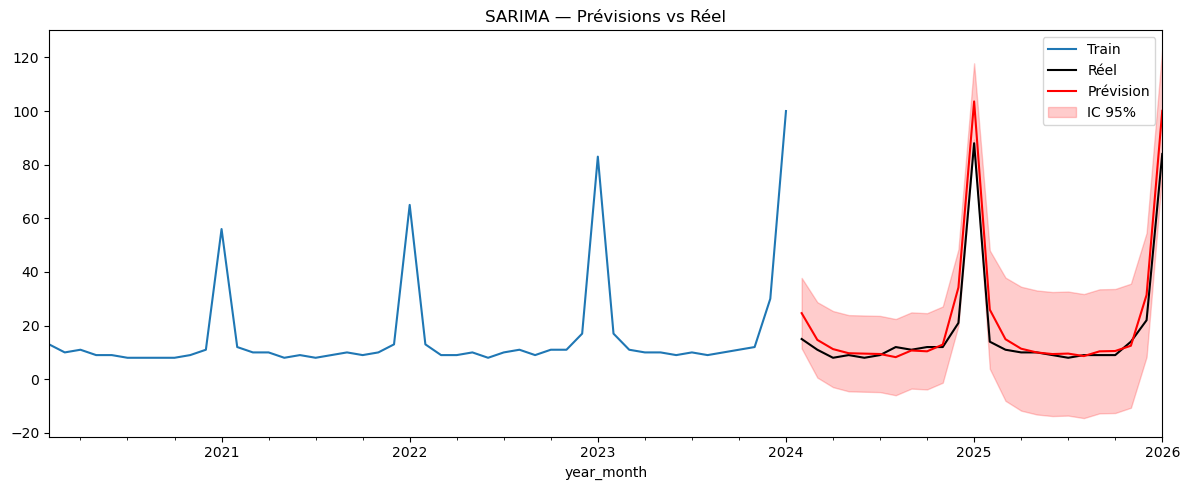

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=632.853, Time=2.48 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=636.923, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=631.372, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=630.156, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=641.551, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=631.872, Time=0.16 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=629.036, Time=0.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=631.974, Time=0.30 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=629.068, Time=1.05 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=629.951, Time=1.62 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=628.064, Time=0.72 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=634.824, Time=0.50 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=629.512, Time=0.66 sec
 ARIMA(0,0,2)(0,1,2)[12] intercept   : AIC=629.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                        SARIMAX Results                                        
Dep. Variable:                             Dry January   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 12)   Log Likelihood                -239.753
Date:                                 Mon, 16 Mar 2026   AIC                            487.506
Time:                                         14:50:37   BIC                            496.613
Sample:                                     01-01-2015   HQIC                           491.132
                                          - 01-01-2024                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3802      0.077      4.929      0.000       0.229       0

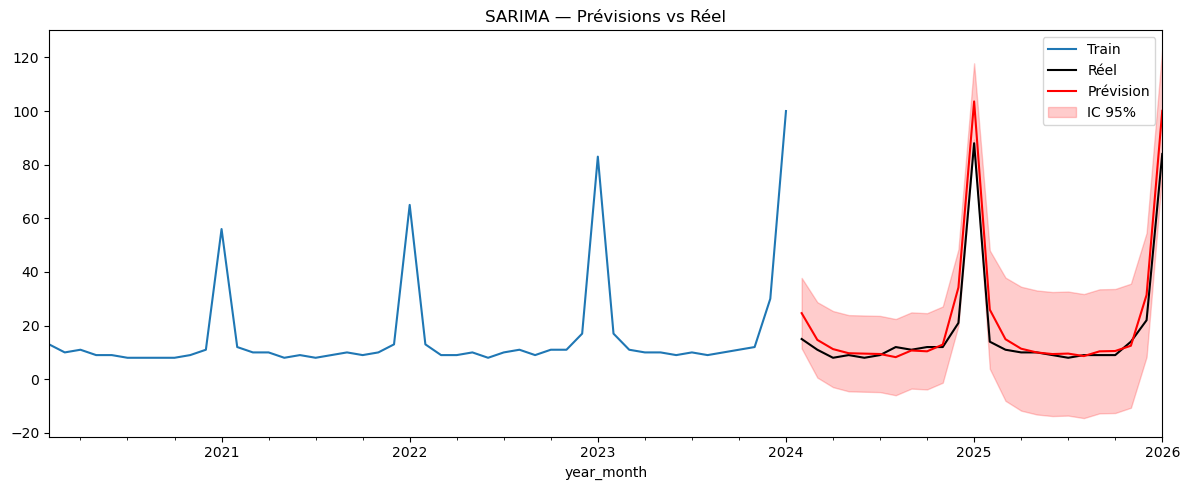

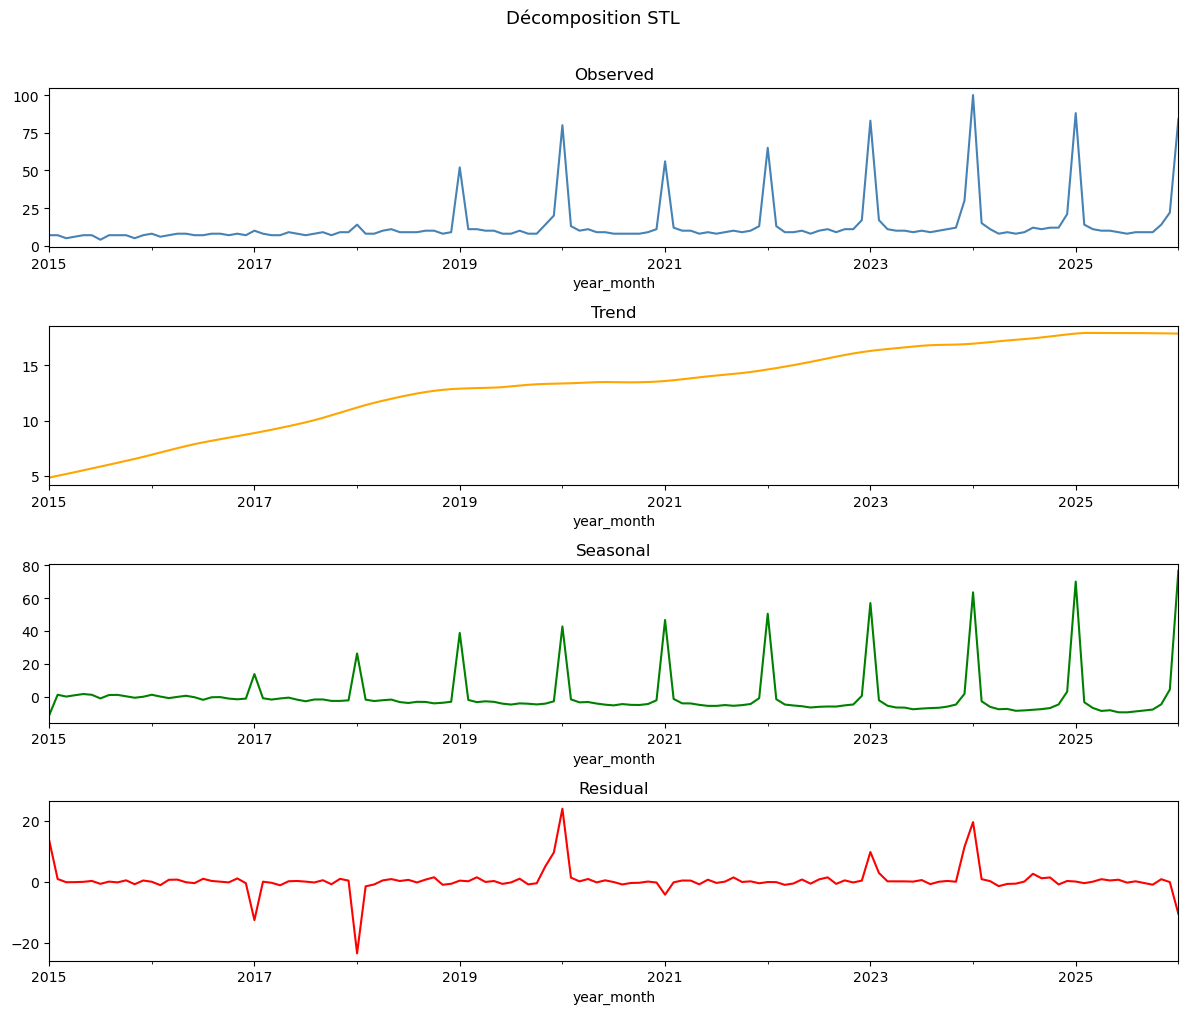

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=632.853, Time=2.48 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=636.923, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=631.372, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=630.156, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=641.551, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=631.872, Time=0.16 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=629.036, Time=0.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=631.974, Time=0.30 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=629.068, Time=1.05 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=629.951, Time=1.62 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=628.064, Time=0.72 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=634.824, Time=0.50 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=629.512, Time=0.66 sec
 ARIMA(0,0,2)(0,1,2)[12] intercept   : AIC=629.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                        SARIMAX Results                                        
Dep. Variable:                             Dry January   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 12)   Log Likelihood                -239.753
Date:                                 Mon, 16 Mar 2026   AIC                            487.506
Time:                                         14:50:37   BIC                            496.613
Sample:                                     01-01-2015   HQIC                           491.132
                                          - 01-01-2024                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3802      0.077      4.929      0.000       0.229       0

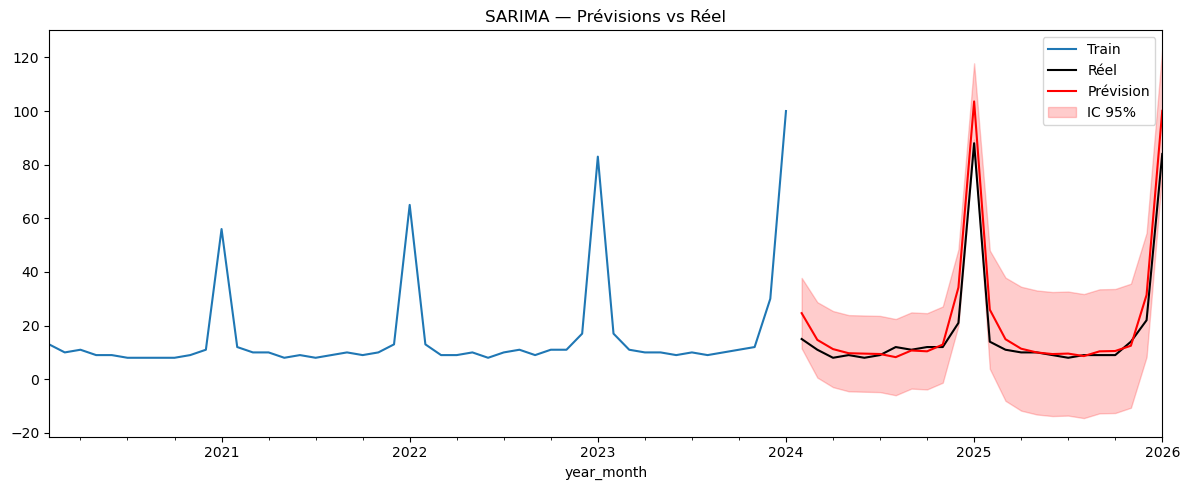

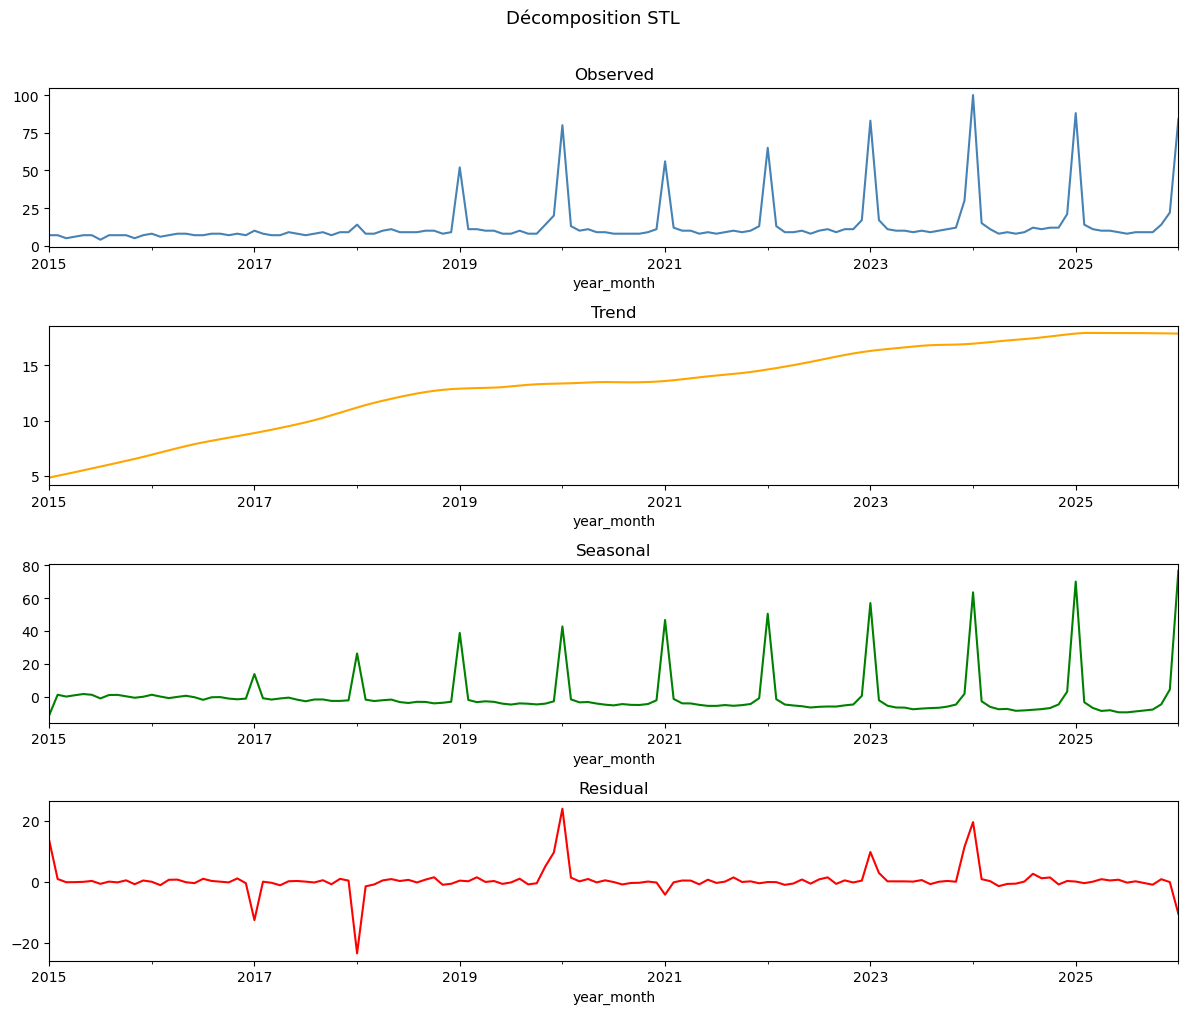

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.18 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1318.370, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1321.019, Time=0.54 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1321.652, Time=0.42 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1325.334, Time=0.03 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1320.039, Time=0.15 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1320.220, Time=0.05 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1320.013, Time=0.03 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=1320.028, Time=0.07 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=1321.941, Time=0.19 sec

Best model:  ARIMA(0,0,0)(0,1,0)[12] intercept
Total fit time: 3.242 seconds

Ordres retenus → order=(0, 0, 0), seasonal_order=(0, 1, 0, 12)
                                SARI

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=632.853, Time=2.48 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=636.923, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=631.372, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=630.156, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=641.551, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=631.872, Time=0.16 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=629.036, Time=0.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=631.974, Time=0.30 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=629.068, Time=1.05 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=629.951, Time=1.62 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=628.064, Time=0.72 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=634.824, Time=0.50 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=629.512, Time=0.66 sec
 ARIMA(0,0,2)(0,1,2)[12] intercept   : AIC=629.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                        SARIMAX Results                                        
Dep. Variable:                             Dry January   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 12)   Log Likelihood                -239.753
Date:                                 Mon, 16 Mar 2026   AIC                            487.506
Time:                                         14:50:37   BIC                            496.613
Sample:                                     01-01-2015   HQIC                           491.132
                                          - 01-01-2024                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3802      0.077      4.929      0.000       0.229       0

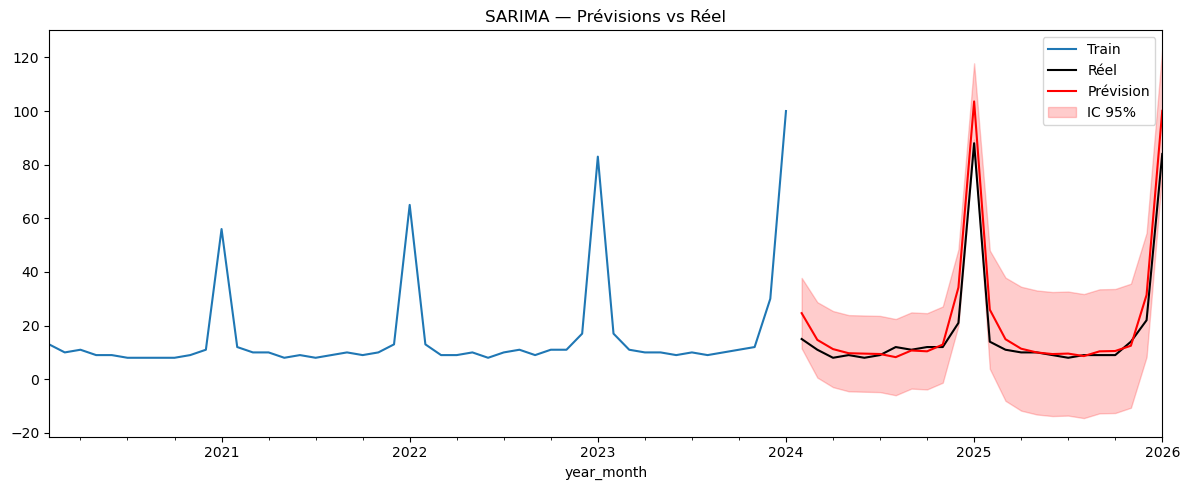

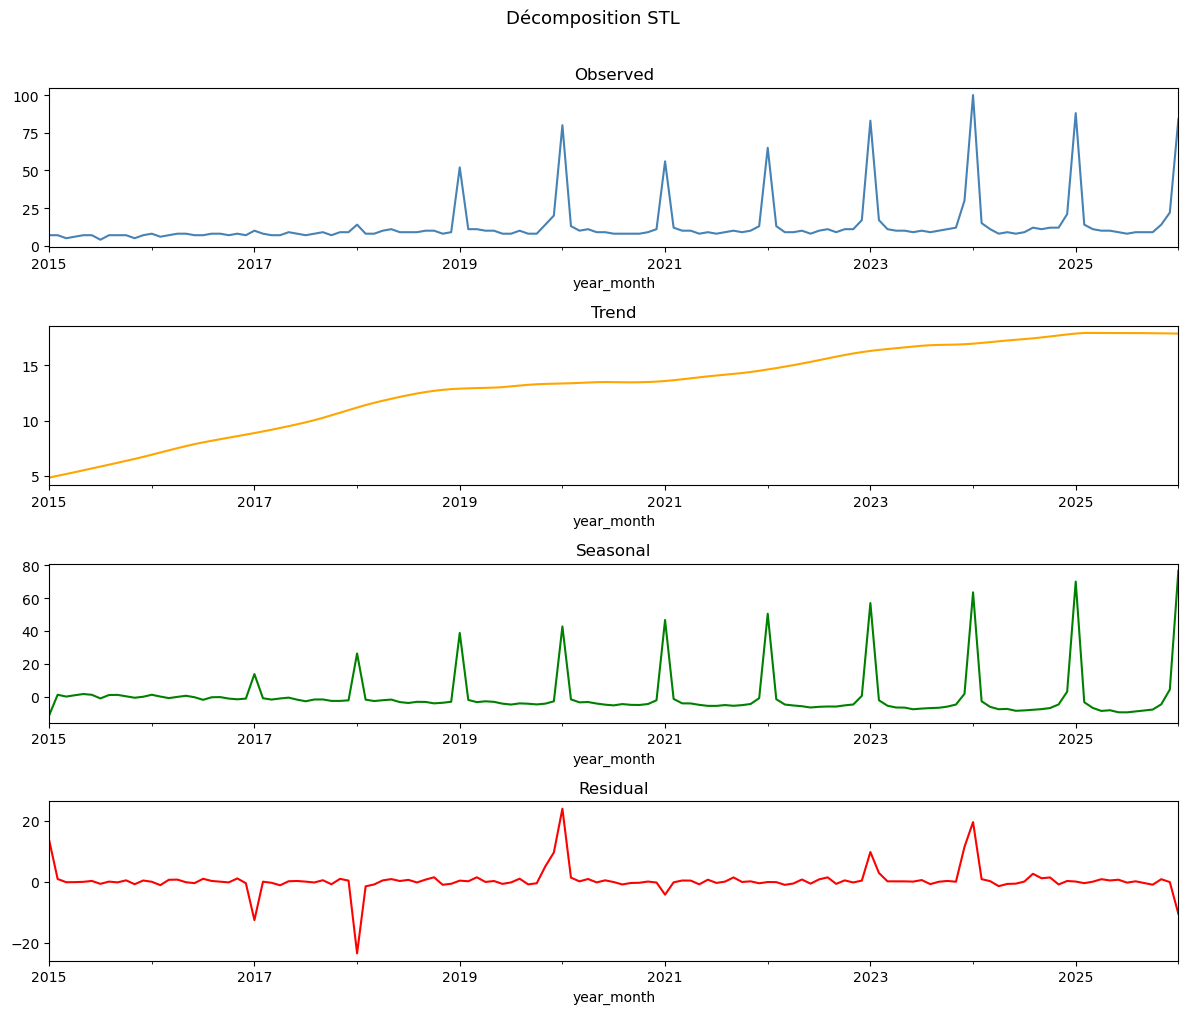

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.18 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1318.370, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1321.019, Time=0.54 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1321.652, Time=0.42 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1325.334, Time=0.03 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1320.039, Time=0.15 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1320.220, Time=0.05 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1320.013, Time=0.03 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=1320.028, Time=0.07 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=1321.941, Time=0.19 sec

Best model:  ARIMA(0,0,0)(0,1,0)[12] intercept
Total fit time: 3.242 seconds

Ordres retenus → order=(0, 0, 0), seasonal_order=(0, 1, 0, 12)
                                SARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=632.853, Time=2.48 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=636.923, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=631.372, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=630.156, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=641.551, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=631.872, Time=0.16 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=629.036, Time=0.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=631.974, Time=0.30 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=629.068, Time=1.05 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=629.951, Time=1.62 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=628.064, Time=0.72 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=634.824, Time=0.50 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=629.512, Time=0.66 sec
 ARIMA(0,0,2)(0,1,2)[12] intercept   : AIC=629.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                        SARIMAX Results                                        
Dep. Variable:                             Dry January   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 12)   Log Likelihood                -239.753
Date:                                 Mon, 16 Mar 2026   AIC                            487.506
Time:                                         14:50:37   BIC                            496.613
Sample:                                     01-01-2015   HQIC                           491.132
                                          - 01-01-2024                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3802      0.077      4.929      0.000       0.229       0

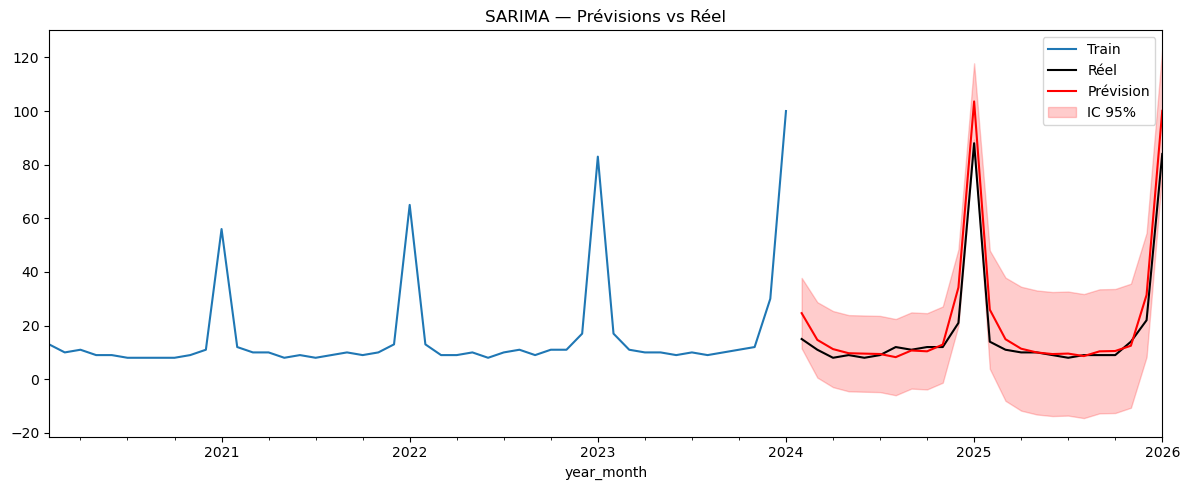

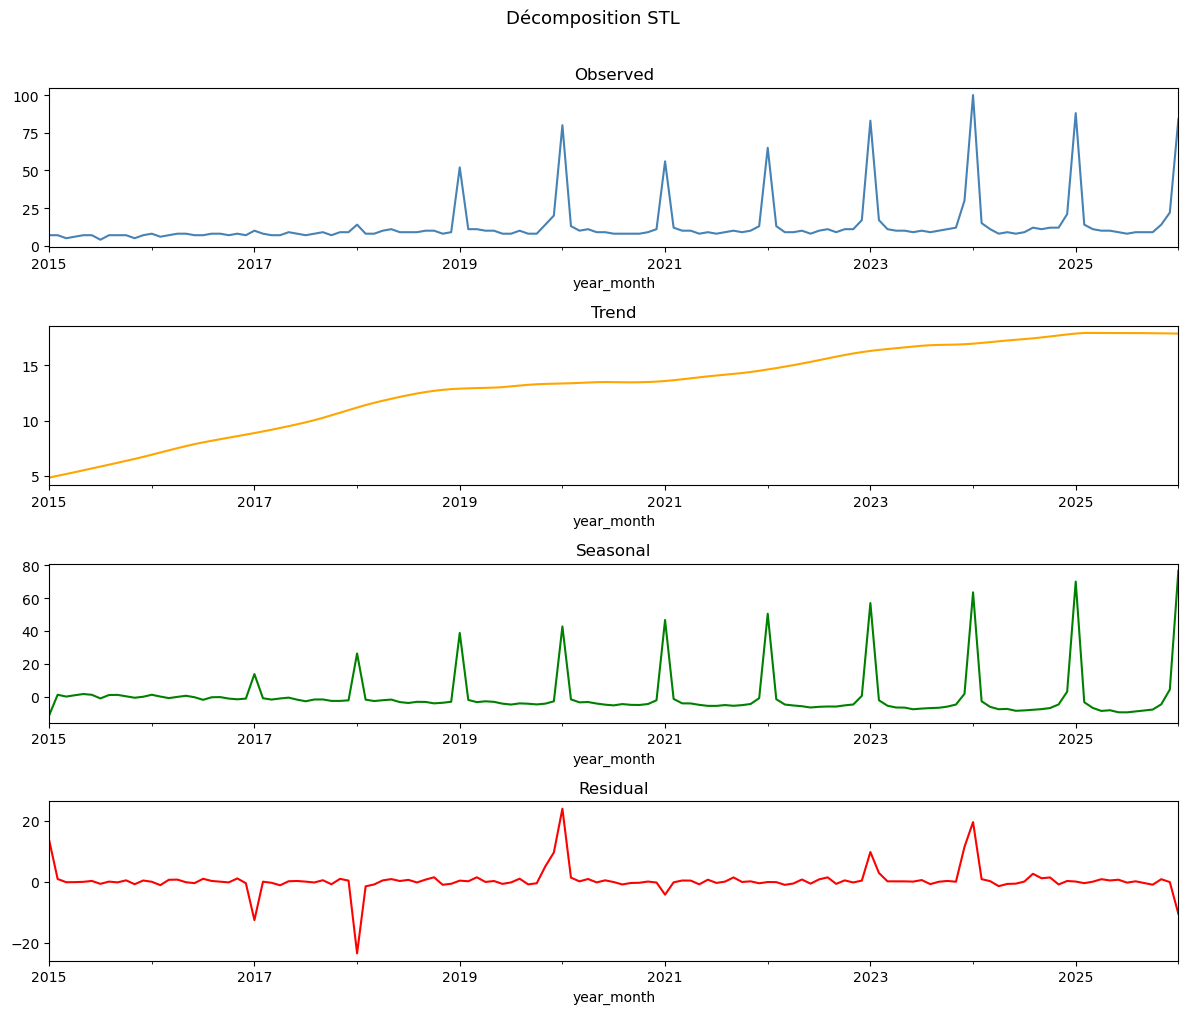

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.18 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1318.370, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1321.019, Time=0.54 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1321.652, Time=0.42 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1325.334, Time=0.03 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1320.039, Time=0.15 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1320.220, Time=0.05 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1320.013, Time=0.03 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=1320.028, Time=0.07 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=1321.941, Time=0.19 sec

Best model:  ARIMA(0,0,0)(0,1,0)[12] intercept
Total fit time: 3.242 seconds

Ordres retenus → order=(0, 0, 0), seasonal_order=(0, 1, 0, 12)
                                SARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


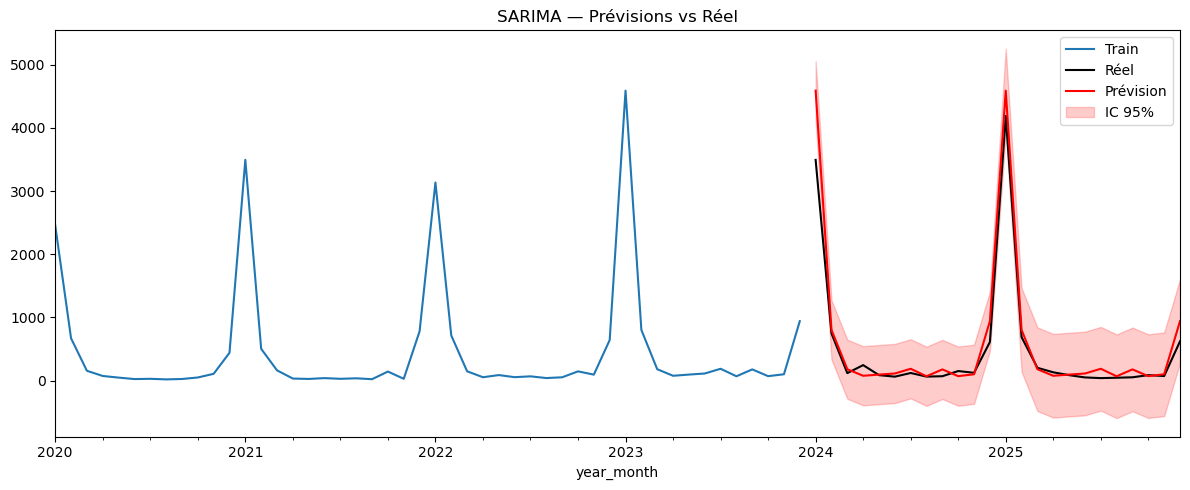

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=632.853, Time=2.48 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=636.923, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=631.372, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=630.156, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=641.551, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=631.872, Time=0.16 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=629.036, Time=0.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=631.974, Time=0.30 sec
 ARIMA(0,0,1)(2,1,1)[12] intercept   : AIC=629.068, Time=1.05 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=629.951, Time=1.62 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=628.064, Time=0.72 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=634.824, Time=0.50 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=629.512, Time=0.66 sec
 ARIMA(0,0,2)(0,1,2)[12] intercept   : AIC=629.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                        SARIMAX Results                                        
Dep. Variable:                             Dry January   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 12)   Log Likelihood                -239.753
Date:                                 Mon, 16 Mar 2026   AIC                            487.506
Time:                                         14:50:37   BIC                            496.613
Sample:                                     01-01-2015   HQIC                           491.132
                                          - 01-01-2024                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3802      0.077      4.929      0.000       0.229       0

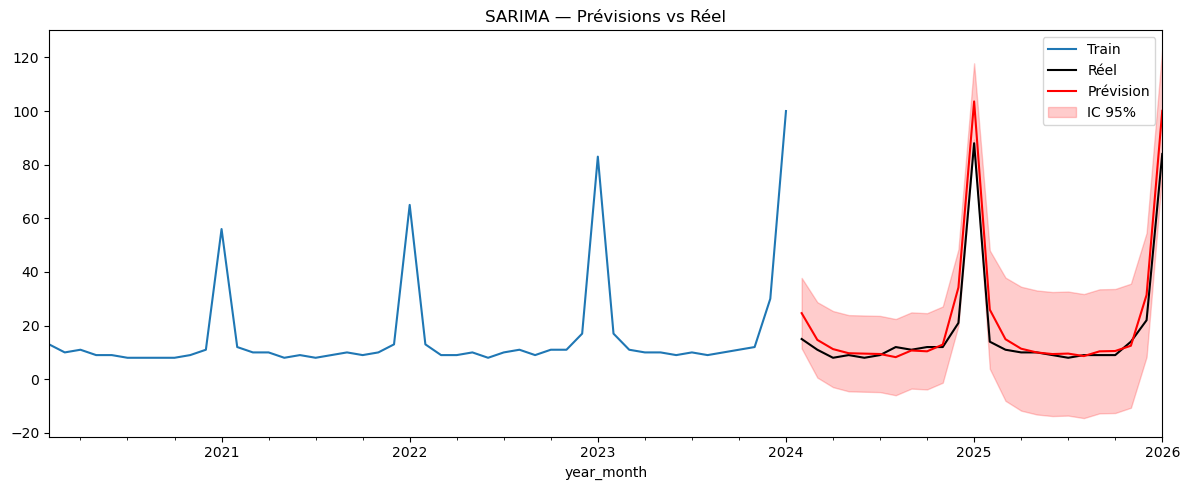

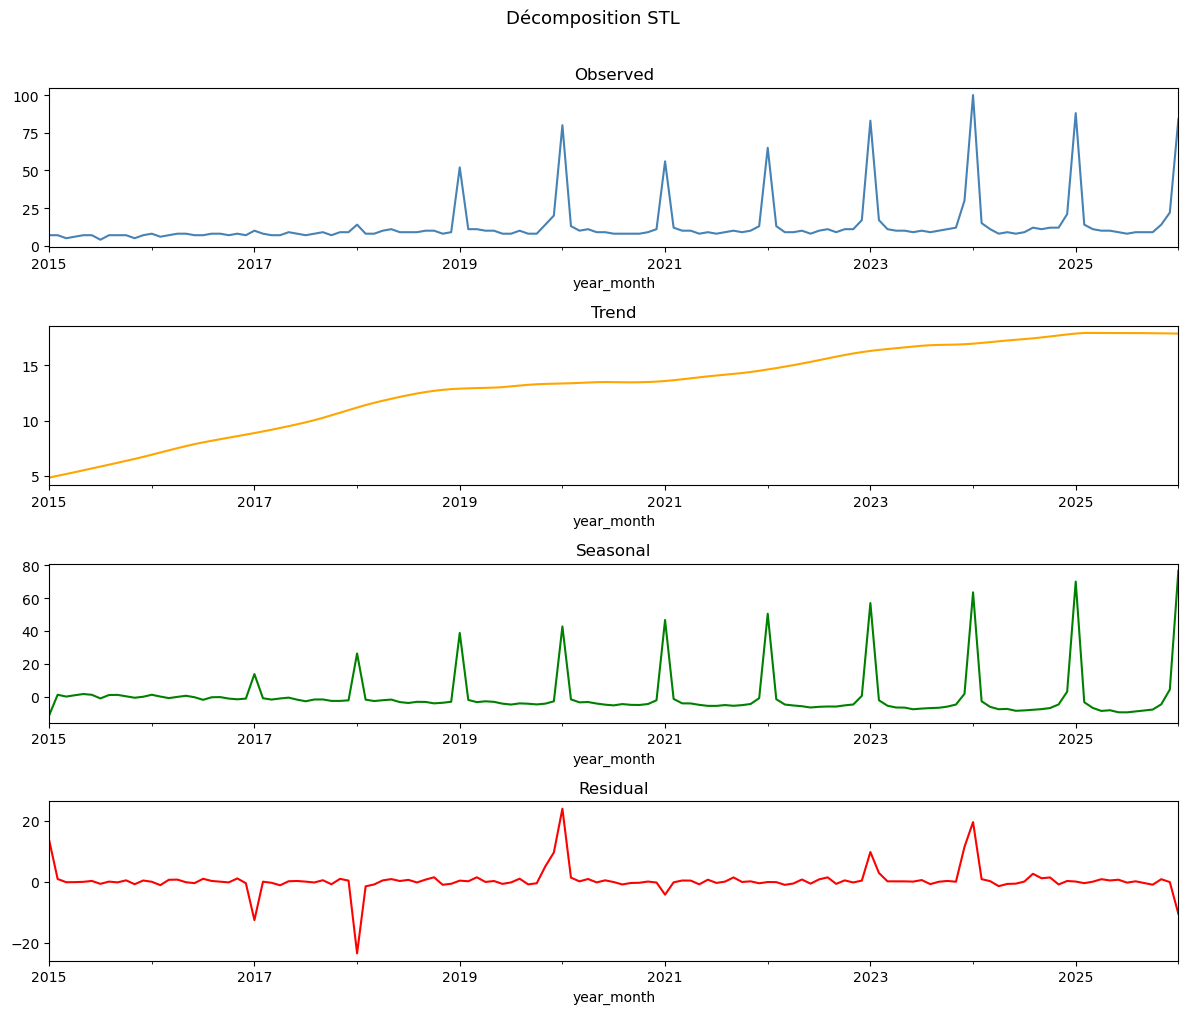

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.18 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1318.370, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1321.019, Time=0.54 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1321.652, Time=0.42 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1325.334, Time=0.03 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1320.039, Time=0.15 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1320.220, Time=0.05 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1320.013, Time=0.03 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=1320.028, Time=0.07 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=1321.941, Time=0.19 sec

Best model:  ARIMA(0,0,0)(0,1,0)[12] intercept
Total fit time: 3.242 seconds

Ordres retenus → order=(0, 0, 0), seasonal_order=(0, 1, 0, 12)
                                SARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


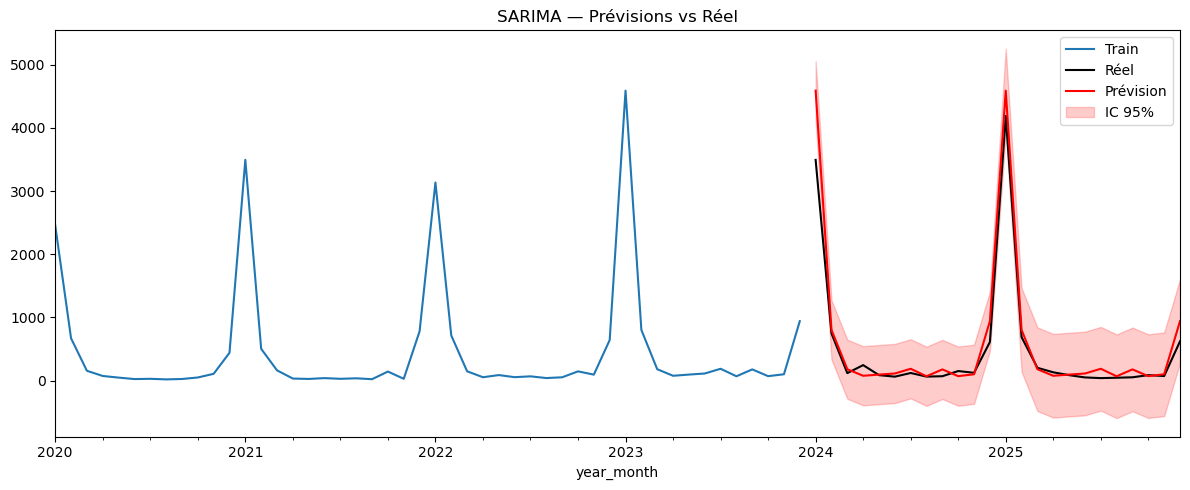

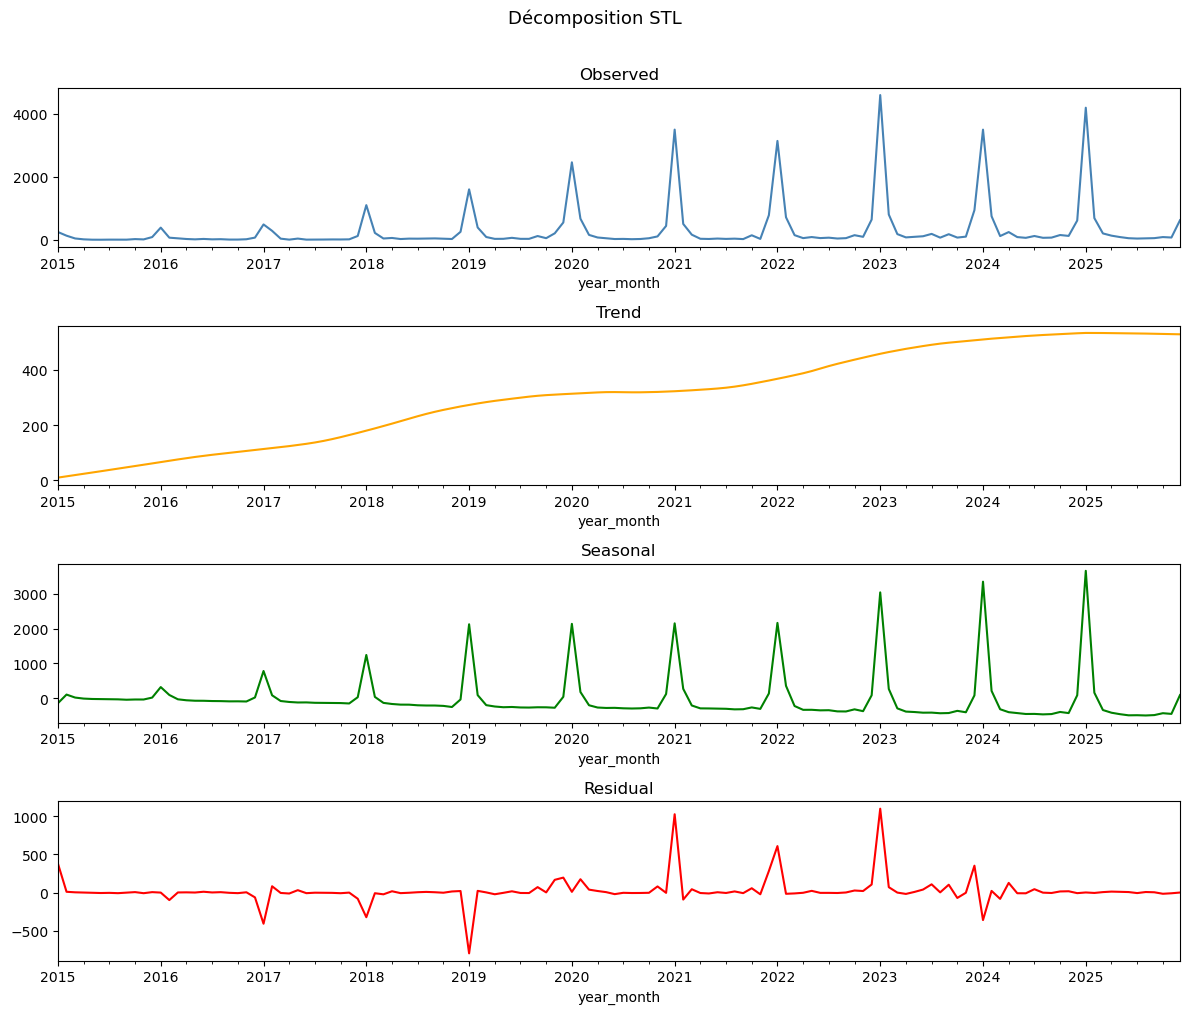

In [30]:
result_dry_gt, predictions_dry_gt, trend_dry_gt, seasonal_dry_gt, residual_dry_gt = run_sarima(
    series    = GT_dry_january,   # ← votre pd.Series ici
    s         = 12,         # ← 52 pour hebdomadaire
    test_size = 24
)

result_dry_mc, predictions_dry_mc, trend_dry_mc, seasonal_dry_mc, residual_dry_mc = run_sarima(
    series    = MC_dry_january,   # ← votre pd.Series ici
    s         = 12,         # ← 52 pour hebdomadaire
    test_size = 24
)

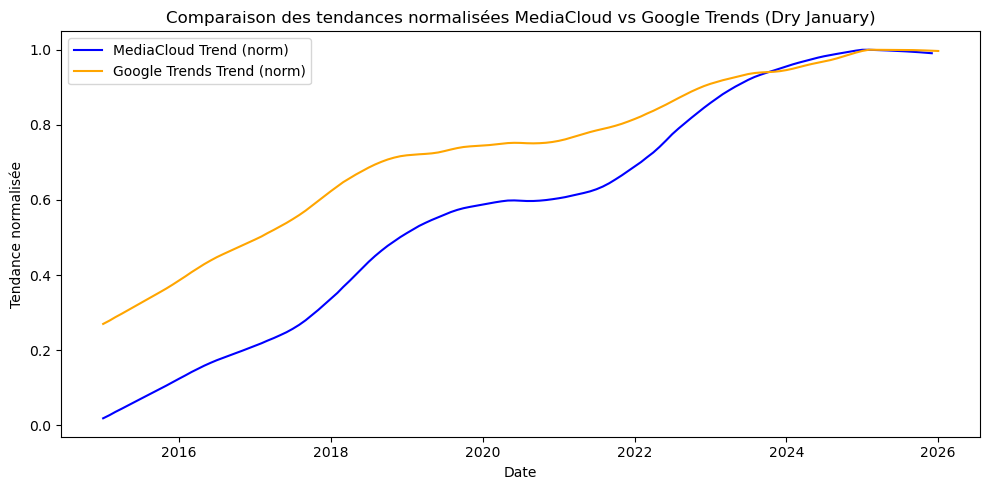

In [31]:
plt.figure(figsize=(10,5))

# Renormalisation
trend_mc_norm = trend_dry_mc / trend_dry_mc.max()
trend_gt_norm = trend_dry_gt / trend_dry_gt.max()

plt.plot(trend_mc_norm, label="MediaCloud Trend (norm)", color="blue")
plt.plot(trend_gt_norm, label="Google Trends Trend (norm)", color="orange")
plt.title("Comparaison des tendances normalisées MediaCloud vs Google Trends (Dry January)")
plt.xlabel("Date")
plt.ylabel("Tendance normalisée")
plt.legend()
plt.tight_layout()
plt.show()

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=901.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=817.175, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1125.756, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=889.928, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=714.444, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=716.902, Time=0.17 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=714.164, Time=1.03 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=732.820, Time=1.18 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARI

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=901.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=817.175, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1125.756, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=889.928, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=714.444, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=716.902, Time=0.17 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=714.164, Time=1.03 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=732.820, Time=1.18 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=901.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=817.175, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1125.756, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=889.928, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=714.444, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=716.902, Time=0.17 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=714.164, Time=1.03 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=732.820, Time=1.18 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                           Movember   No. Observations:                  109
Model:             SARIMAX(0, 0, 2)x(1, 0, 2, 12)   Log Likelihood                -254.198
Date:                            Mon, 16 Mar 2026   AIC                            520.397
Time:                                    14:51:03   BIC                            534.837
Sample:                                01-01-2015   HQIC                           526.194
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          4.8597      6.357      0.764      0.445      -7.600      17.319
ma.L2         11.6993     15.483   

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=901.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=817.175, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1125.756, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=889.928, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=714.444, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=716.902, Time=0.17 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=714.164, Time=1.03 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=732.820, Time=1.18 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                           Movember   No. Observations:                  109
Model:             SARIMAX(0, 0, 2)x(1, 0, 2, 12)   Log Likelihood                -254.198
Date:                            Mon, 16 Mar 2026   AIC                            520.397
Time:                                    14:51:03   BIC                            534.837
Sample:                                01-01-2015   HQIC                           526.194
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          4.8597      6.357      0.764      0.445      -7.600      17.319
ma.L2         11.6993     15.483   

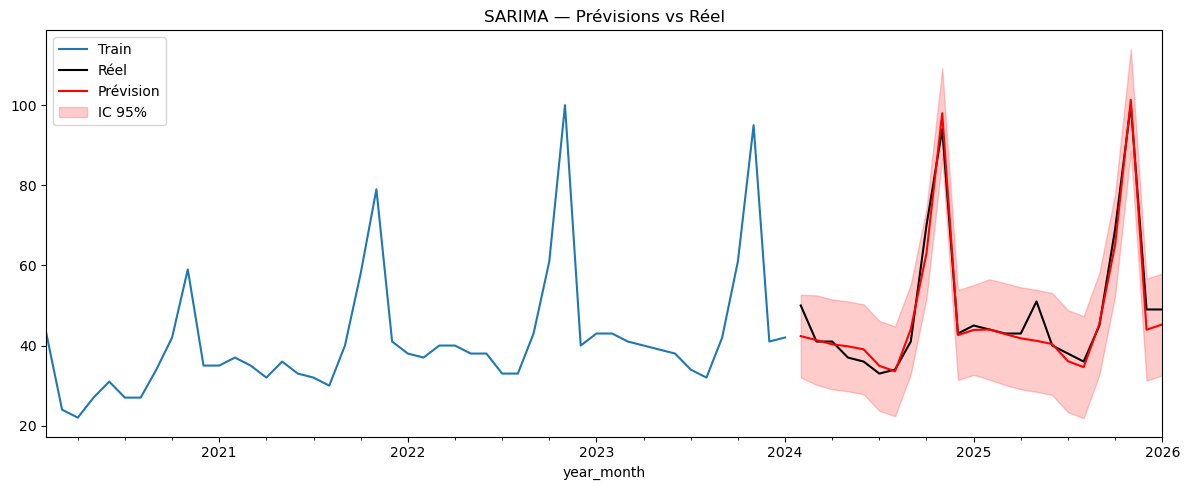

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=901.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=817.175, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1125.756, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=889.928, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=714.444, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=716.902, Time=0.17 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=714.164, Time=1.03 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=732.820, Time=1.18 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                           Movember   No. Observations:                  109
Model:             SARIMAX(0, 0, 2)x(1, 0, 2, 12)   Log Likelihood                -254.198
Date:                            Mon, 16 Mar 2026   AIC                            520.397
Time:                                    14:51:03   BIC                            534.837
Sample:                                01-01-2015   HQIC                           526.194
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          4.8597      6.357      0.764      0.445      -7.600      17.319
ma.L2         11.6993     15.483   

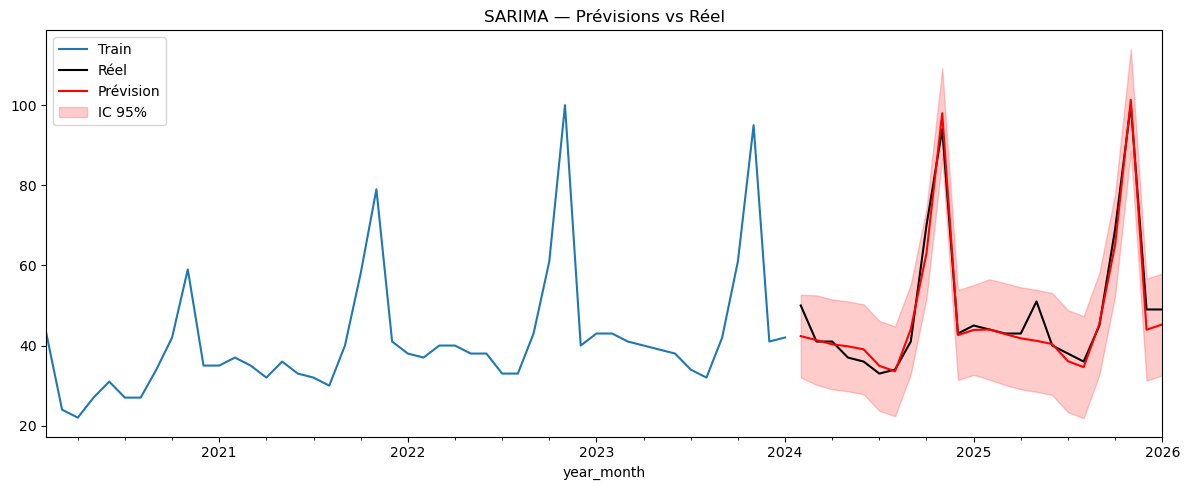

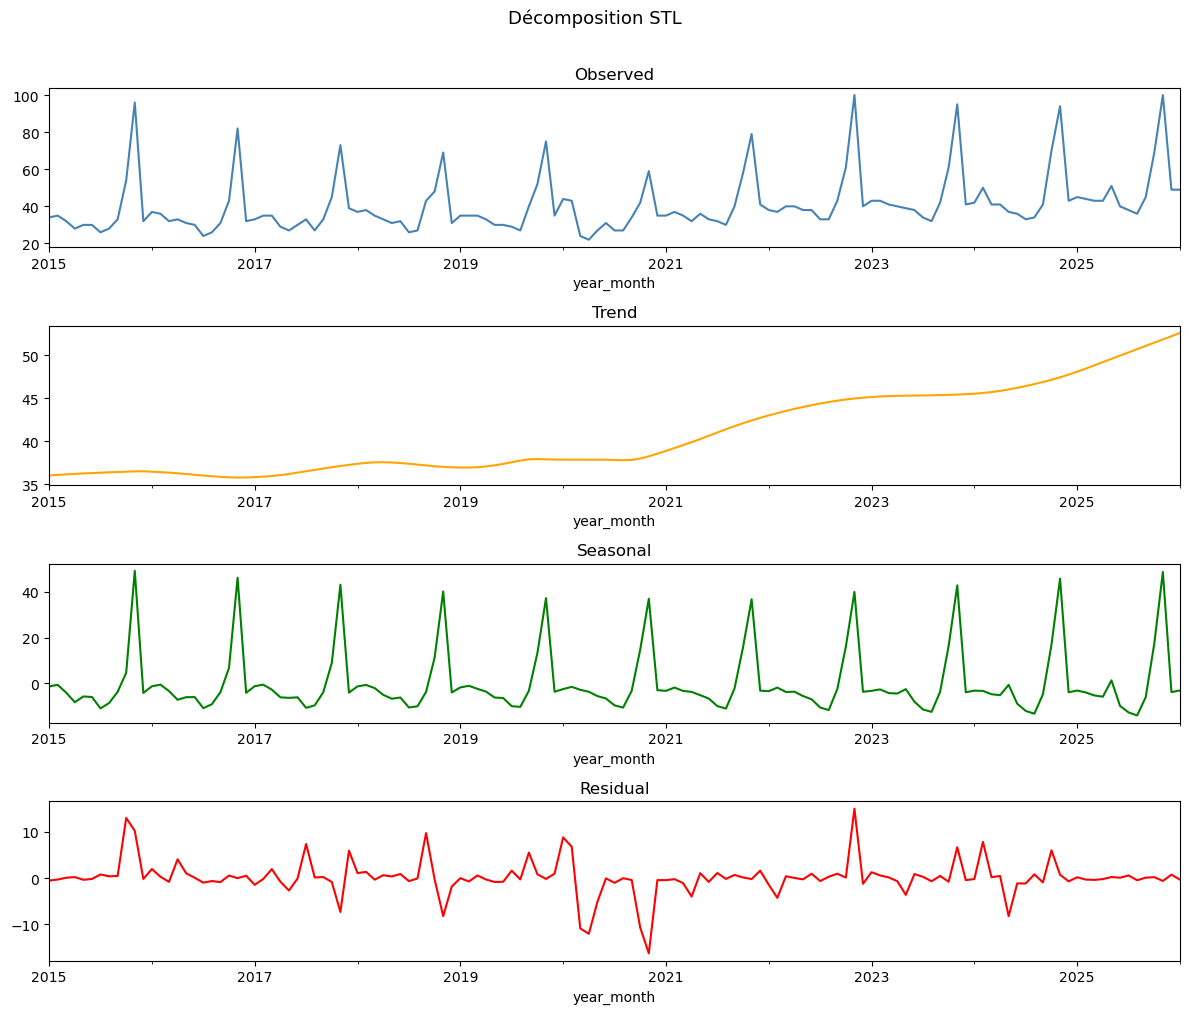

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=901.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=817.175, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1125.756, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=889.928, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=714.444, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=716.902, Time=0.17 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=714.164, Time=1.03 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=732.820, Time=1.18 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                           Movember   No. Observations:                  109
Model:             SARIMAX(0, 0, 2)x(1, 0, 2, 12)   Log Likelihood                -254.198
Date:                            Mon, 16 Mar 2026   AIC                            520.397
Time:                                    14:51:03   BIC                            534.837
Sample:                                01-01-2015   HQIC                           526.194
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          4.8597      6.357      0.764      0.445      -7.600      17.319
ma.L2         11.6993     15.483   

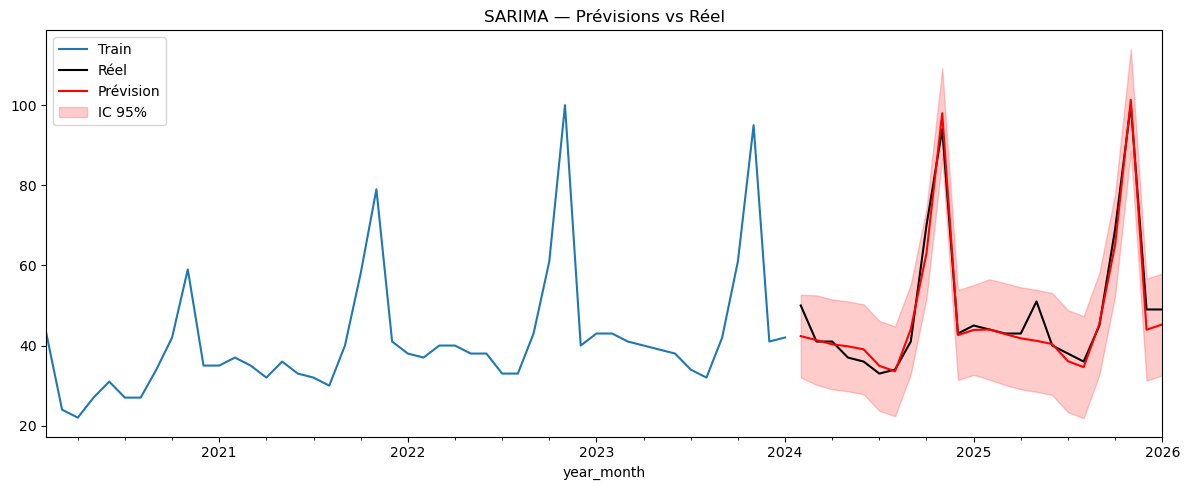

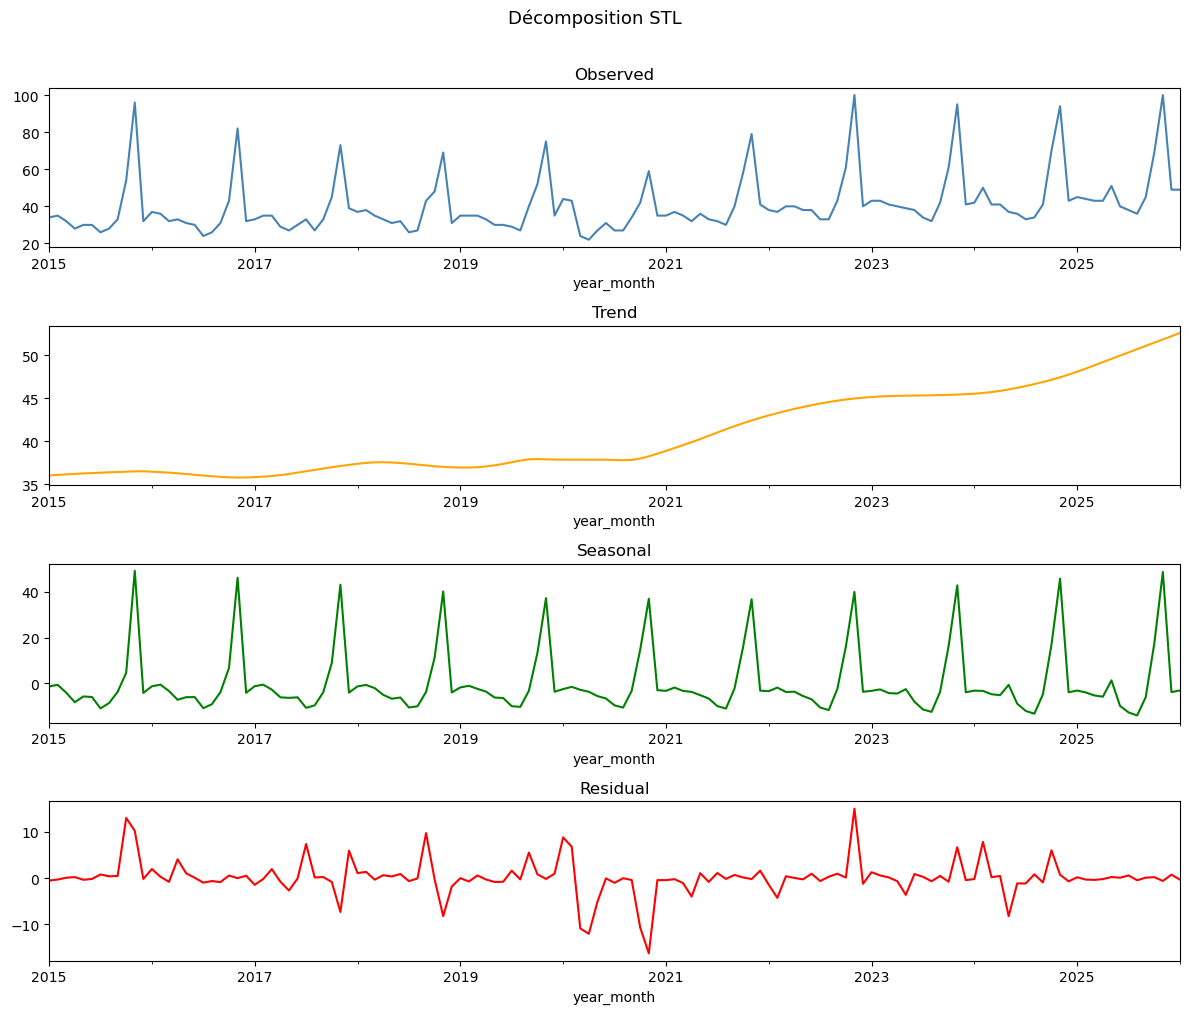

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1381.267, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1381.643, Time=0.31 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1378.752, Time=0.51 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1380.802, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=1383.229, Time=0.12 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=1380.755, Time=0.40 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=inf, Time=1.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=1381.647, Time=0.24 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=1382.703, Time=1.19 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1376.856, Time=0.31 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=1378.858, Time=0.29 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=1378.862, Time=0.47 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=901.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=817.175, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1125.756, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=889.928, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=714.444, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=716.902, Time=0.17 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=714.164, Time=1.03 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=732.820, Time=1.18 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                           Movember   No. Observations:                  109
Model:             SARIMAX(0, 0, 2)x(1, 0, 2, 12)   Log Likelihood                -254.198
Date:                            Mon, 16 Mar 2026   AIC                            520.397
Time:                                    14:51:03   BIC                            534.837
Sample:                                01-01-2015   HQIC                           526.194
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          4.8597      6.357      0.764      0.445      -7.600      17.319
ma.L2         11.6993     15.483   

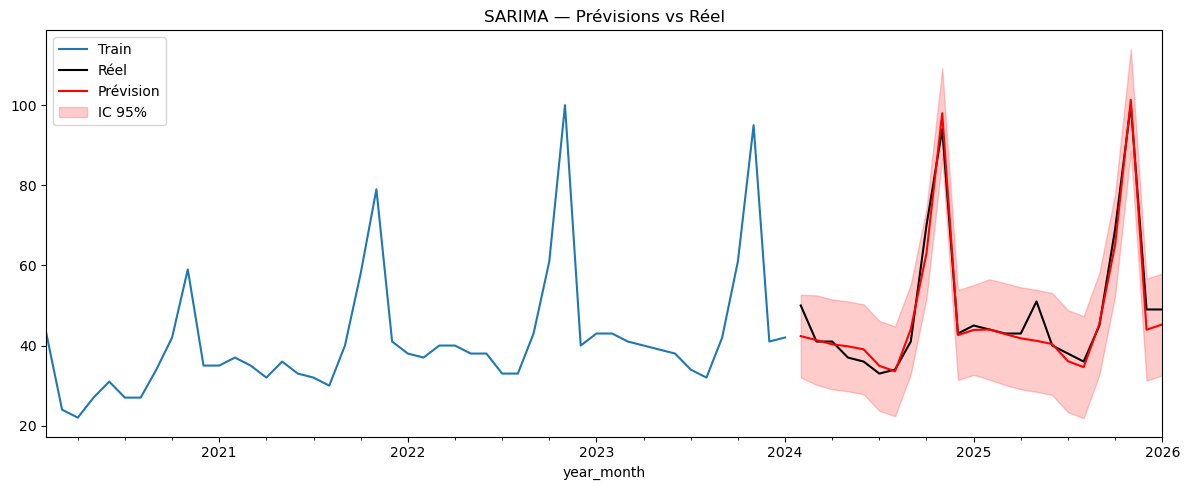

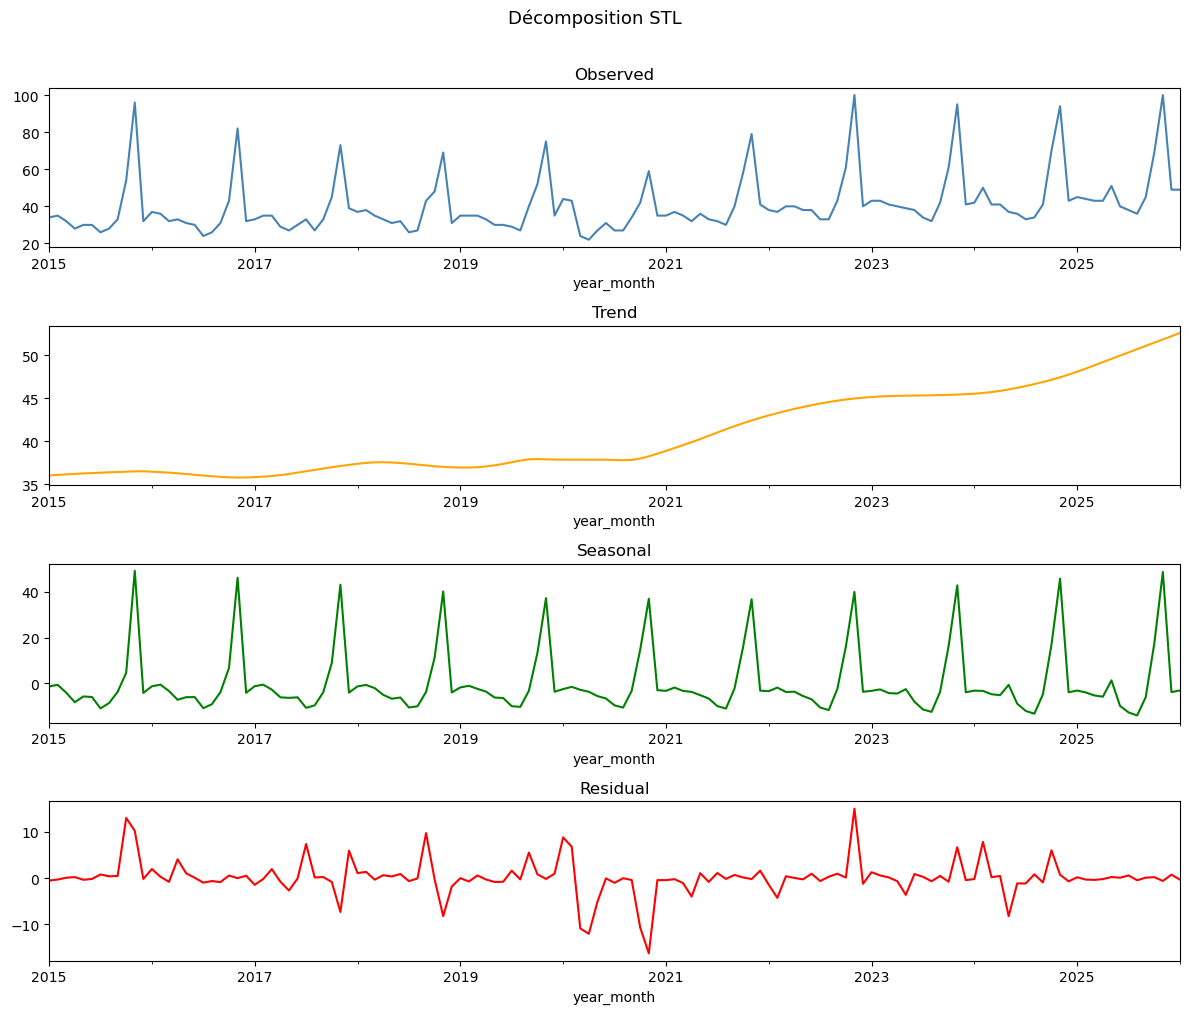

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1381.267, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1381.643, Time=0.31 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1378.752, Time=0.51 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1380.802, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=1383.229, Time=0.12 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=1380.755, Time=0.40 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=inf, Time=1.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=1381.647, Time=0.24 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=1382.703, Time=1.19 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1376.856, Time=0.31 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=1378.858, Time=0.29 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=1378.862, Time=0.47 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=901.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=817.175, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1125.756, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=889.928, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=714.444, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=716.902, Time=0.17 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=714.164, Time=1.03 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=732.820, Time=1.18 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                           Movember   No. Observations:                  109
Model:             SARIMAX(0, 0, 2)x(1, 0, 2, 12)   Log Likelihood                -254.198
Date:                            Mon, 16 Mar 2026   AIC                            520.397
Time:                                    14:51:03   BIC                            534.837
Sample:                                01-01-2015   HQIC                           526.194
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          4.8597      6.357      0.764      0.445      -7.600      17.319
ma.L2         11.6993     15.483   

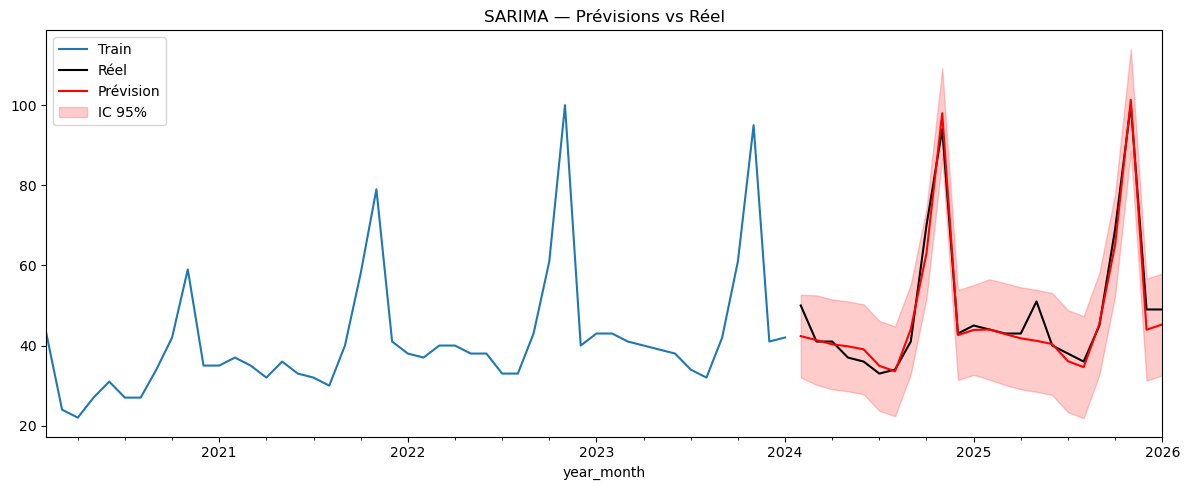

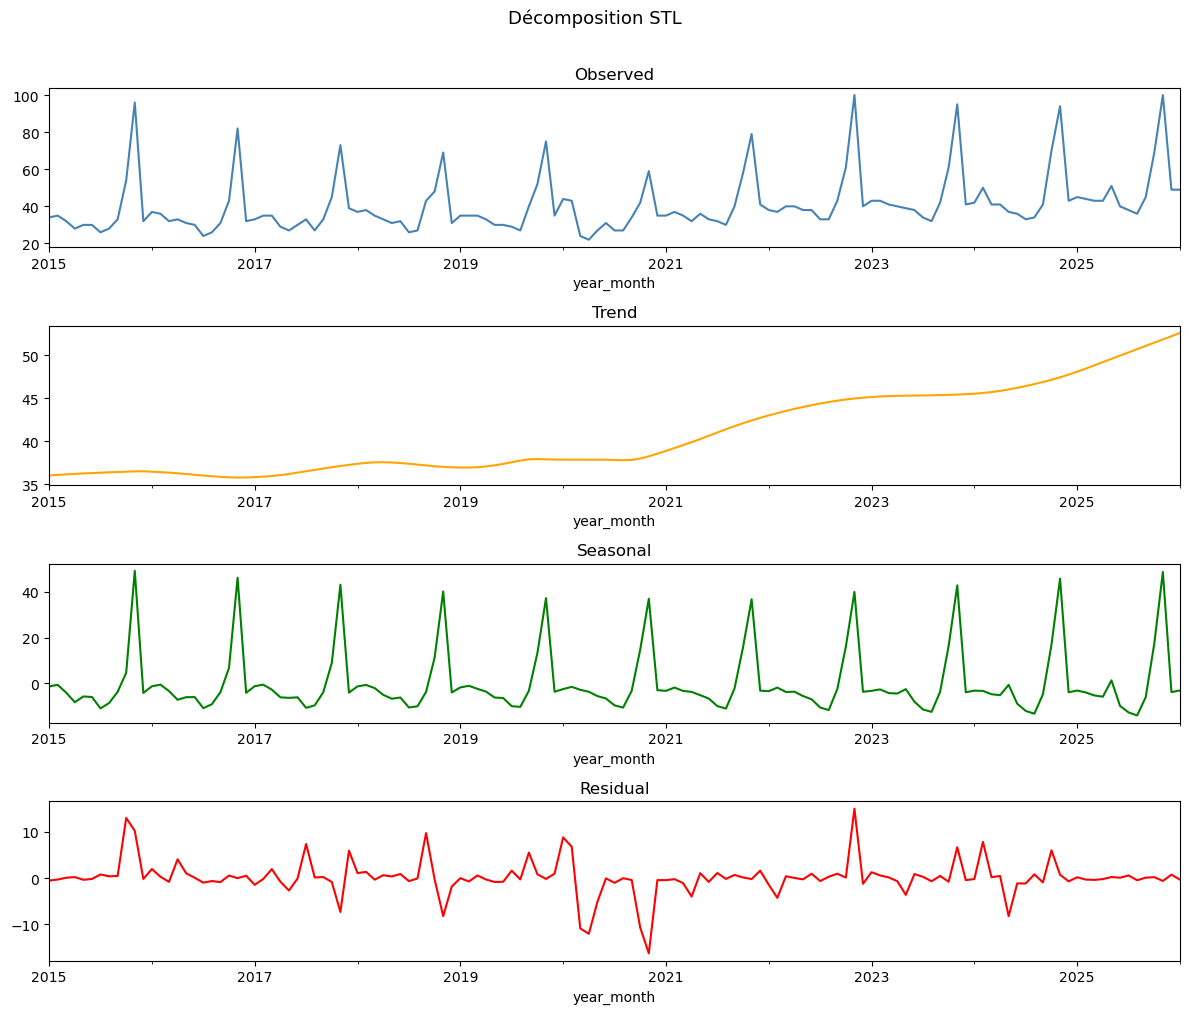

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1381.267, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1381.643, Time=0.31 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1378.752, Time=0.51 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1380.802, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=1383.229, Time=0.12 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=1380.755, Time=0.40 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=inf, Time=1.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=1381.647, Time=0.24 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=1382.703, Time=1.19 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1376.856, Time=0.31 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=1378.858, Time=0.29 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=1378.862, Time=0.47 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:                   Movember   No. Observations:                  108
Model:             SARIMAX(0, 1, [1], 12)   Log Likelihood                -597.763
Date:                    Mon, 16 Mar 2026   AIC                           1199.526
Time:                            14:51:13   BIC                           1204.363
Sample:                        01-01-2015   HQIC                          1201.469
                             - 12-01-2023                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12      -0.4508      0.171     -2.632      0.008      -0.786      -0.115
sigma2      1.048e+05   3821.855     27.427      0.000    9.73e+04    1.12e+05
Ljung-Box (L1) (Q): 

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=901.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=817.175, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1125.756, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=889.928, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=714.444, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=716.902, Time=0.17 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=714.164, Time=1.03 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=732.820, Time=1.18 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                           Movember   No. Observations:                  109
Model:             SARIMAX(0, 0, 2)x(1, 0, 2, 12)   Log Likelihood                -254.198
Date:                            Mon, 16 Mar 2026   AIC                            520.397
Time:                                    14:51:03   BIC                            534.837
Sample:                                01-01-2015   HQIC                           526.194
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          4.8597      6.357      0.764      0.445      -7.600      17.319
ma.L2         11.6993     15.483   

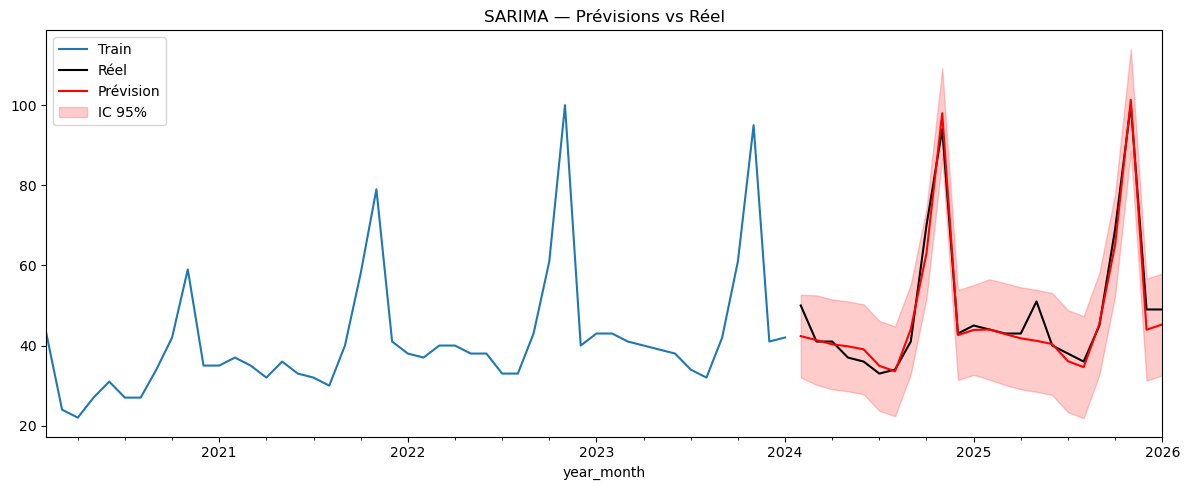

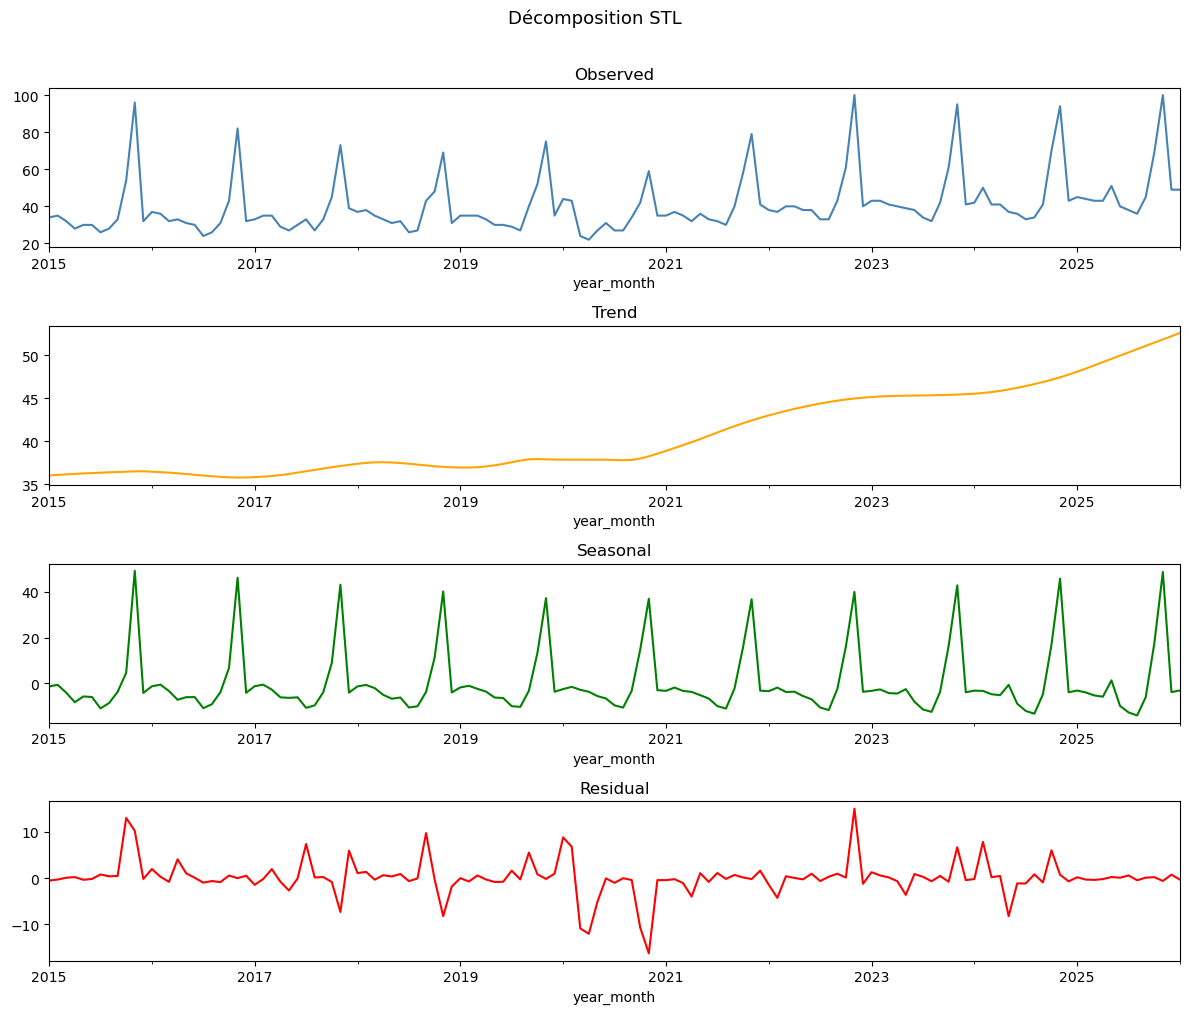

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1381.267, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1381.643, Time=0.31 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1378.752, Time=0.51 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1380.802, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=1383.229, Time=0.12 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=1380.755, Time=0.40 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=inf, Time=1.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=1381.647, Time=0.24 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=1382.703, Time=1.19 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1376.856, Time=0.31 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=1378.858, Time=0.29 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=1378.862, Time=0.47 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:                   Movember   No. Observations:                  108
Model:             SARIMAX(0, 1, [1], 12)   Log Likelihood                -597.763
Date:                    Mon, 16 Mar 2026   AIC                           1199.526
Time:                            14:51:13   BIC                           1204.363
Sample:                        01-01-2015   HQIC                          1201.469
                             - 12-01-2023                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12      -0.4508      0.171     -2.632      0.008      -0.786      -0.115
sigma2      1.048e+05   3821.855     27.427      0.000    9.73e+04    1.12e+05
Ljung-Box (L1) (Q): 

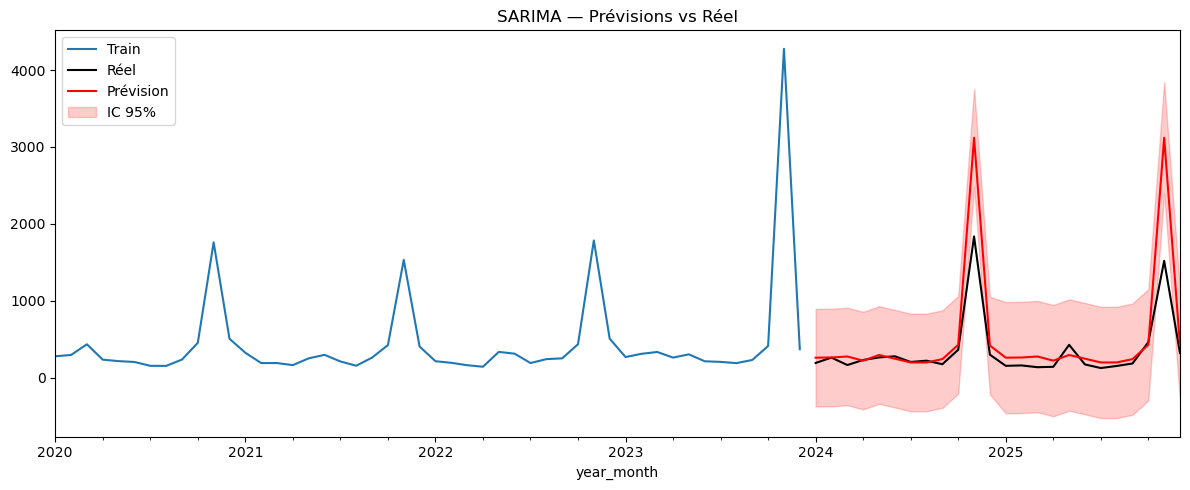

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.60 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=901.019, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.24 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=817.175, Time=0.10 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1125.756, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=889.928, Time=0.04 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=714.444, Time=0.39 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=716.902, Time=0.17 sec
 ARIMA(0,0,1)(2,0,1)[12] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=714.164, Time=1.03 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.70 sec
 ARIMA(0,0,1)(2,0,2)[12] intercept   : AIC=inf, Time=1.80 sec
 ARIMA(0,0,0)(1,0,2)[12] intercept   : AIC=732.820, Time=1.18 sec
 ARIMA(1,0,1)(1,0,2)[12] intercept   : AIC=inf, Time=1.92 sec
 ARI

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                           Movember   No. Observations:                  109
Model:             SARIMAX(0, 0, 2)x(1, 0, 2, 12)   Log Likelihood                -254.198
Date:                            Mon, 16 Mar 2026   AIC                            520.397
Time:                                    14:51:03   BIC                            534.837
Sample:                                01-01-2015   HQIC                           526.194
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          4.8597      6.357      0.764      0.445      -7.600      17.319
ma.L2         11.6993     15.483   

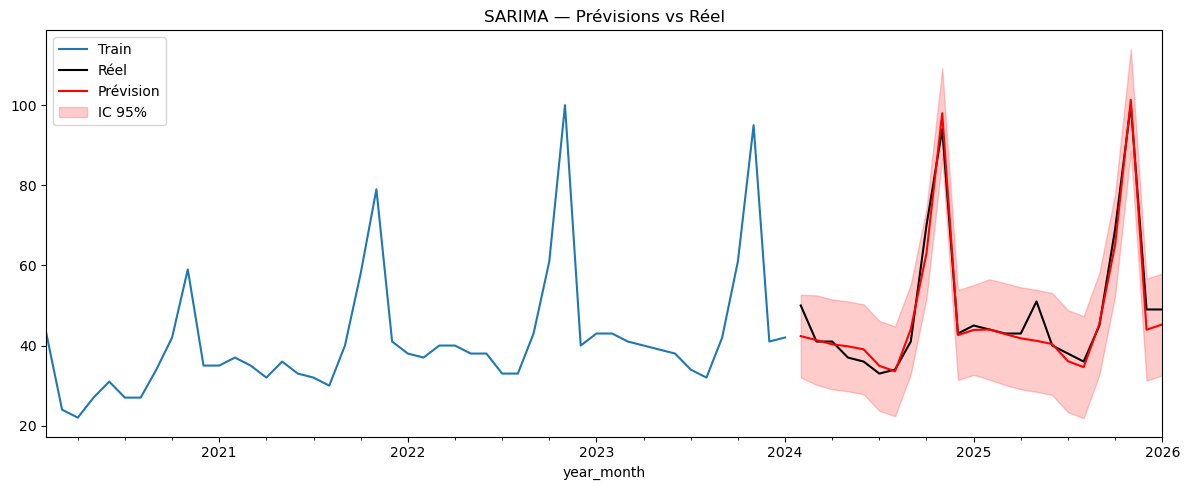

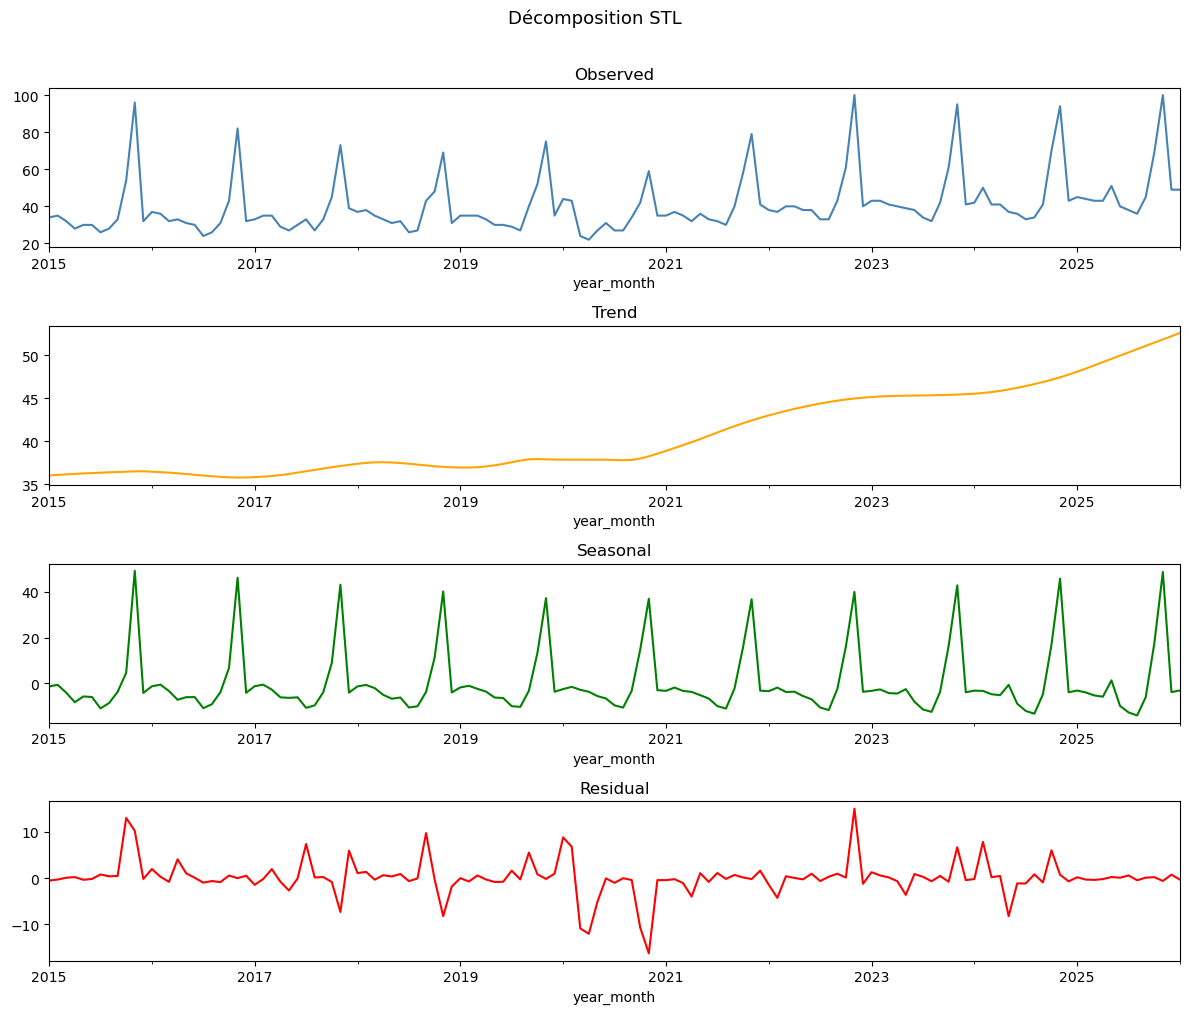

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.02 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1381.267, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1381.643, Time=0.31 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1378.752, Time=0.51 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1380.802, Time=0.04 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=1383.229, Time=0.12 sec
 ARIMA(0,0,1)(1,1,1)[12] intercept   : AIC=1380.755, Time=0.40 sec
 ARIMA(0,0,1)(0,1,2)[12] intercept   : AIC=inf, Time=1.53 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=1381.647, Time=0.24 sec
 ARIMA(0,0,1)(1,1,2)[12] intercept   : AIC=1382.703, Time=1.19 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1376.856, Time=0.31 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=1378.858, Time=0.29 sec
 ARIMA(0,0,0)(0,1,2)[12] intercept   : AIC=1378.862, Time=0.47 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                 SARIMAX Results                                  
Dep. Variable:                   Movember   No. Observations:                  108
Model:             SARIMAX(0, 1, [1], 12)   Log Likelihood                -597.763
Date:                    Mon, 16 Mar 2026   AIC                           1199.526
Time:                            14:51:13   BIC                           1204.363
Sample:                        01-01-2015   HQIC                          1201.469
                             - 12-01-2023                                         
Covariance Type:                      opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L12      -0.4508      0.171     -2.632      0.008      -0.786      -0.115
sigma2      1.048e+05   3821.855     27.427      0.000    9.73e+04    1.12e+05
Ljung-Box (L1) (Q): 

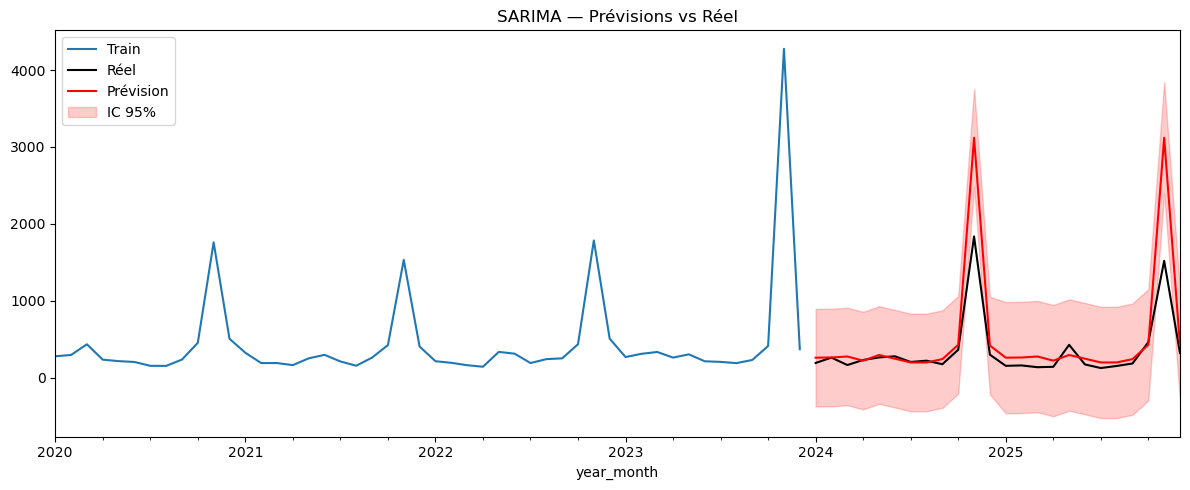

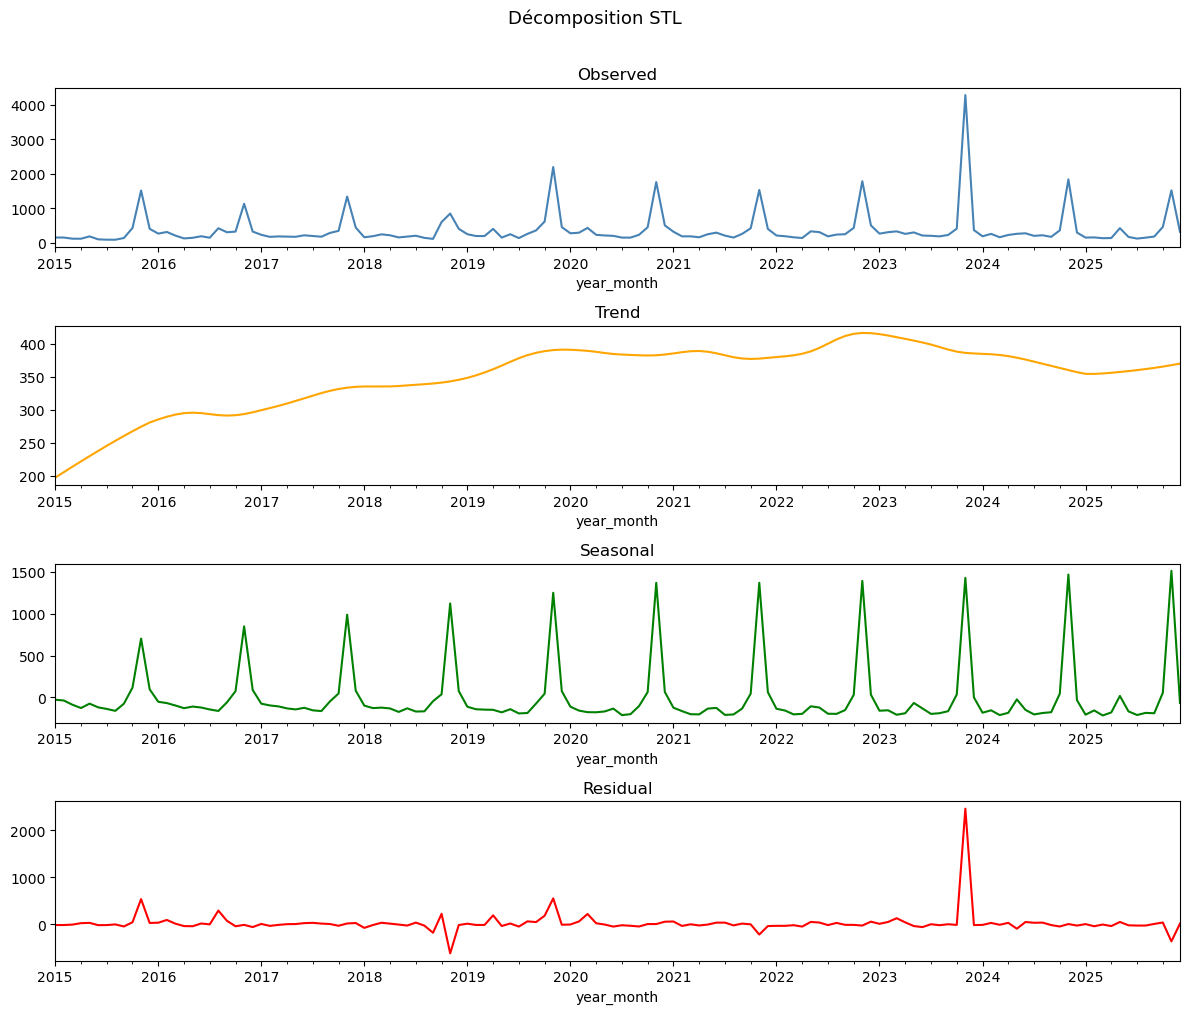

In [32]:
result_mo_gt, predictions_mo_gt, trend_mov_gt, seasonal_mov_gt, residual_mov_gt = run_sarima(
    series    = GT_Movember,   # ← votre pd.Series ici
    s         = 12,         # ← 52 pour hebdomadaire
    test_size = 24
)
result_mo_mc, predictions_mo_mc, trend_mov_mc, seasonal_mov_mc, residual_mov_mc = run_sarima(
    series    = MC_Movember,   # ← votre pd.Series ici
    s         = 12,         # ← 52 pour hebdomadaire
    test_size = 24
)

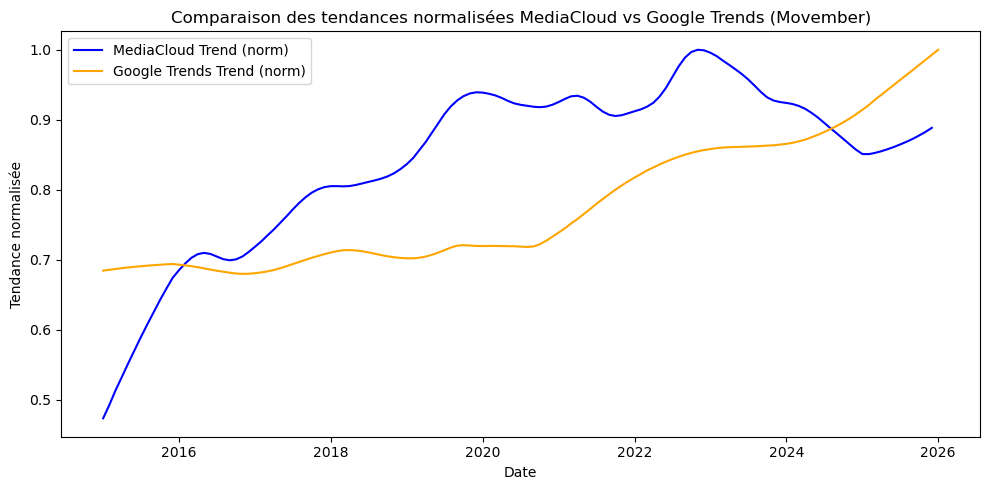

In [33]:
plt.figure(figsize=(10,5))

# Renormalisation
trend_mc_norm = trend_mov_mc / trend_mov_mc.max()
trend_gt_norm = trend_mov_gt / trend_mov_gt.max()

plt.plot(trend_mc_norm, label="MediaCloud Trend (norm)", color="blue")
plt.plot(trend_gt_norm, label="Google Trends Trend (norm)", color="orange")
plt.title("Comparaison des tendances normalisées MediaCloud vs Google Trends (Movember)")
plt.xlabel("Date")
plt.ylabel("Tendance normalisée")
plt.legend()
plt.tight_layout()
plt.show()

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=612.213, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=648.426, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=609.339, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=621.815, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=654.290, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=616.089, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=608.820, Time=0.56 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=610.608, Time=0.97 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=609.248, Time=0.29 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=640.032, Time=0.42 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=609.876, Time=0.72 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=609.430, Time=0.71 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=619.001, Time=0.52 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=611.

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=612.213, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=648.426, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=609.339, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=621.815, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=654.290, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=616.089, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=608.820, Time=0.56 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=610.608, Time=0.97 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=609.248, Time=0.29 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=640.032, Time=0.42 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=609.876, Time=0.72 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=609.430, Time=0.71 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=619.001, Time=0.52 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=611.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=612.213, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=648.426, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=609.339, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=621.815, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=654.290, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=616.089, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=608.820, Time=0.56 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=610.608, Time=0.97 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=609.248, Time=0.29 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=640.032, Time=0.42 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=609.876, Time=0.72 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=609.430, Time=0.71 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=619.001, Time=0.52 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=611.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -224.946
Date:                            Mon, 16 Mar 2026   AIC                            457.893
Time:                                    14:51:22   BIC                            466.999
Sample:                                01-01-2015   HQIC                           461.518
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6212      0.053     11.754      0.000       0.518       0.725
ar.S.L12      -0.2751      0.181   

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=612.213, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=648.426, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=609.339, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=621.815, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=654.290, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=616.089, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=608.820, Time=0.56 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=610.608, Time=0.97 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=609.248, Time=0.29 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=640.032, Time=0.42 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=609.876, Time=0.72 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=609.430, Time=0.71 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=619.001, Time=0.52 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=611.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -224.946
Date:                            Mon, 16 Mar 2026   AIC                            457.893
Time:                                    14:51:22   BIC                            466.999
Sample:                                01-01-2015   HQIC                           461.518
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6212      0.053     11.754      0.000       0.518       0.725
ar.S.L12      -0.2751      0.181   

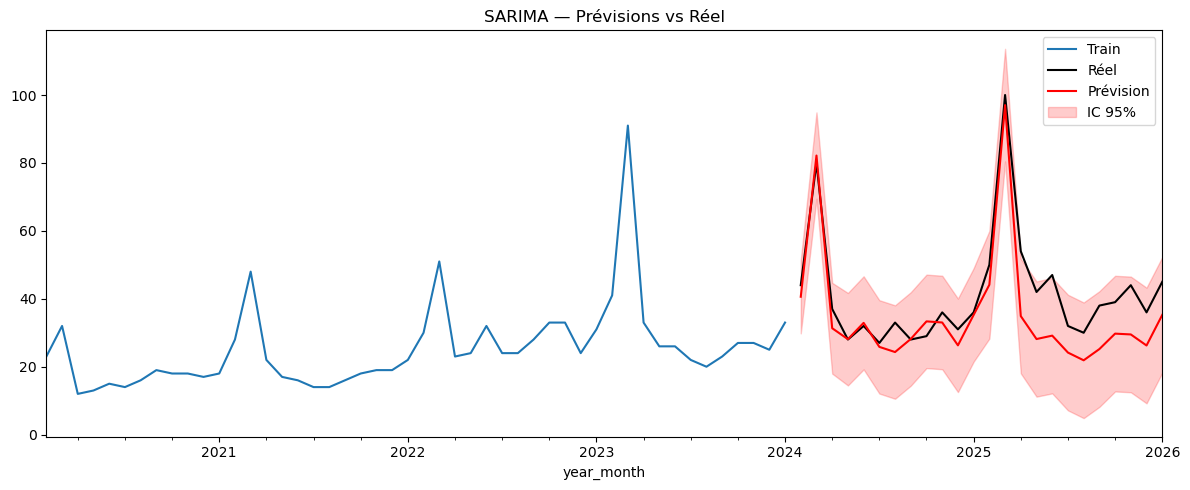

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=612.213, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=648.426, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=609.339, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=621.815, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=654.290, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=616.089, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=608.820, Time=0.56 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=610.608, Time=0.97 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=609.248, Time=0.29 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=640.032, Time=0.42 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=609.876, Time=0.72 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=609.430, Time=0.71 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=619.001, Time=0.52 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=611.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -224.946
Date:                            Mon, 16 Mar 2026   AIC                            457.893
Time:                                    14:51:22   BIC                            466.999
Sample:                                01-01-2015   HQIC                           461.518
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6212      0.053     11.754      0.000       0.518       0.725
ar.S.L12      -0.2751      0.181   

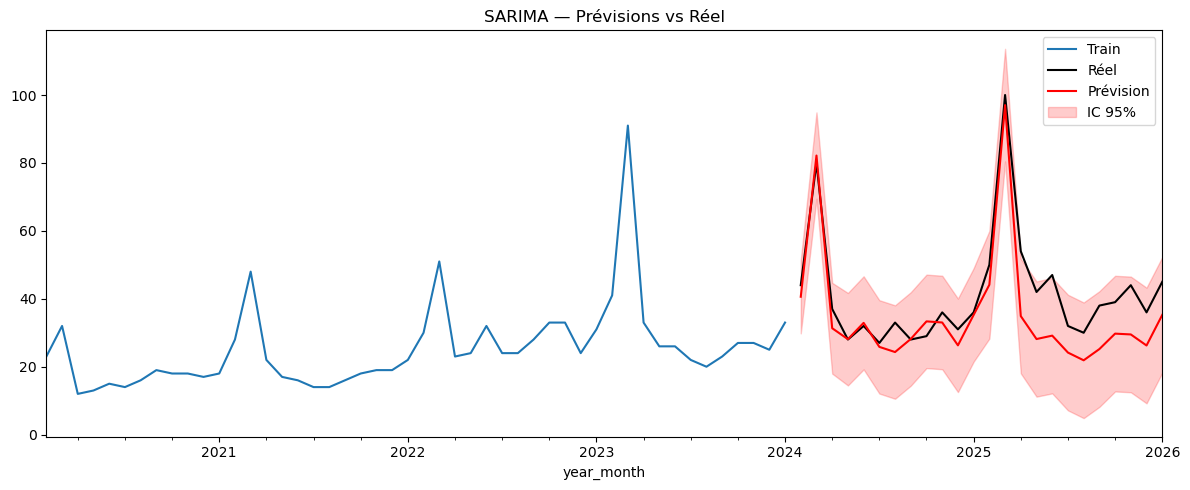

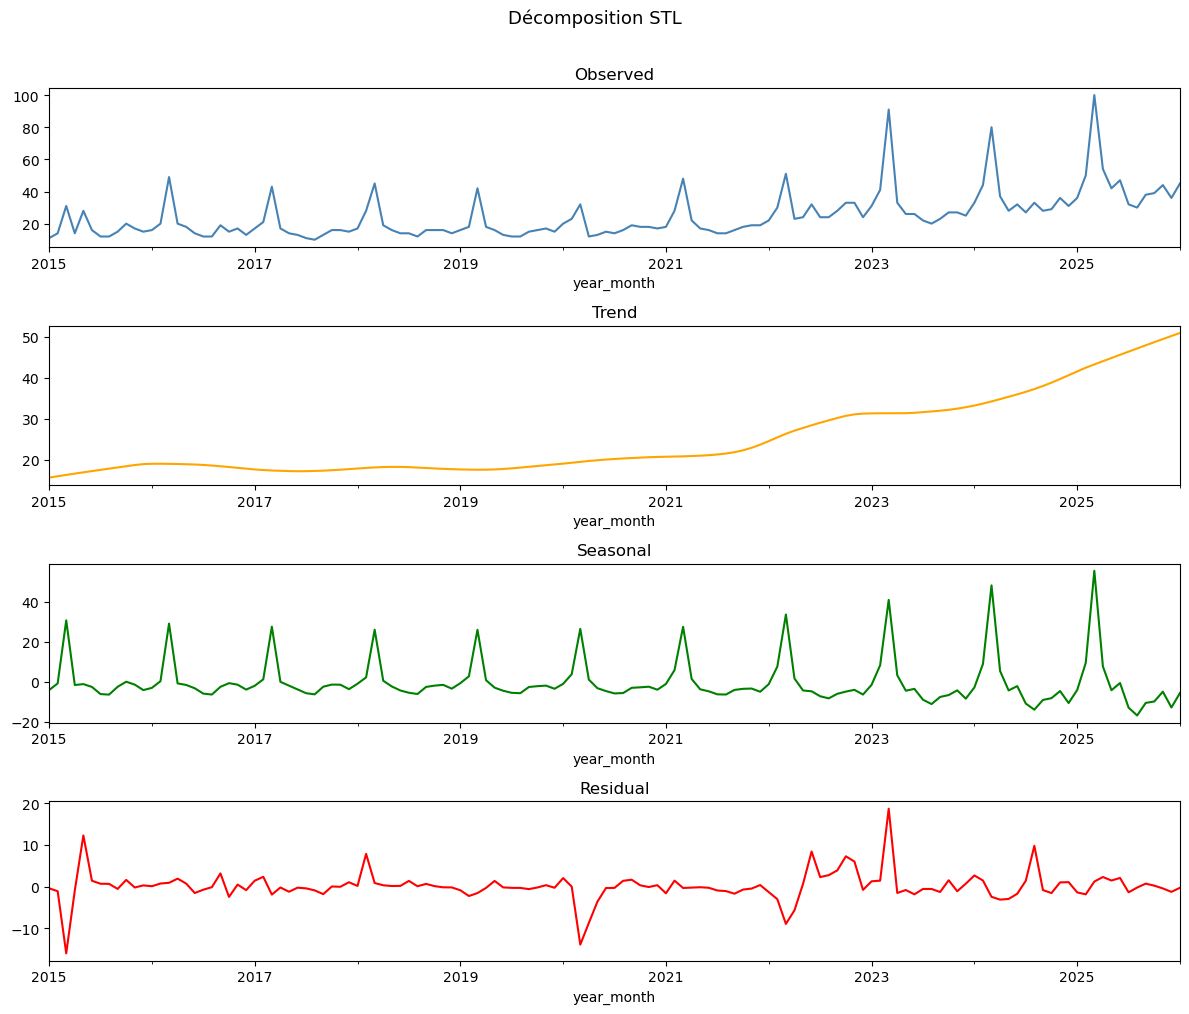

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=612.213, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=648.426, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=609.339, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=621.815, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=654.290, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=616.089, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=608.820, Time=0.56 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=610.608, Time=0.97 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=609.248, Time=0.29 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=640.032, Time=0.42 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=609.876, Time=0.72 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=609.430, Time=0.71 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=619.001, Time=0.52 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=611.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -224.946
Date:                            Mon, 16 Mar 2026   AIC                            457.893
Time:                                    14:51:22   BIC                            466.999
Sample:                                01-01-2015   HQIC                           461.518
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6212      0.053     11.754      0.000       0.518       0.725
ar.S.L12      -0.2751      0.181   

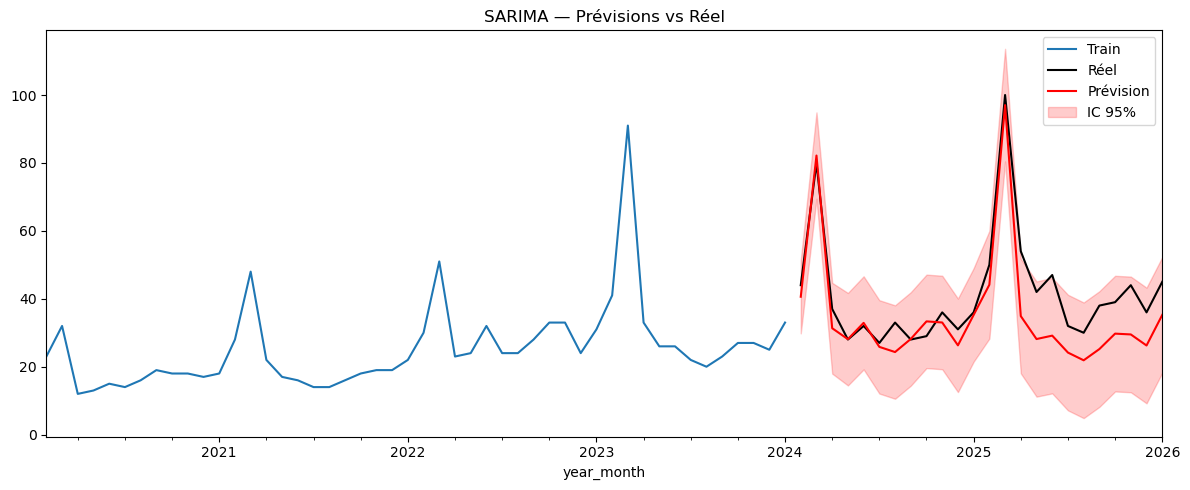

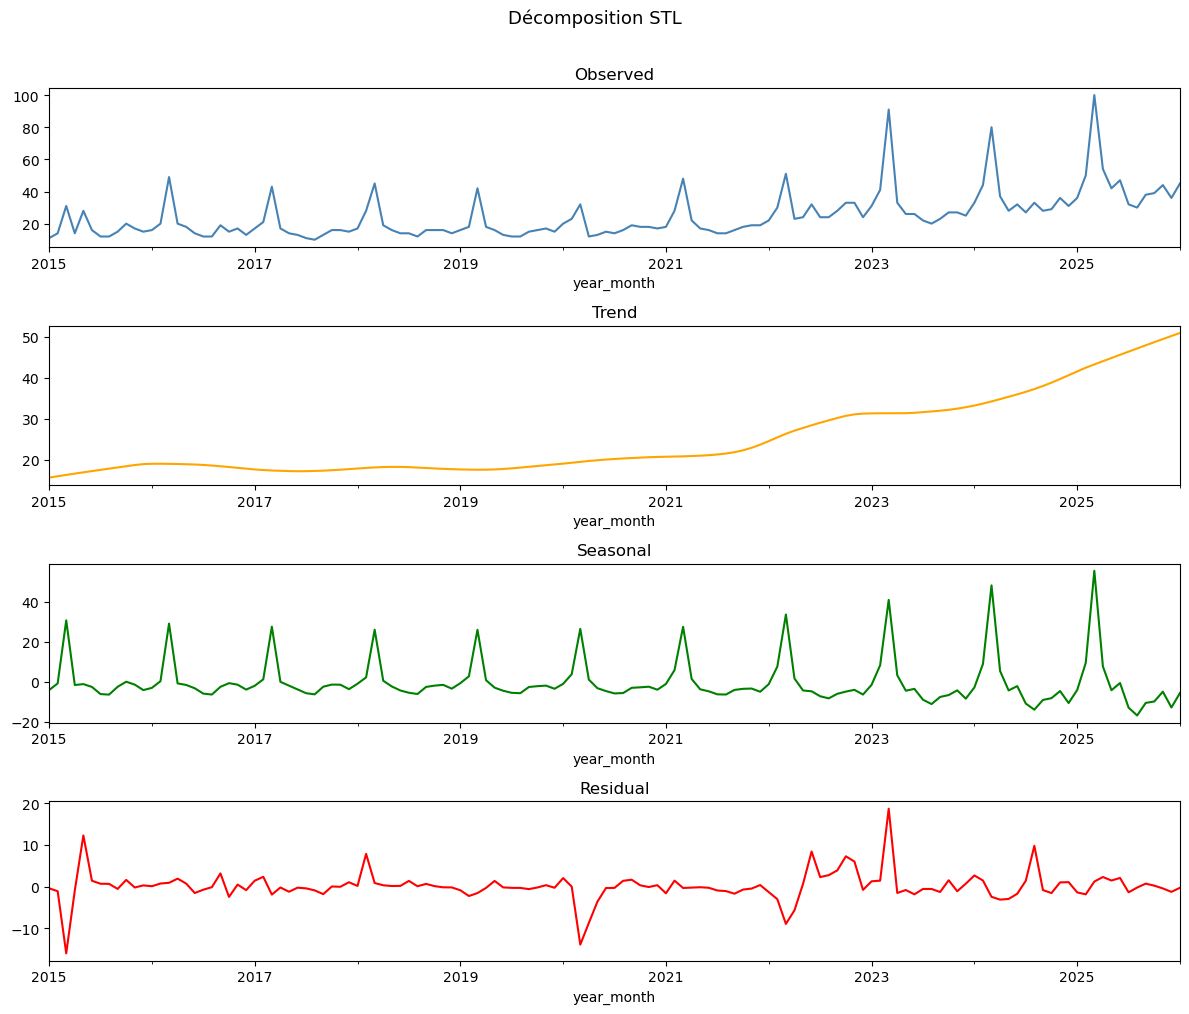

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1262.291, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1238.306, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1237.322, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1260.296, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1240.443, Time=0.05 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1231.425, Time=0.52 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=1250.430, Time=0.46 sec
 ARIMA(1,1,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(0,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=1238.824, Time=0.49 sec
 ARIMA(1,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=1.04 s

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=612.213, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=648.426, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=609.339, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=621.815, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=654.290, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=616.089, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=608.820, Time=0.56 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=610.608, Time=0.97 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=609.248, Time=0.29 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=640.032, Time=0.42 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=609.876, Time=0.72 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=609.430, Time=0.71 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=619.001, Time=0.52 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=611.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -224.946
Date:                            Mon, 16 Mar 2026   AIC                            457.893
Time:                                    14:51:22   BIC                            466.999
Sample:                                01-01-2015   HQIC                           461.518
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6212      0.053     11.754      0.000       0.518       0.725
ar.S.L12      -0.2751      0.181   

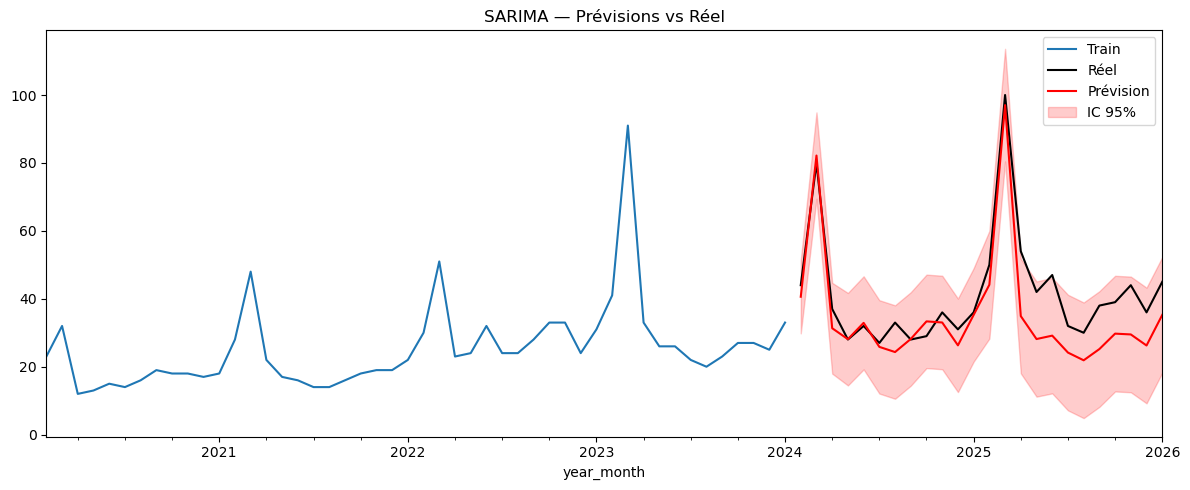

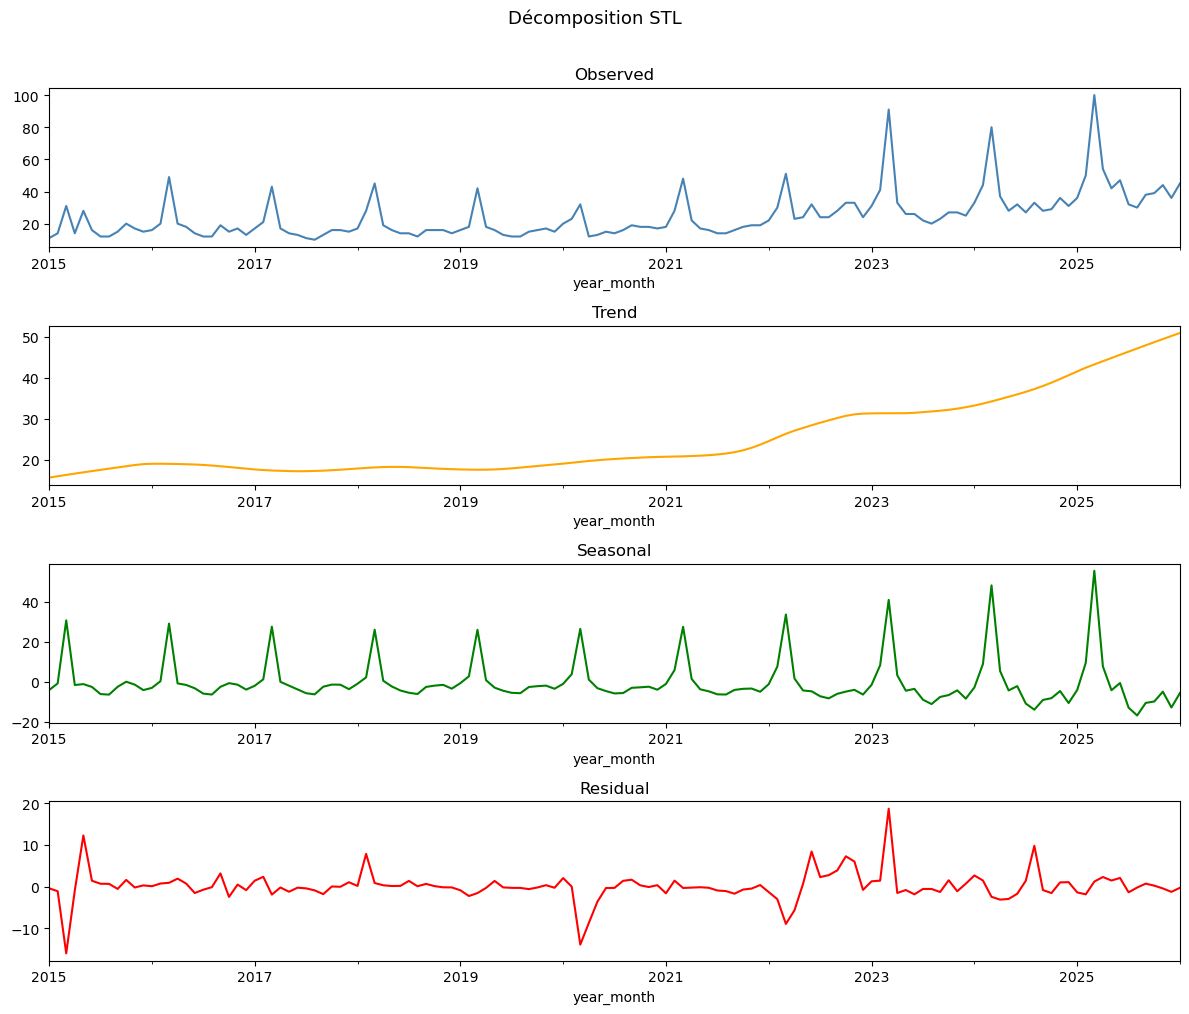

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1262.291, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1238.306, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1237.322, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1260.296, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1240.443, Time=0.05 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1231.425, Time=0.52 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=1250.430, Time=0.46 sec
 ARIMA(1,1,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(0,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=1238.824, Time=0.49 sec
 ARIMA(1,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=1.04 s

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=612.213, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=648.426, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=609.339, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=621.815, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=654.290, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=616.089, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=608.820, Time=0.56 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=610.608, Time=0.97 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=609.248, Time=0.29 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=640.032, Time=0.42 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=609.876, Time=0.72 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=609.430, Time=0.71 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=619.001, Time=0.52 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=611.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -224.946
Date:                            Mon, 16 Mar 2026   AIC                            457.893
Time:                                    14:51:22   BIC                            466.999
Sample:                                01-01-2015   HQIC                           461.518
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6212      0.053     11.754      0.000       0.518       0.725
ar.S.L12      -0.2751      0.181   

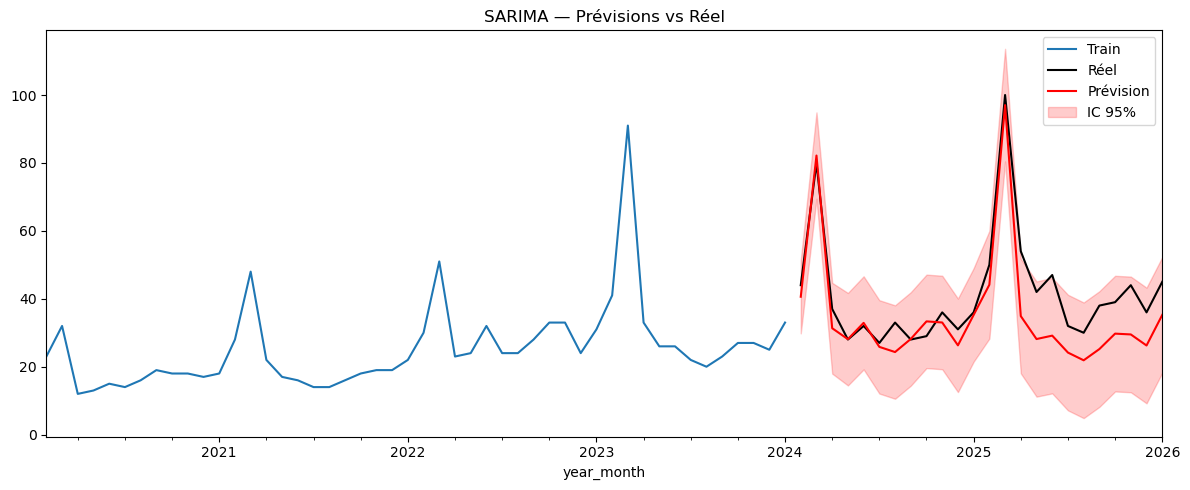

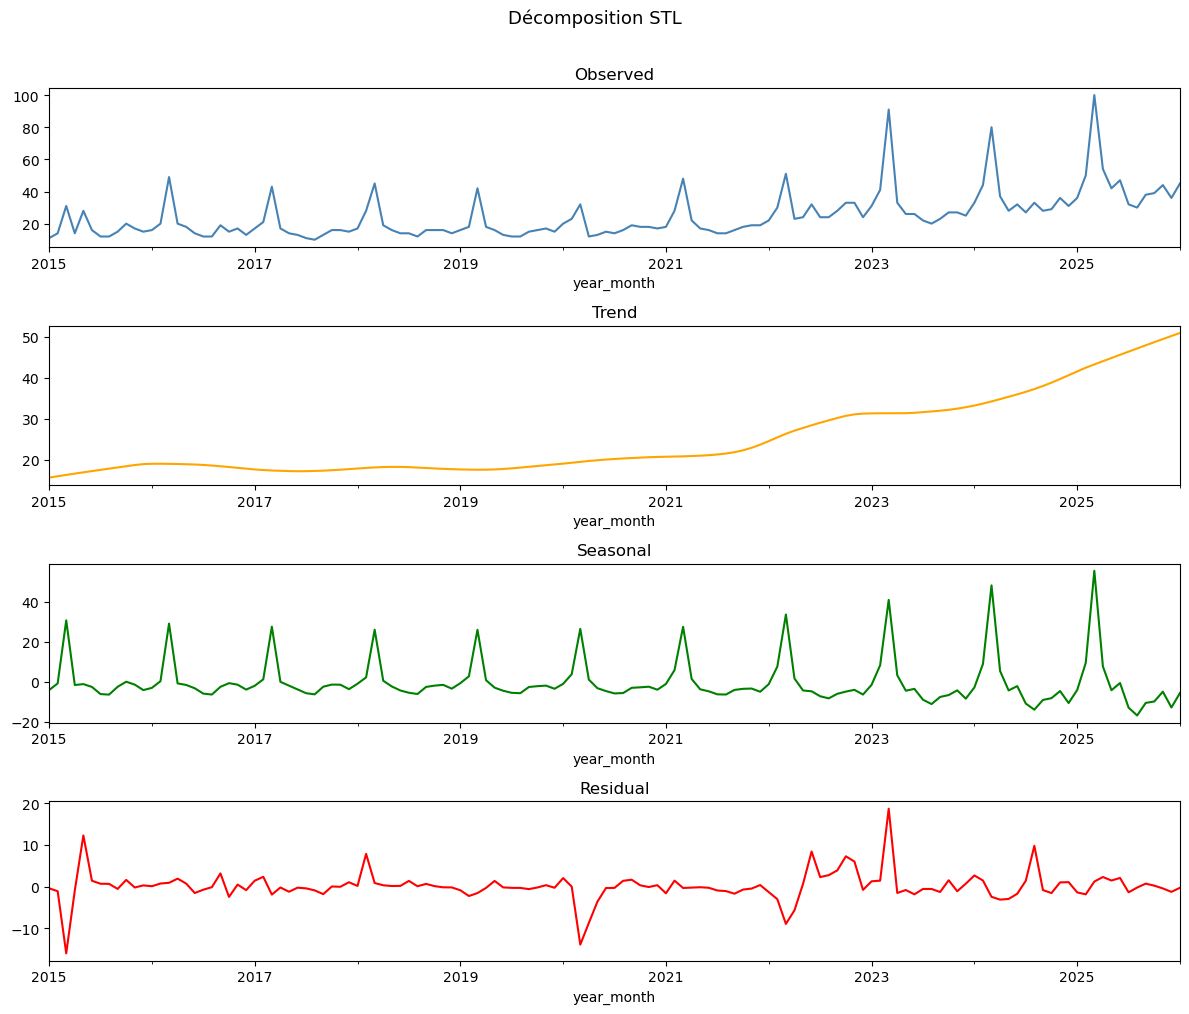

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1262.291, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1238.306, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1237.322, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1260.296, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1240.443, Time=0.05 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1231.425, Time=0.52 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=1250.430, Time=0.46 sec
 ARIMA(1,1,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(0,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=1238.824, Time=0.49 sec
 ARIMA(1,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=1.04 s

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  108
Model:             SARIMAX(2, 1, 2)x(1, 0, 2, 12)   Log Likelihood                -448.786
Date:                            Mon, 16 Mar 2026   AIC                            913.571
Time:                                    14:52:01   BIC                            932.627
Sample:                                01-01-2015   HQIC                           921.211
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1307      0.383     -0.342      0.733      -0.881       0.619
ar.L2          0.4807      0.133   

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=612.213, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=648.426, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=609.339, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=621.815, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=654.290, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=616.089, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=608.820, Time=0.56 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=610.608, Time=0.97 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=609.248, Time=0.29 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=640.032, Time=0.42 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=609.876, Time=0.72 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=609.430, Time=0.71 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=619.001, Time=0.52 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=611.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -224.946
Date:                            Mon, 16 Mar 2026   AIC                            457.893
Time:                                    14:51:22   BIC                            466.999
Sample:                                01-01-2015   HQIC                           461.518
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6212      0.053     11.754      0.000       0.518       0.725
ar.S.L12      -0.2751      0.181   

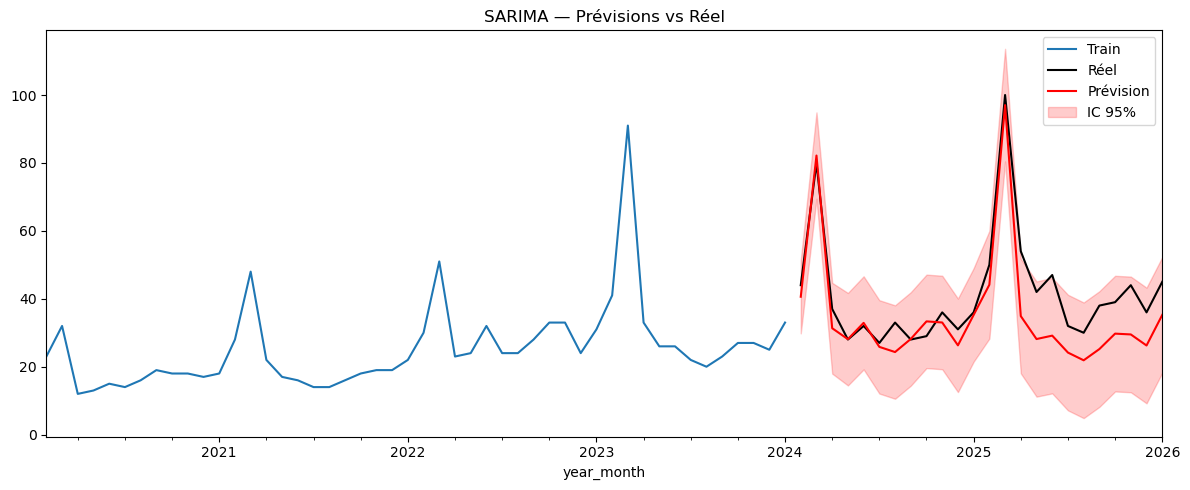

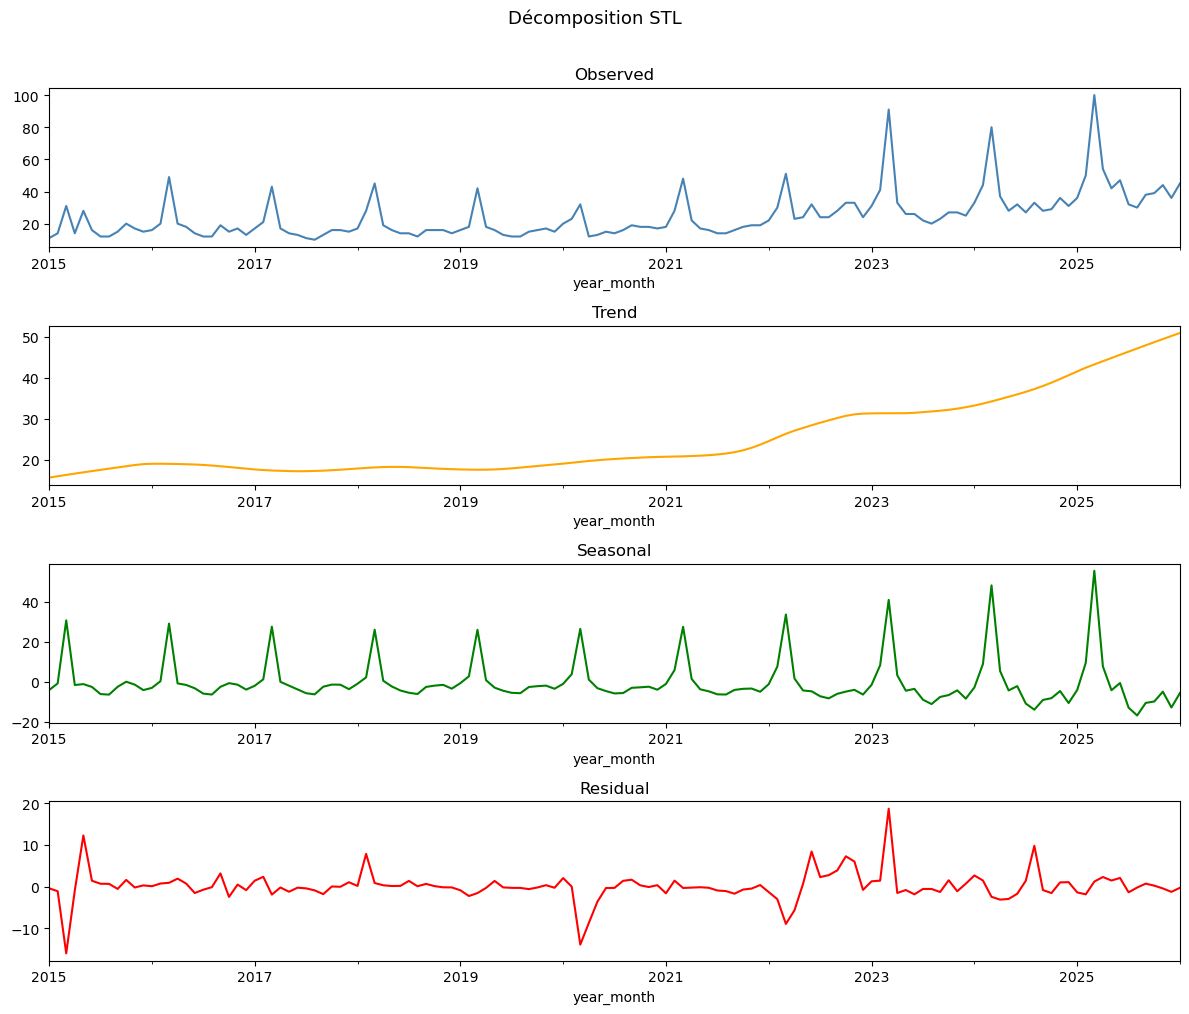

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1262.291, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1238.306, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1237.322, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1260.296, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1240.443, Time=0.05 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1231.425, Time=0.52 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=1250.430, Time=0.46 sec
 ARIMA(1,1,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(0,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=1238.824, Time=0.49 sec
 ARIMA(1,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=1.04 s

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  108
Model:             SARIMAX(2, 1, 2)x(1, 0, 2, 12)   Log Likelihood                -448.786
Date:                            Mon, 16 Mar 2026   AIC                            913.571
Time:                                    14:52:01   BIC                            932.627
Sample:                                01-01-2015   HQIC                           921.211
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1307      0.383     -0.342      0.733      -0.881       0.619
ar.L2          0.4807      0.133   

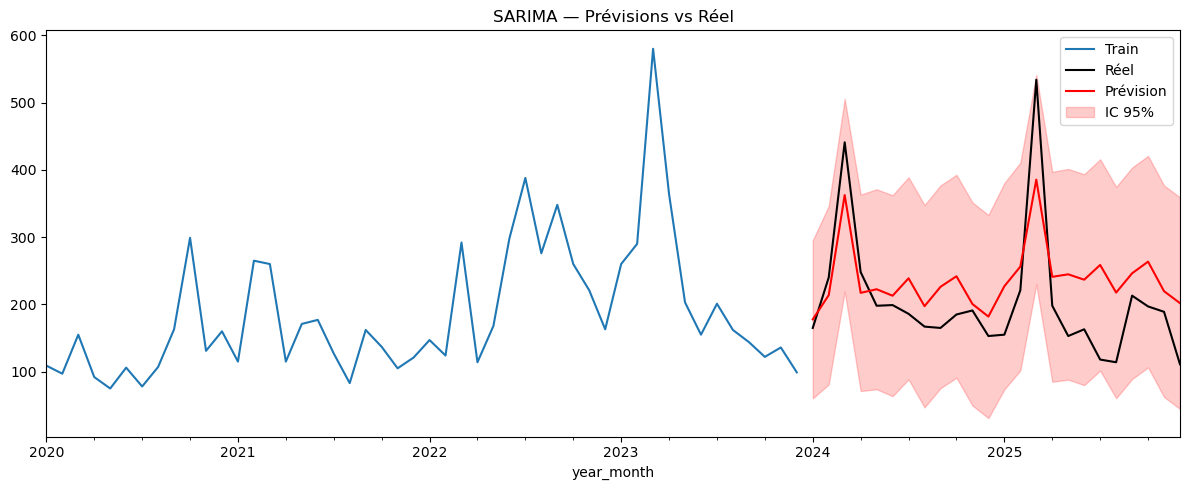

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=612.213, Time=0.71 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=648.426, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=609.339, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=621.815, Time=0.34 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=654.290, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=616.089, Time=0.07 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=608.820, Time=0.56 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=610.608, Time=0.97 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=609.248, Time=0.29 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=640.032, Time=0.42 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=609.876, Time=0.72 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=609.430, Time=0.71 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=619.001, Time=0.52 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=611.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  109
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -224.946
Date:                            Mon, 16 Mar 2026   AIC                            457.893
Time:                                    14:51:22   BIC                            466.999
Sample:                                01-01-2015   HQIC                           461.518
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6212      0.053     11.754      0.000       0.518       0.725
ar.S.L12      -0.2751      0.181   

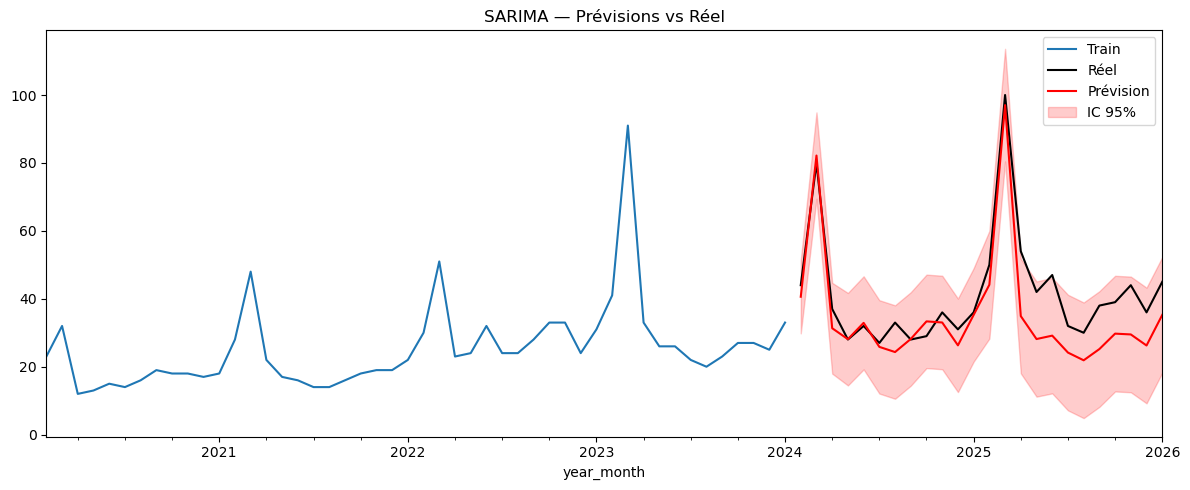

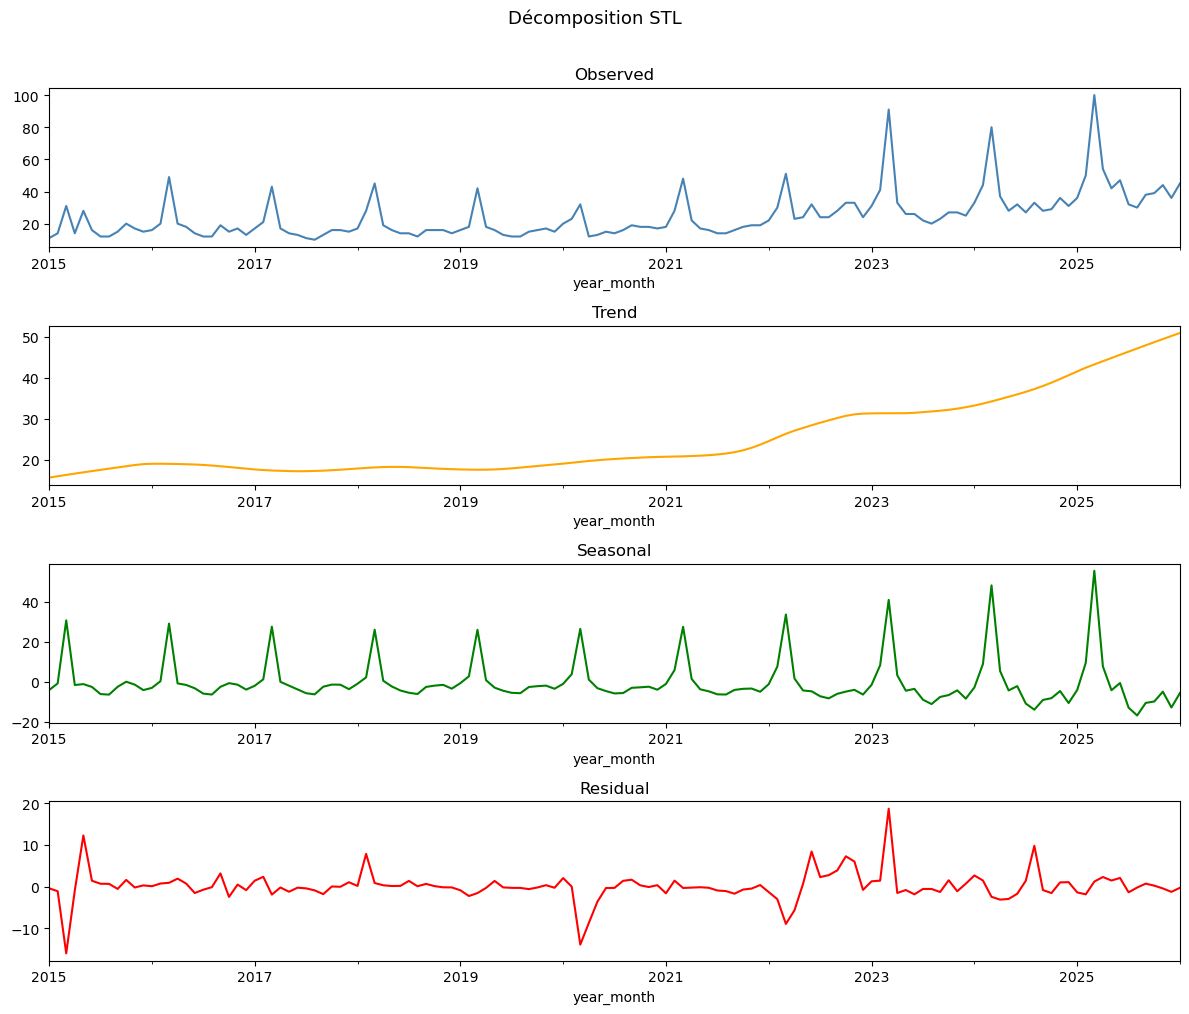

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1262.291, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1238.306, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1237.322, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1260.296, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1240.443, Time=0.05 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=1231.425, Time=0.52 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=inf, Time=0.73 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=1250.430, Time=0.46 sec
 ARIMA(1,1,1)(0,0,2)[12] intercept   : AIC=inf, Time=0.67 sec
 ARIMA(0,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=1238.824, Time=0.49 sec
 ARIMA(1,1,2)(0,0,2)[12] intercept   : AIC=inf, Time=1.04 s

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                          Mars Bleu   No. Observations:                  108
Model:             SARIMAX(2, 1, 2)x(1, 0, 2, 12)   Log Likelihood                -448.786
Date:                            Mon, 16 Mar 2026   AIC                            913.571
Time:                                    14:52:01   BIC                            932.627
Sample:                                01-01-2015   HQIC                           921.211
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1307      0.383     -0.342      0.733      -0.881       0.619
ar.L2          0.4807      0.133   

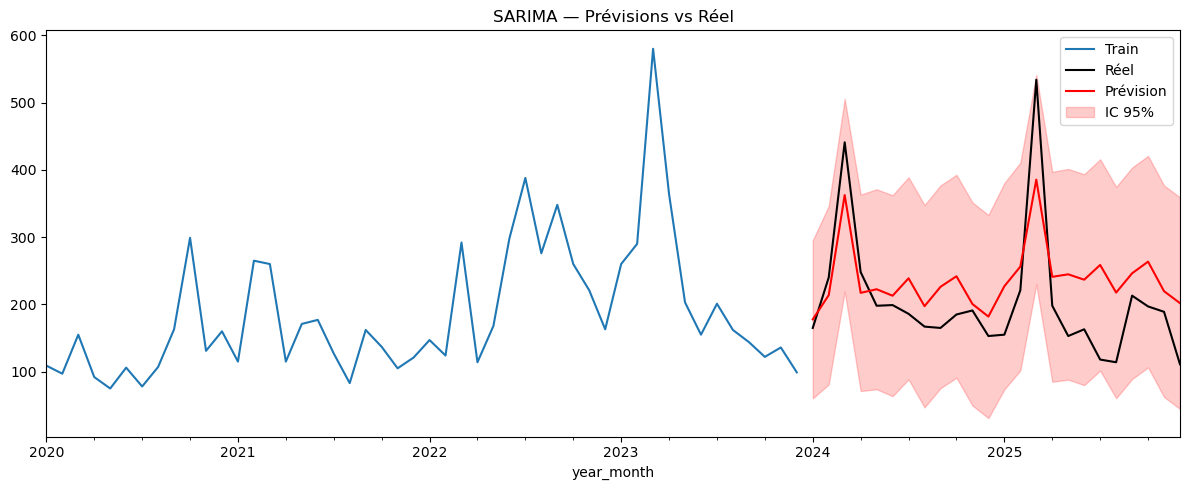

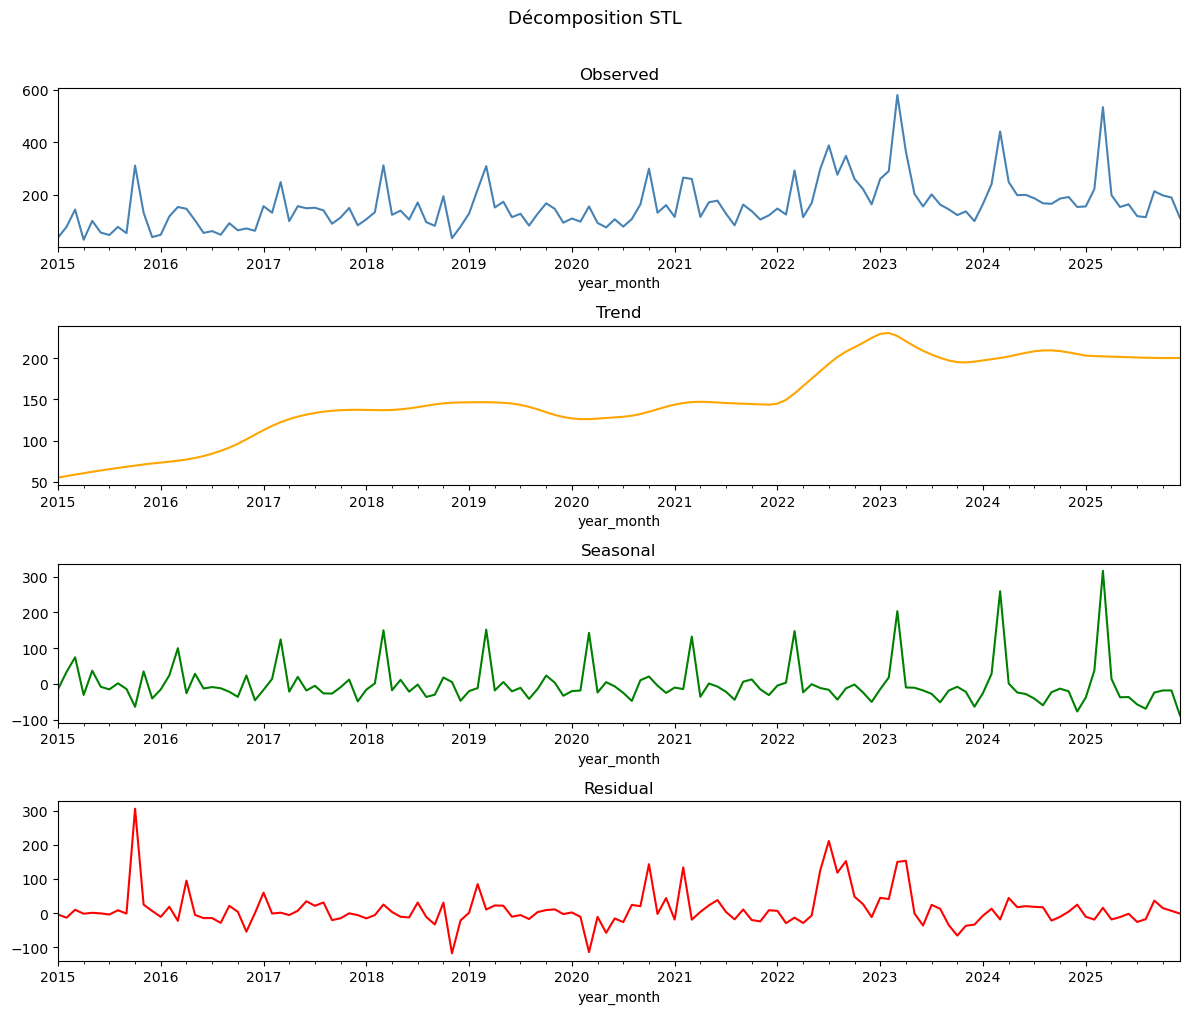

In [34]:
result_ma_gt, predictions_ma_gt, trend_ma_gt, seasonal_ma_gt, residual_ma_gt = run_sarima(
    series    = GT_Mars_bleu,   # ← votre pd.Series ici
    s         = 12,         # ← 52 pour hebdomadaire
    test_size = 24
)

result_ma_mc, predictions_ma_mc, trend_ma_mc, seasonal_ma_mc, residual_ma_mc = run_sarima(
    series    = MC_Mars_bleu,   # ← votre pd.Series ici
    s         = 12,         # ← 52 pour hebdomadaire
    test_size = 24
)

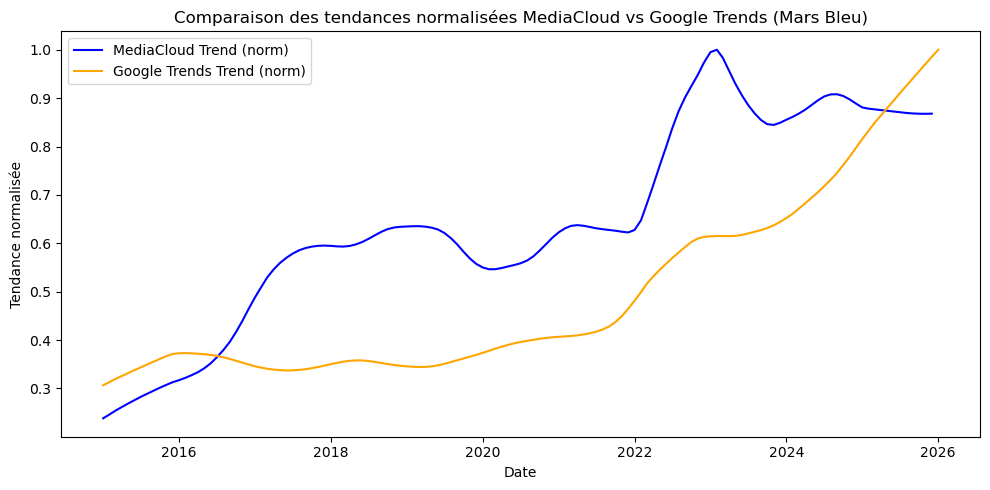

In [35]:
plt.figure(figsize=(10,5))
trend_mc_norm = trend_ma_mc / trend_ma_mc.max()
trend_gt_norm = trend_ma_gt / trend_ma_gt.max()
plt.plot(trend_mc_norm, label="MediaCloud Trend (norm)", color="blue")
plt.plot(trend_gt_norm, label="Google Trends Trend (norm)", color="orange")
plt.title("Comparaison des tendances normalisées MediaCloud vs Google Trends (Mars Bleu)")
plt.xlabel("Date")
plt.ylabel("Tendance normalisée")
plt.legend()
plt.tight_layout()
plt.show()

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=471.223, Time=0.66 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=506.880, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=503.538, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=489.549, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=483.020, Time=0.47 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=482.359, Time=0.50 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=459.429, Time=1.99 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=461.525, Time=1.51 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=458.461, Time=2.60 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=456.499, Time=1.32 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=467.290, Time=1.11 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=455.023, Time=0.96 sec
 ARIMA(1,1,2)(0,1,2)[12]             : AIC=465.953, Time=0.70 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=469.

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=471.223, Time=0.66 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=506.880, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=503.538, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=489.549, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=483.020, Time=0.47 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=482.359, Time=0.50 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=459.429, Time=1.99 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=461.525, Time=1.51 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=458.461, Time=2.60 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=456.499, Time=1.32 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=467.290, Time=1.11 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=455.023, Time=0.96 sec
 ARIMA(1,1,2)(0,1,2)[12]             : AIC=465.953, Time=0.70 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=469.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=471.223, Time=0.66 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=506.880, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=503.538, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=489.549, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=483.020, Time=0.47 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=482.359, Time=0.50 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=459.429, Time=1.99 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=461.525, Time=1.51 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=458.461, Time=2.60 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=456.499, Time=1.32 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=467.290, Time=1.11 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=455.023, Time=0.96 sec
 ARIMA(1,1,2)(0,1,2)[12]             : AIC=465.953, Time=0.70 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=469.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  109
Model:             SARIMAX(0, 1, 2)x(1, 1, 2, 12)   Log Likelihood               -1364.680
Date:                            Mon, 16 Mar 2026   AIC                           2741.361
Time:                                    14:52:34   BIC                           2754.765
Sample:                                01-01-2015   HQIC                          2746.679
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4819         -0        inf      0.000      -0.482      -0.482
ma.L2         -0.3221         -0   

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=471.223, Time=0.66 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=506.880, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=503.538, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=489.549, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=483.020, Time=0.47 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=482.359, Time=0.50 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=459.429, Time=1.99 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=461.525, Time=1.51 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=458.461, Time=2.60 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=456.499, Time=1.32 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=467.290, Time=1.11 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=455.023, Time=0.96 sec
 ARIMA(1,1,2)(0,1,2)[12]             : AIC=465.953, Time=0.70 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=469.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  109
Model:             SARIMAX(0, 1, 2)x(1, 1, 2, 12)   Log Likelihood               -1364.680
Date:                            Mon, 16 Mar 2026   AIC                           2741.361
Time:                                    14:52:34   BIC                           2754.765
Sample:                                01-01-2015   HQIC                          2746.679
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4819         -0        inf      0.000      -0.482      -0.482
ma.L2         -0.3221         -0   

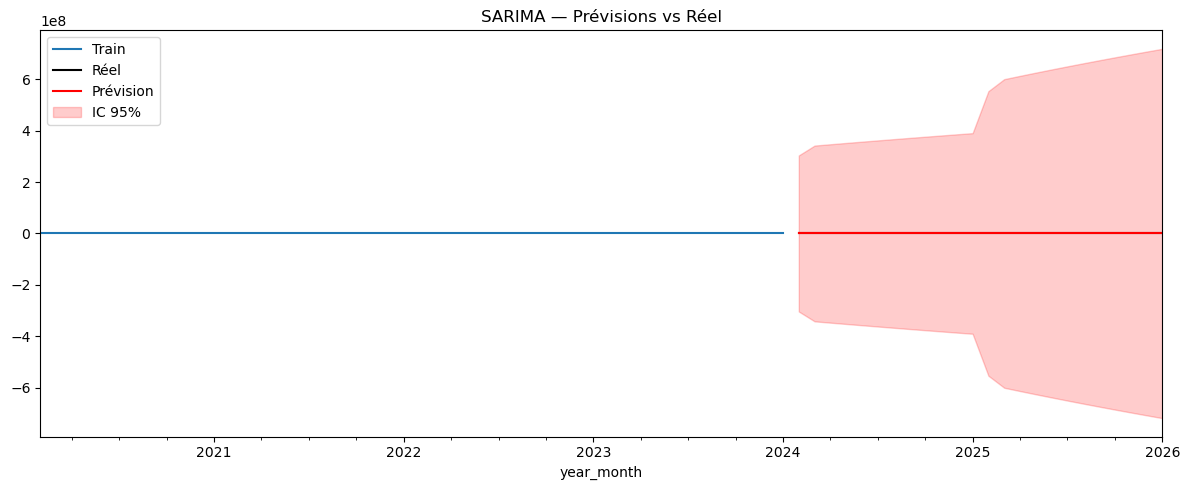

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=471.223, Time=0.66 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=506.880, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=503.538, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=489.549, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=483.020, Time=0.47 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=482.359, Time=0.50 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=459.429, Time=1.99 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=461.525, Time=1.51 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=458.461, Time=2.60 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=456.499, Time=1.32 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=467.290, Time=1.11 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=455.023, Time=0.96 sec
 ARIMA(1,1,2)(0,1,2)[12]             : AIC=465.953, Time=0.70 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=469.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  109
Model:             SARIMAX(0, 1, 2)x(1, 1, 2, 12)   Log Likelihood               -1364.680
Date:                            Mon, 16 Mar 2026   AIC                           2741.361
Time:                                    14:52:34   BIC                           2754.765
Sample:                                01-01-2015   HQIC                          2746.679
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4819         -0        inf      0.000      -0.482      -0.482
ma.L2         -0.3221         -0   

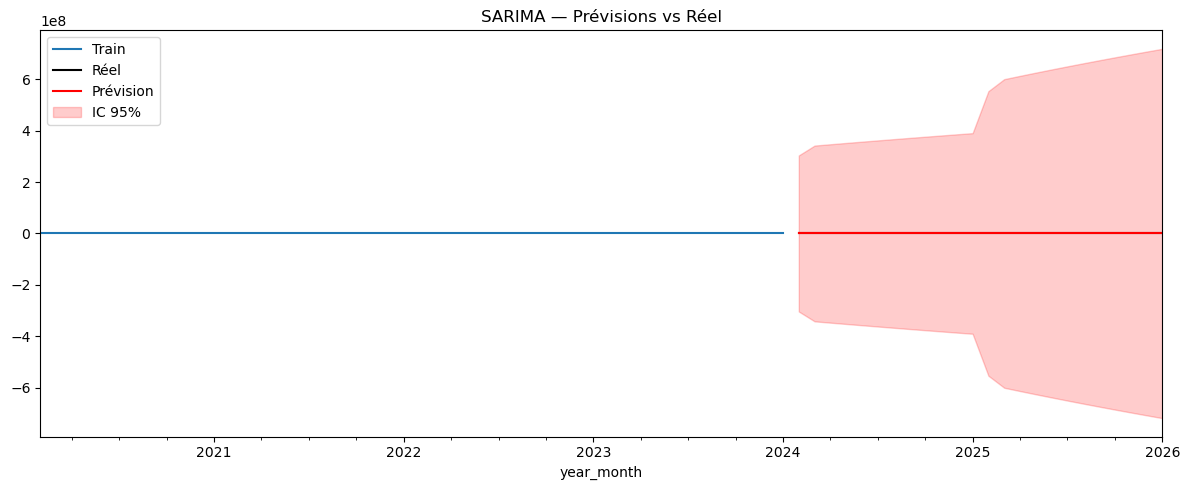

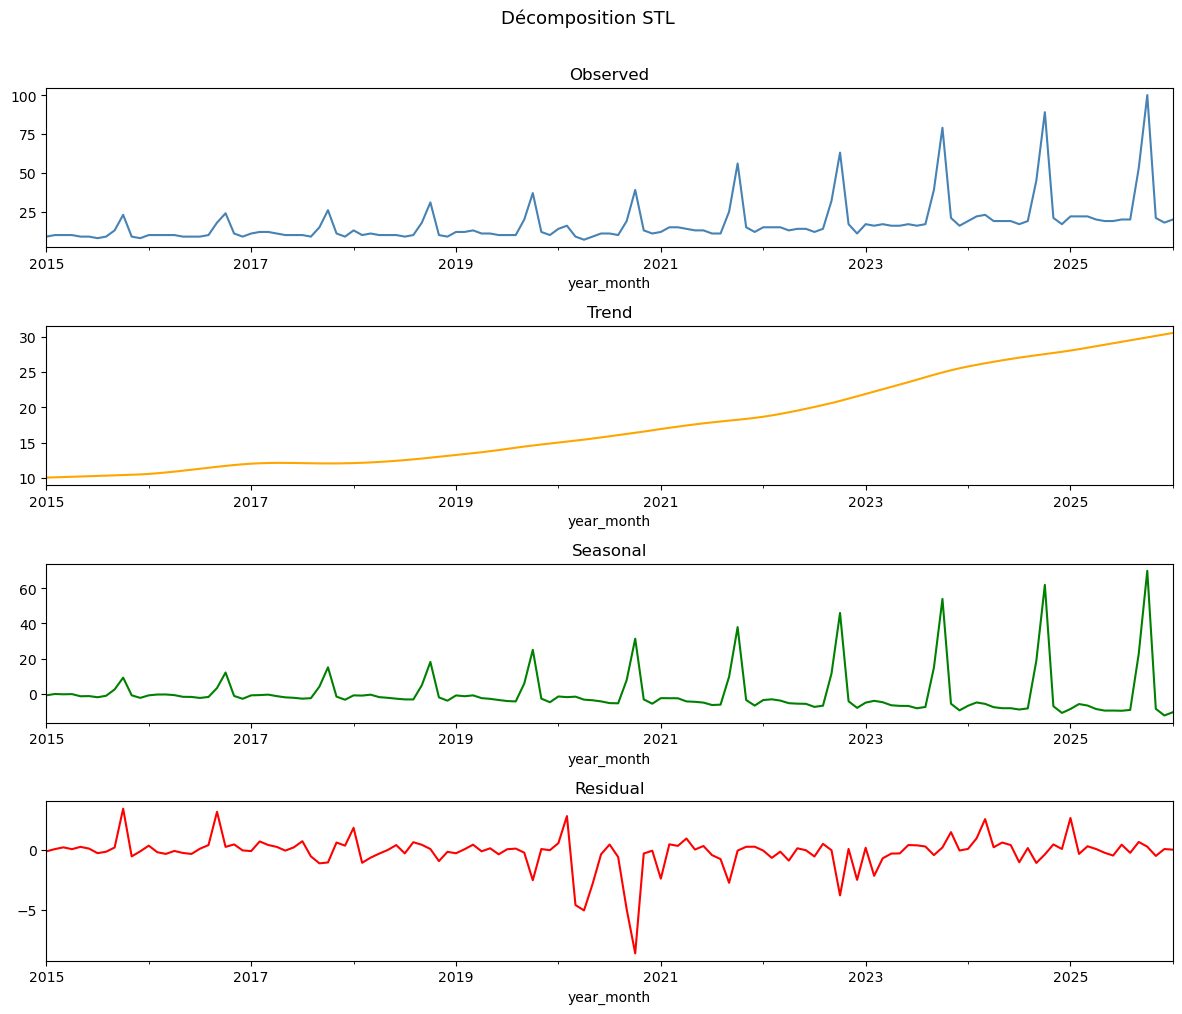

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=471.223, Time=0.66 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=506.880, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=503.538, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=489.549, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=483.020, Time=0.47 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=482.359, Time=0.50 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=459.429, Time=1.99 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=461.525, Time=1.51 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=458.461, Time=2.60 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=456.499, Time=1.32 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=467.290, Time=1.11 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=455.023, Time=0.96 sec
 ARIMA(1,1,2)(0,1,2)[12]             : AIC=465.953, Time=0.70 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=469.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  109
Model:             SARIMAX(0, 1, 2)x(1, 1, 2, 12)   Log Likelihood               -1364.680
Date:                            Mon, 16 Mar 2026   AIC                           2741.361
Time:                                    14:52:34   BIC                           2754.765
Sample:                                01-01-2015   HQIC                          2746.679
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4819         -0        inf      0.000      -0.482      -0.482
ma.L2         -0.3221         -0   

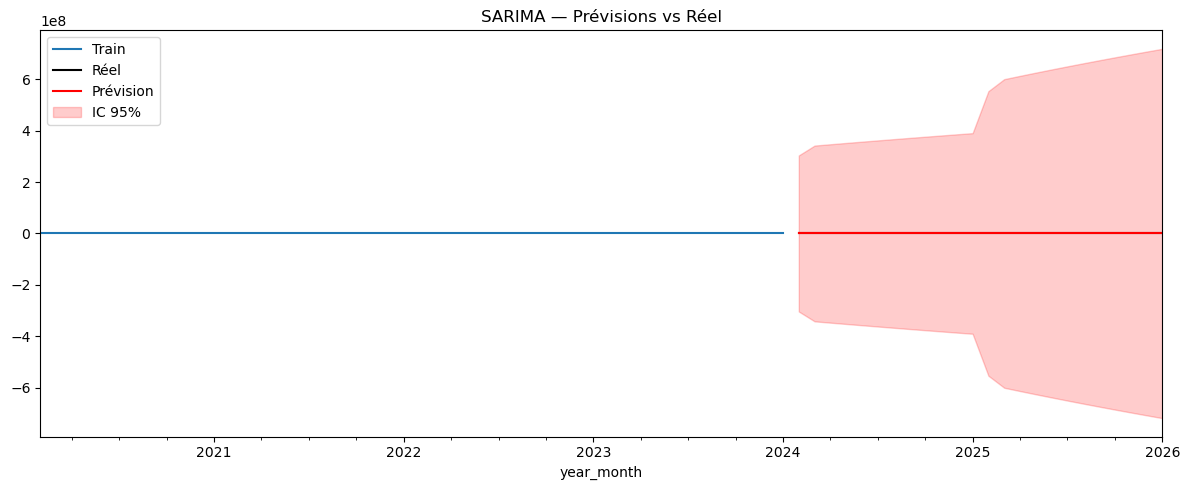

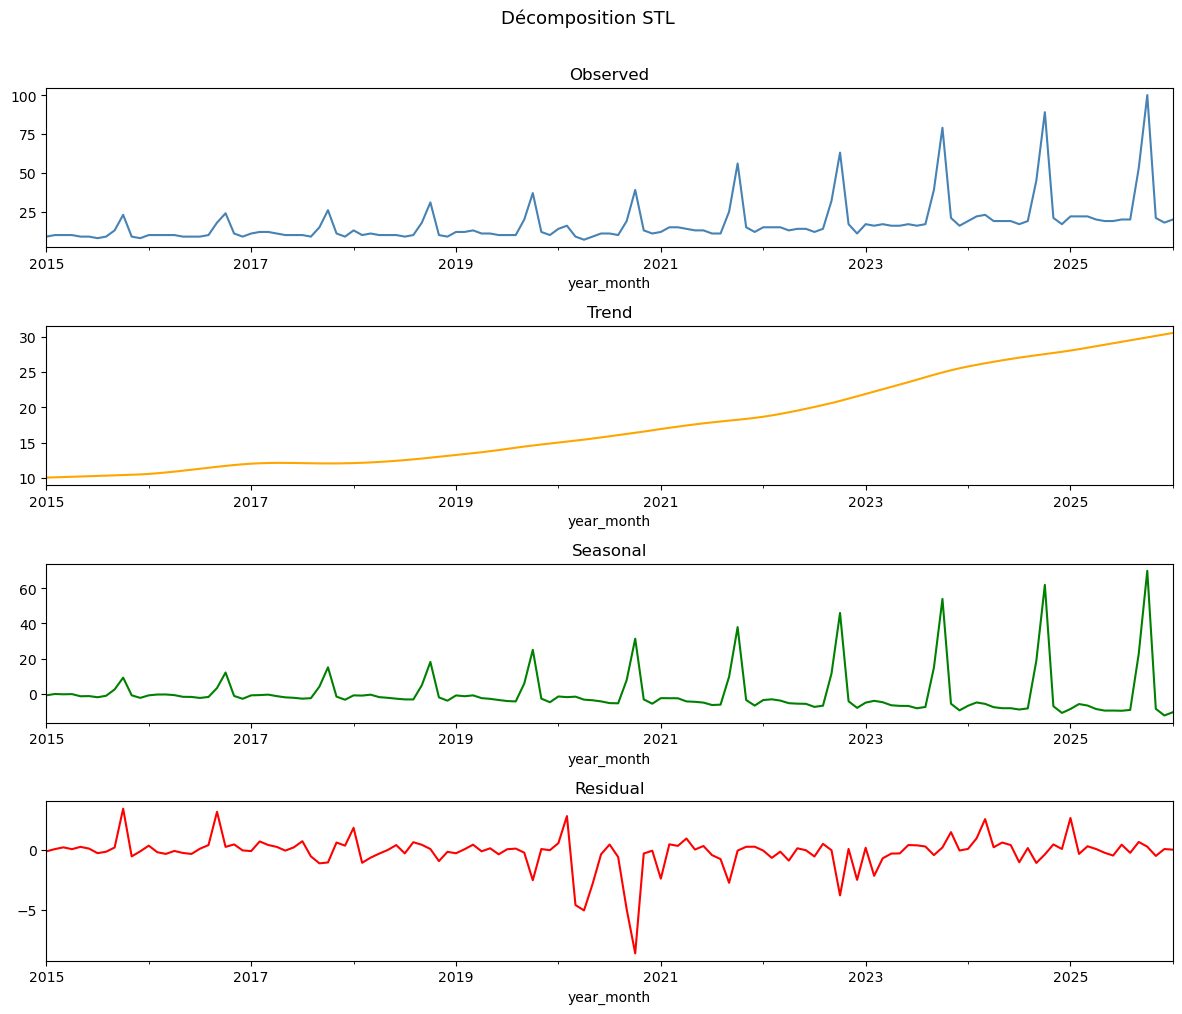

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.28 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1414.207, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1390.543, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1391.308, Time=0.27 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1414.986, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1405.088, Time=0.03 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=1389.009, Time=0.76 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.47 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=1390.601, Time=0.98 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=1397.345, Time=0.77 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=1390.869, Time=1.05 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=1390.922, Time=1.42 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=1390.826, Time=0.76 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=1

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=471.223, Time=0.66 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=506.880, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=503.538, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=489.549, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=483.020, Time=0.47 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=482.359, Time=0.50 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=459.429, Time=1.99 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=461.525, Time=1.51 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=458.461, Time=2.60 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=456.499, Time=1.32 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=467.290, Time=1.11 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=455.023, Time=0.96 sec
 ARIMA(1,1,2)(0,1,2)[12]             : AIC=465.953, Time=0.70 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=469.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  109
Model:             SARIMAX(0, 1, 2)x(1, 1, 2, 12)   Log Likelihood               -1364.680
Date:                            Mon, 16 Mar 2026   AIC                           2741.361
Time:                                    14:52:34   BIC                           2754.765
Sample:                                01-01-2015   HQIC                          2746.679
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4819         -0        inf      0.000      -0.482      -0.482
ma.L2         -0.3221         -0   

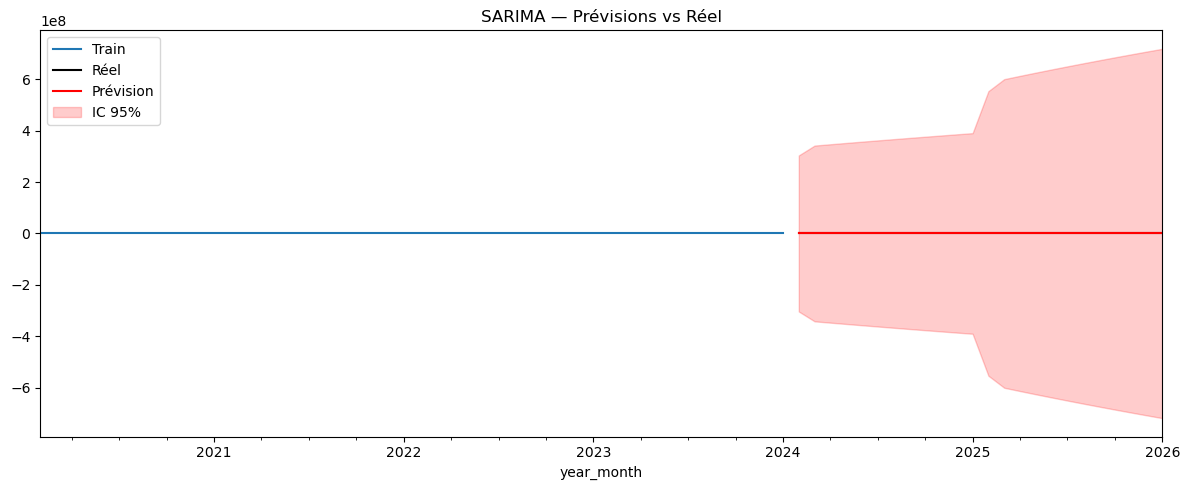

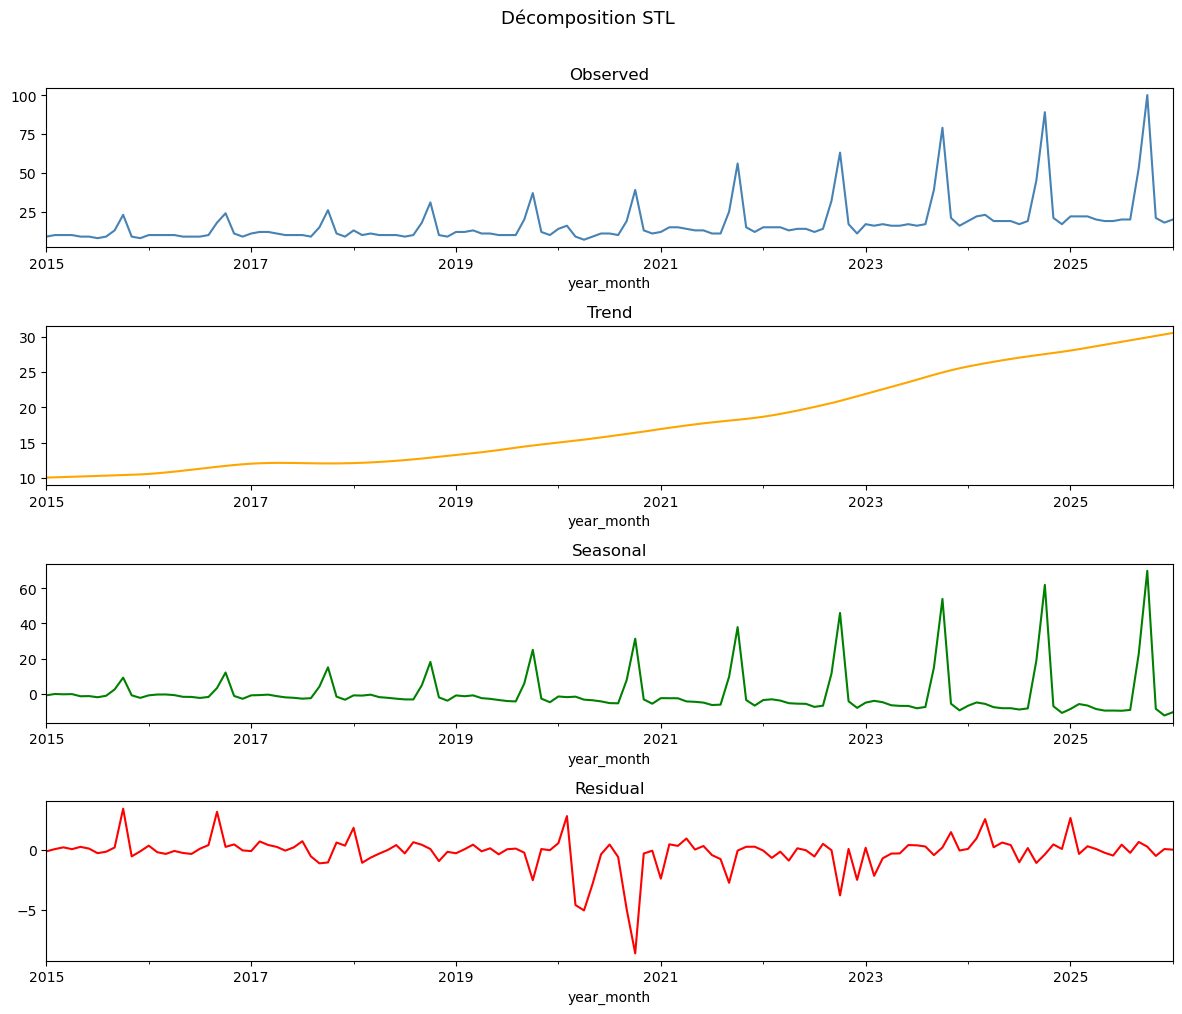

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.28 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1414.207, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1390.543, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1391.308, Time=0.27 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1414.986, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1405.088, Time=0.03 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=1389.009, Time=0.76 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.47 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=1390.601, Time=0.98 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=1397.345, Time=0.77 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=1390.869, Time=1.05 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=1390.922, Time=1.42 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=1390.826, Time=0.76 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=1

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=471.223, Time=0.66 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=506.880, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=503.538, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=489.549, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=483.020, Time=0.47 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=482.359, Time=0.50 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=459.429, Time=1.99 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=461.525, Time=1.51 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=458.461, Time=2.60 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=456.499, Time=1.32 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=467.290, Time=1.11 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=455.023, Time=0.96 sec
 ARIMA(1,1,2)(0,1,2)[12]             : AIC=465.953, Time=0.70 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=469.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  109
Model:             SARIMAX(0, 1, 2)x(1, 1, 2, 12)   Log Likelihood               -1364.680
Date:                            Mon, 16 Mar 2026   AIC                           2741.361
Time:                                    14:52:34   BIC                           2754.765
Sample:                                01-01-2015   HQIC                          2746.679
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4819         -0        inf      0.000      -0.482      -0.482
ma.L2         -0.3221         -0   

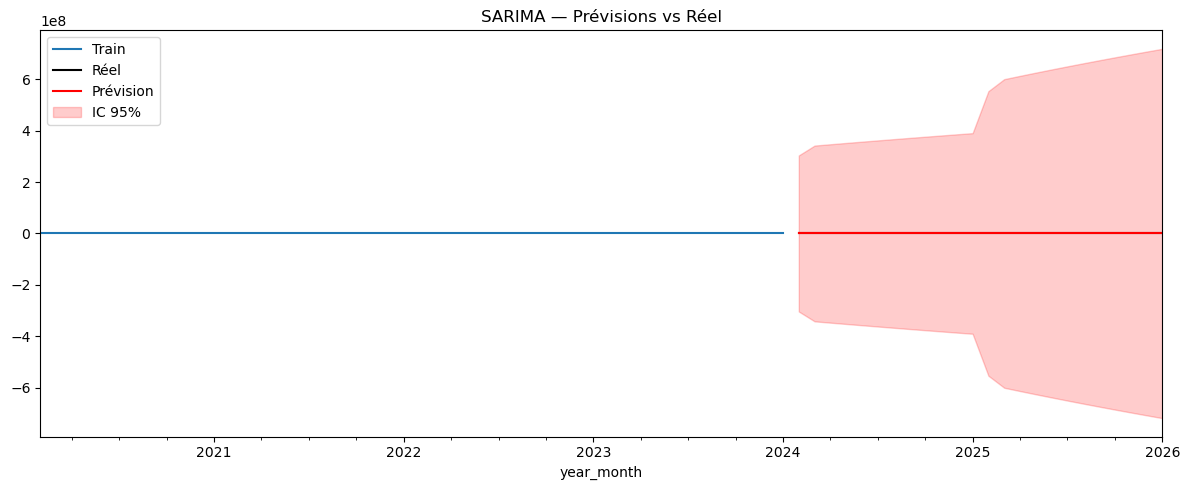

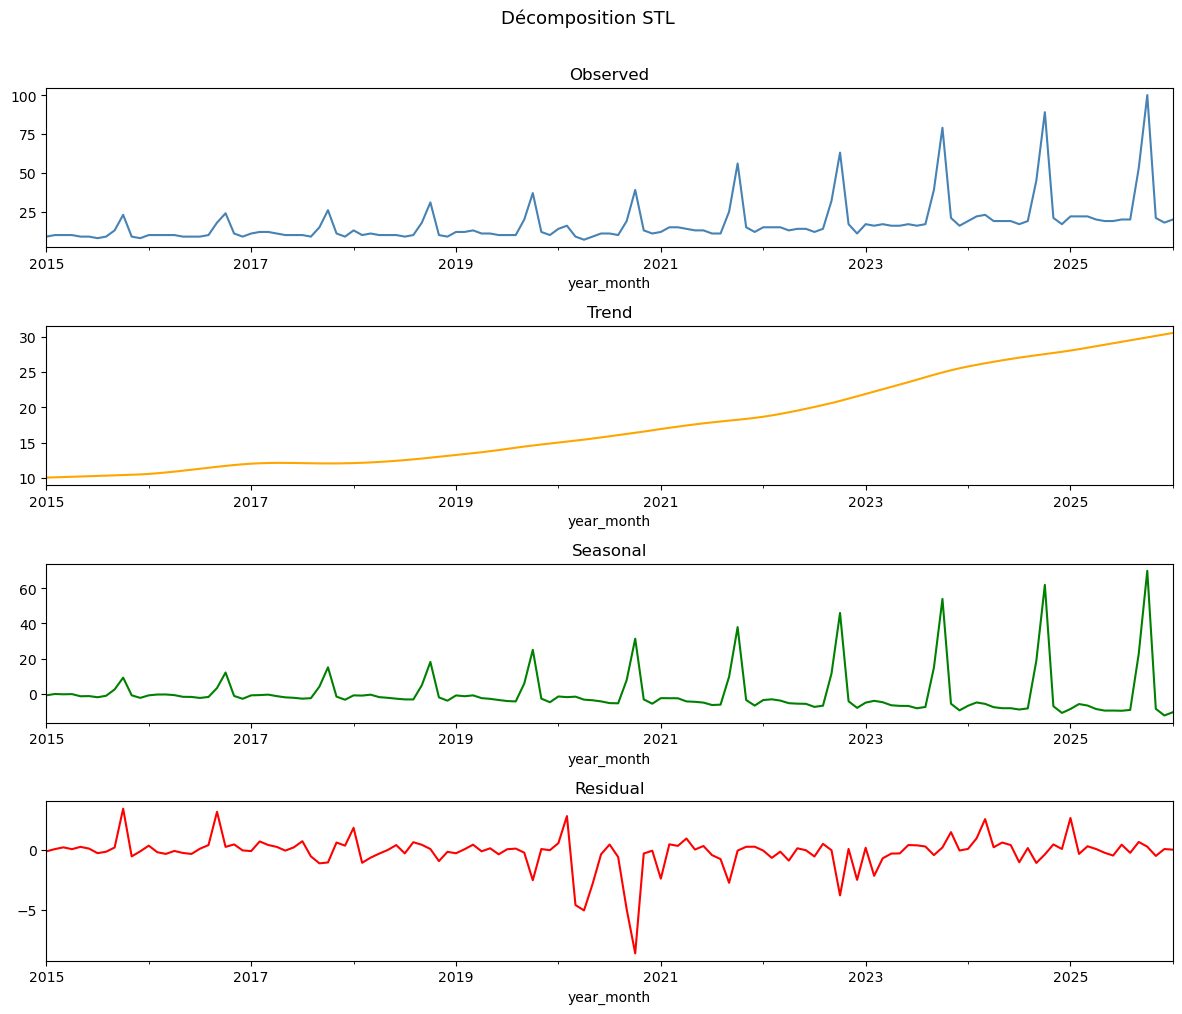

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.28 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1414.207, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1390.543, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1391.308, Time=0.27 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1414.986, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1405.088, Time=0.03 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=1389.009, Time=0.76 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.47 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=1390.601, Time=0.98 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=1397.345, Time=0.77 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=1390.869, Time=1.05 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=1390.922, Time=1.42 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=1390.826, Time=0.76 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=1

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  108
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -519.882
Date:                            Mon, 16 Mar 2026   AIC                           1047.763
Time:                                    14:52:47   BIC                           1056.814
Sample:                                01-01-2015   HQIC                          1051.362
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3768      0.167      2.260      0.024       0.050       0.704
ar.S.L12      -0.5079      0.096   

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=471.223, Time=0.66 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=506.880, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=503.538, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=489.549, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=483.020, Time=0.47 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=482.359, Time=0.50 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=459.429, Time=1.99 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=461.525, Time=1.51 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=458.461, Time=2.60 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=456.499, Time=1.32 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=467.290, Time=1.11 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=455.023, Time=0.96 sec
 ARIMA(1,1,2)(0,1,2)[12]             : AIC=465.953, Time=0.70 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=469.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  109
Model:             SARIMAX(0, 1, 2)x(1, 1, 2, 12)   Log Likelihood               -1364.680
Date:                            Mon, 16 Mar 2026   AIC                           2741.361
Time:                                    14:52:34   BIC                           2754.765
Sample:                                01-01-2015   HQIC                          2746.679
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4819         -0        inf      0.000      -0.482      -0.482
ma.L2         -0.3221         -0   

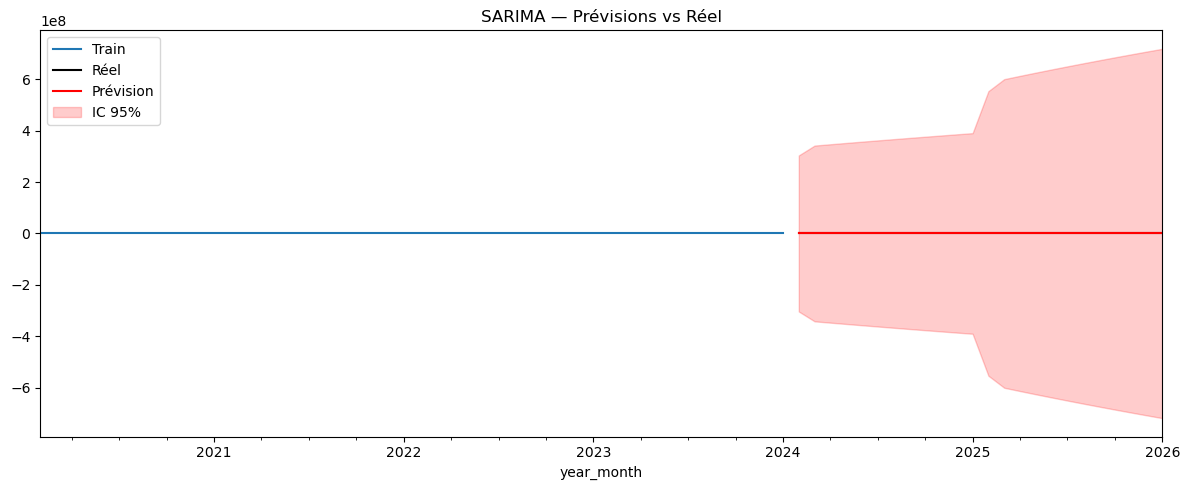

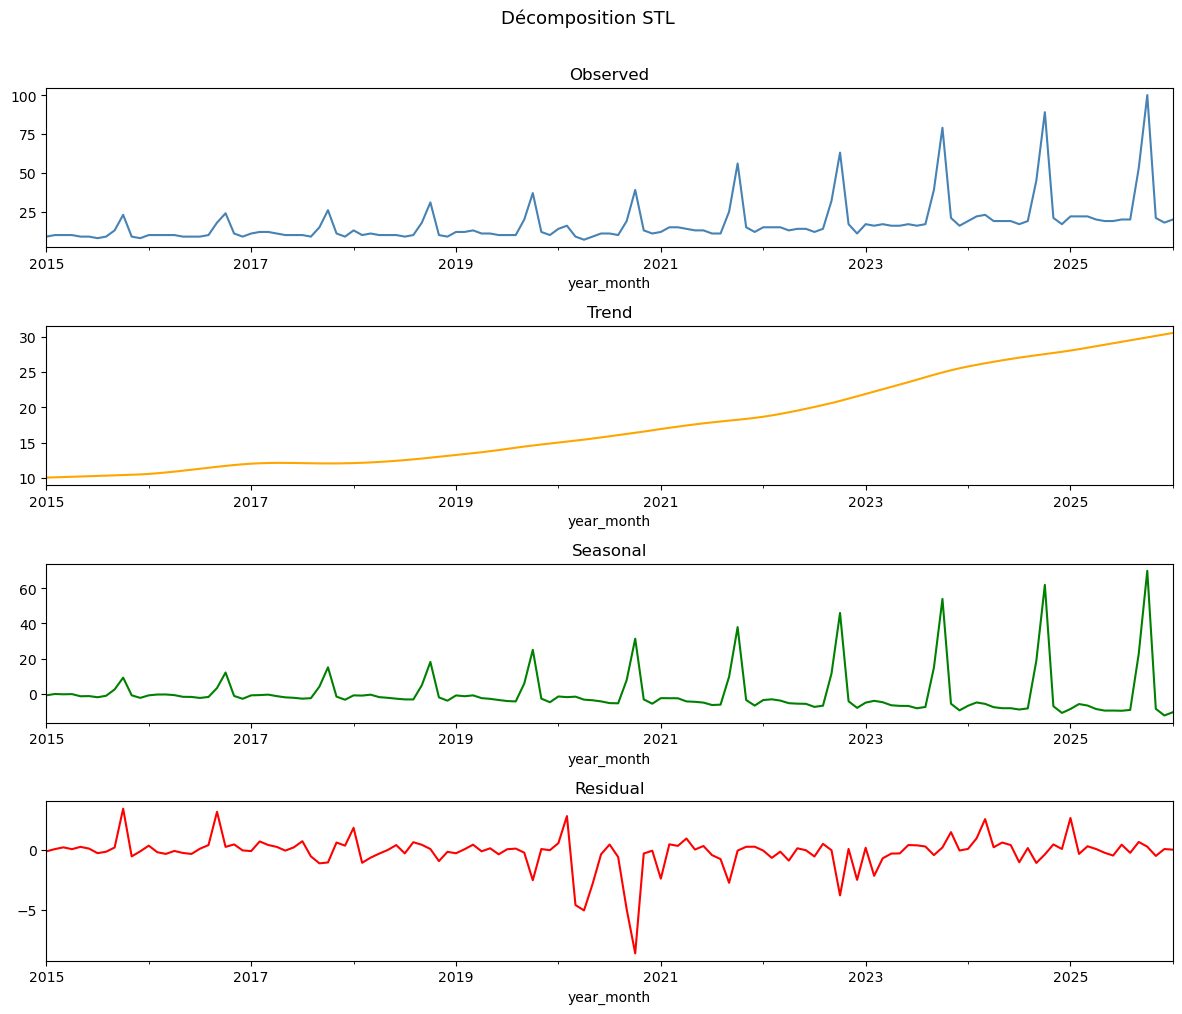

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.28 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1414.207, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1390.543, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1391.308, Time=0.27 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1414.986, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1405.088, Time=0.03 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=1389.009, Time=0.76 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.47 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=1390.601, Time=0.98 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=1397.345, Time=0.77 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=1390.869, Time=1.05 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=1390.922, Time=1.42 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=1390.826, Time=0.76 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=1

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  108
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -519.882
Date:                            Mon, 16 Mar 2026   AIC                           1047.763
Time:                                    14:52:47   BIC                           1056.814
Sample:                                01-01-2015   HQIC                          1051.362
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3768      0.167      2.260      0.024       0.050       0.704
ar.S.L12      -0.5079      0.096   

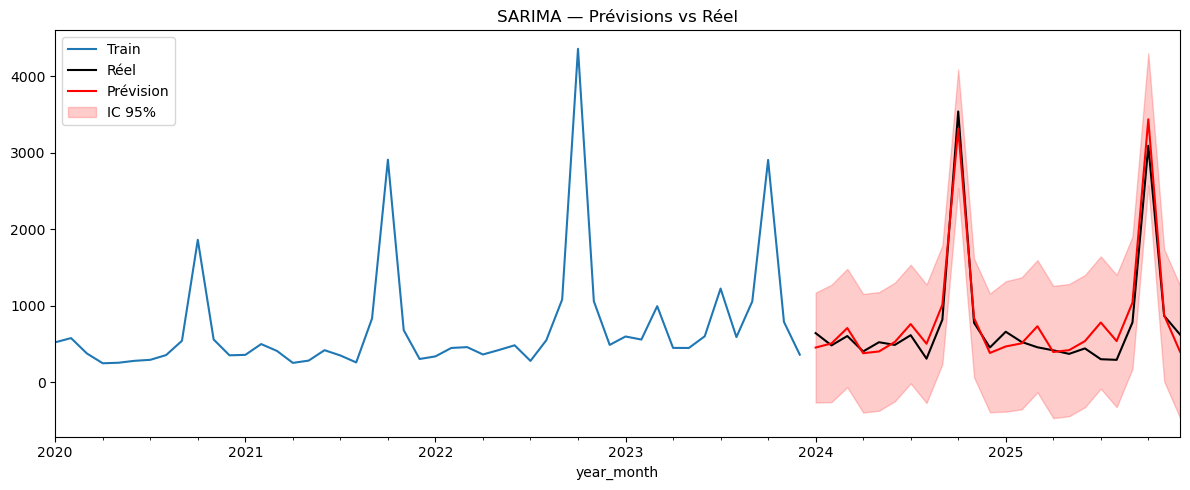

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=471.223, Time=0.66 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=506.880, Time=0.03 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=503.538, Time=0.08 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=489.549, Time=0.14 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=483.020, Time=0.47 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=482.359, Time=0.50 sec
 ARIMA(2,1,2)(2,1,1)[12]             : AIC=459.429, Time=1.99 sec
 ARIMA(2,1,2)(2,1,0)[12]             : AIC=461.525, Time=1.51 sec
 ARIMA(2,1,2)(2,1,2)[12]             : AIC=458.461, Time=2.60 sec
 ARIMA(2,1,2)(1,1,2)[12]             : AIC=456.499, Time=1.32 sec
 ARIMA(2,1,2)(0,1,2)[12]             : AIC=467.290, Time=1.11 sec
 ARIMA(1,1,2)(1,1,2)[12]             : AIC=455.023, Time=0.96 sec
 ARIMA(1,1,2)(0,1,2)[12]             : AIC=465.953, Time=0.70 sec
 ARIMA(1,1,2)(1,1,1)[12]             : AIC=469.

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:3016: RuntimeWarning: divide by zero encountered in divide
  return self.params / self.bse


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  109
Model:             SARIMAX(0, 1, 2)x(1, 1, 2, 12)   Log Likelihood               -1364.680
Date:                            Mon, 16 Mar 2026   AIC                           2741.361
Time:                                    14:52:34   BIC                           2754.765
Sample:                                01-01-2015   HQIC                          2746.679
                                     - 01-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4819         -0        inf      0.000      -0.482      -0.482
ma.L2         -0.3221         -0   

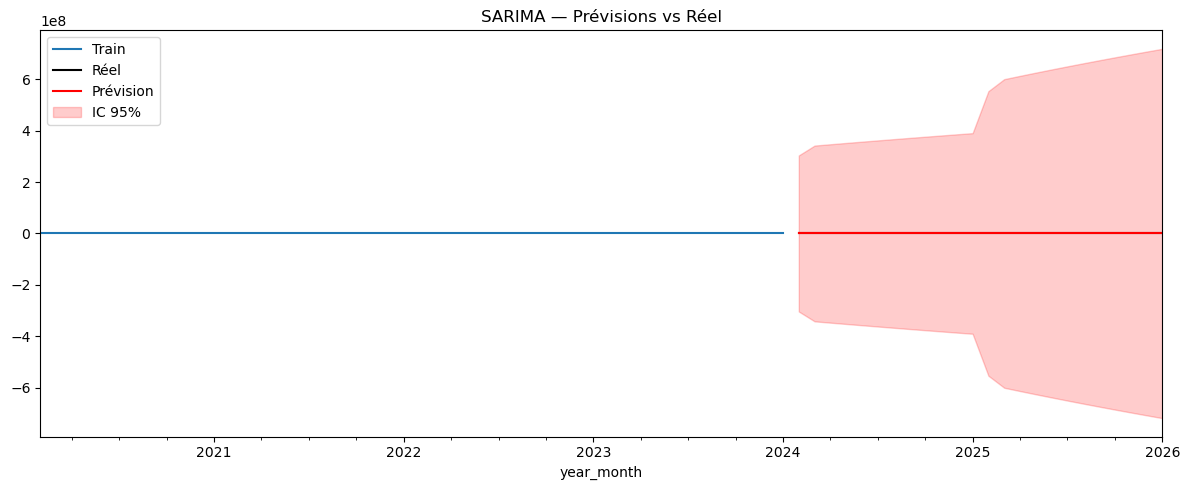

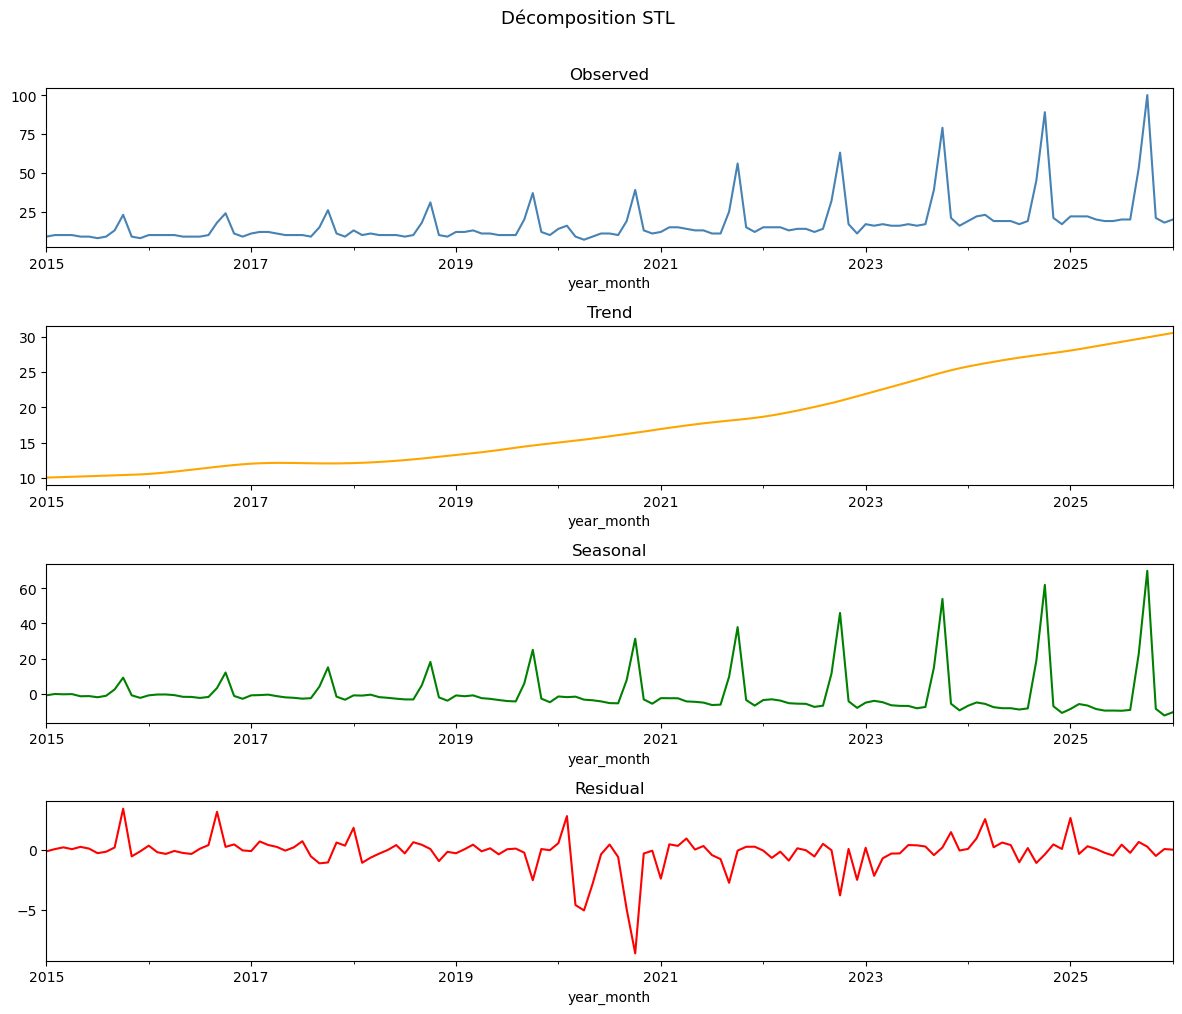

Recherche automatique des ordres avec auto_arima...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=inf, Time=1.28 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1414.207, Time=0.02 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1390.543, Time=0.36 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1391.308, Time=0.27 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1414.986, Time=0.02 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1405.088, Time=0.03 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=1389.009, Time=0.76 sec
 ARIMA(1,0,0)(2,1,1)[12] intercept   : AIC=inf, Time=1.47 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=1390.601, Time=0.98 sec
 ARIMA(0,0,0)(2,1,0)[12] intercept   : AIC=1397.345, Time=0.77 sec
 ARIMA(2,0,0)(2,1,0)[12] intercept   : AIC=1390.869, Time=1.05 sec
 ARIMA(1,0,1)(2,1,0)[12] intercept   : AIC=1390.922, Time=1.42 sec
 ARIMA(0,0,1)(2,1,0)[12] intercept   : AIC=1390.826, Time=0.76 sec
 ARIMA(2,0,1)(2,1,0)[12] intercept   : AIC=1

c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Pierre\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                       Octobre Rose   No. Observations:                  108
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 12)   Log Likelihood                -519.882
Date:                            Mon, 16 Mar 2026   AIC                           1047.763
Time:                                    14:52:47   BIC                           1056.814
Sample:                                01-01-2015   HQIC                          1051.362
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3768      0.167      2.260      0.024       0.050       0.704
ar.S.L12      -0.5079      0.096   

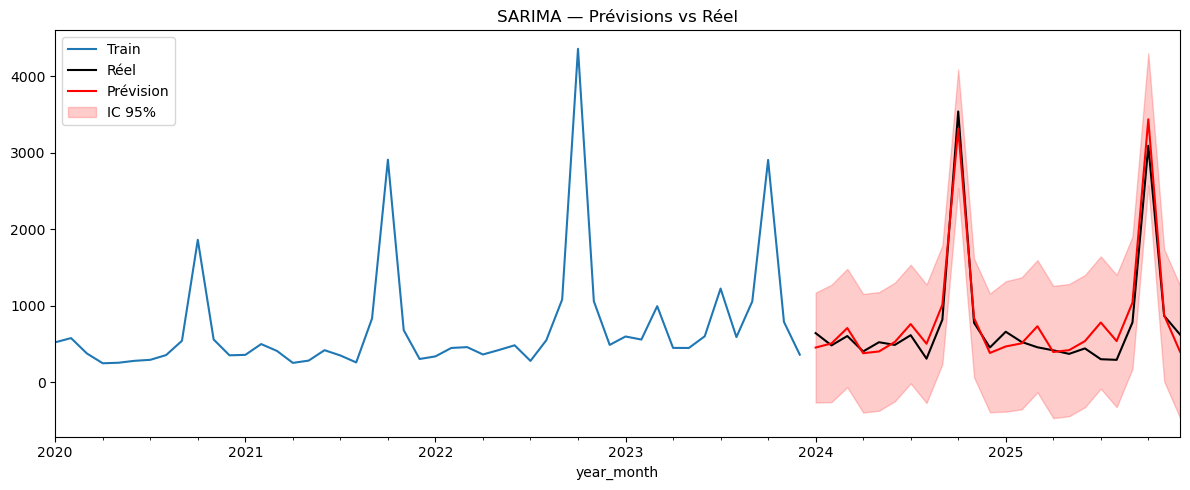

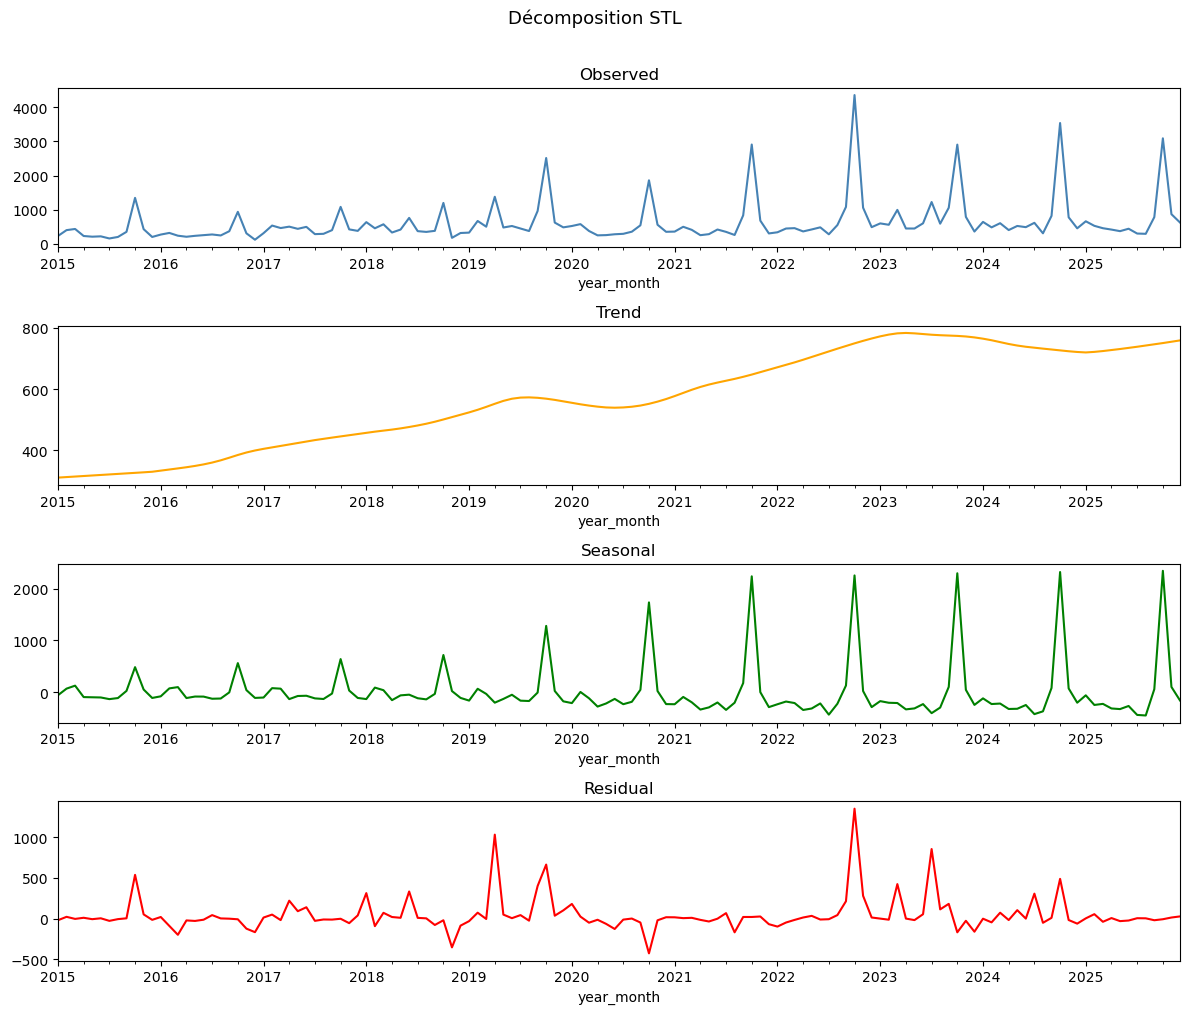

In [36]:
result_oc_gt, predictions_oc_gt, trend_oc_gt, seasonal_oc_gt, residual_oc_gt = run_sarima(
    series    = GT_Octobre_rose,   # ← votre pd.Series ici
    s         = 12,         # ← 52 pour hebdomadaire
    test_size = 24
)

result_oc_mc, predictions_oc_mc, trend_oc_mc, seasonal_oc_mc, residual_oc_mc = run_sarima(
    series    = MC_Octobre_rose,   # ← votre pd.Series ici
    s         = 12,         # ← 52 pour hebdomadaire
    test_size = 24
)

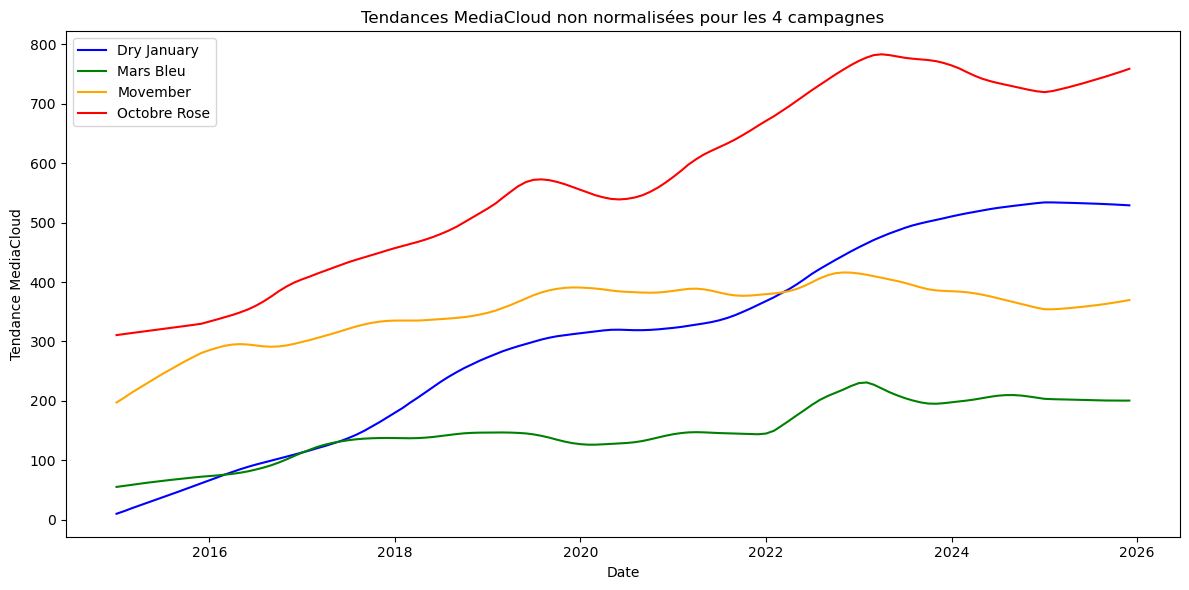

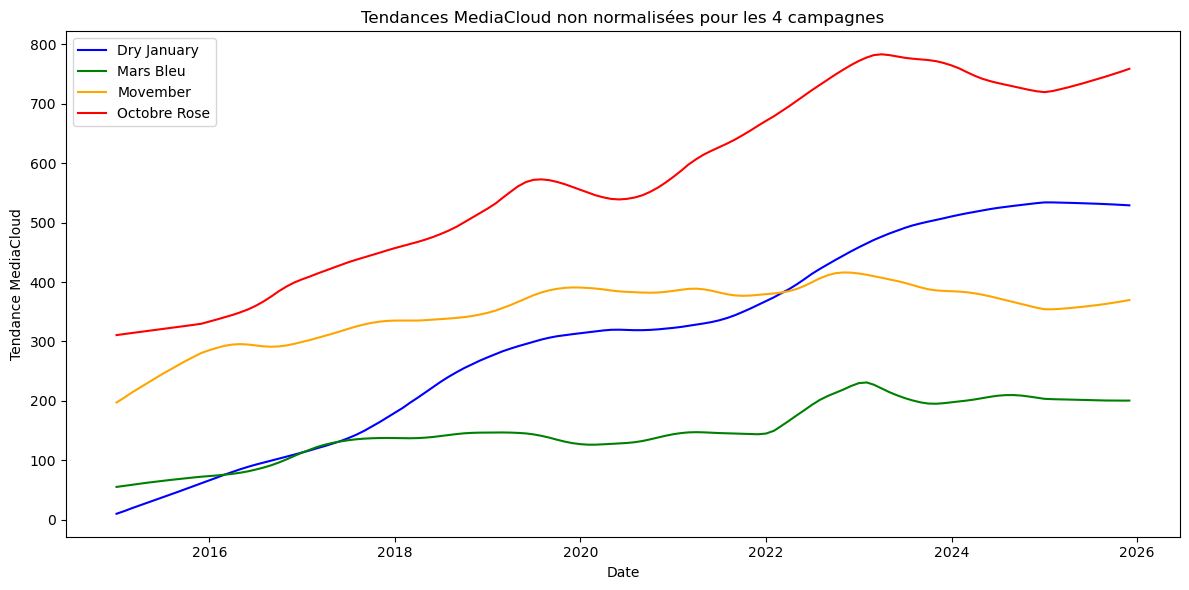

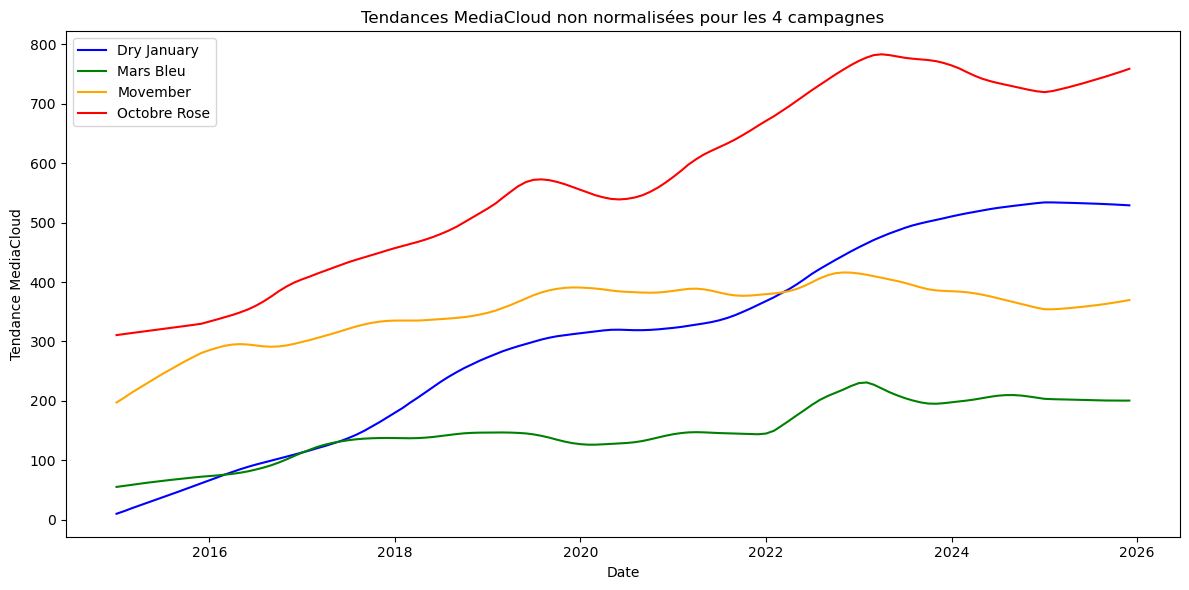

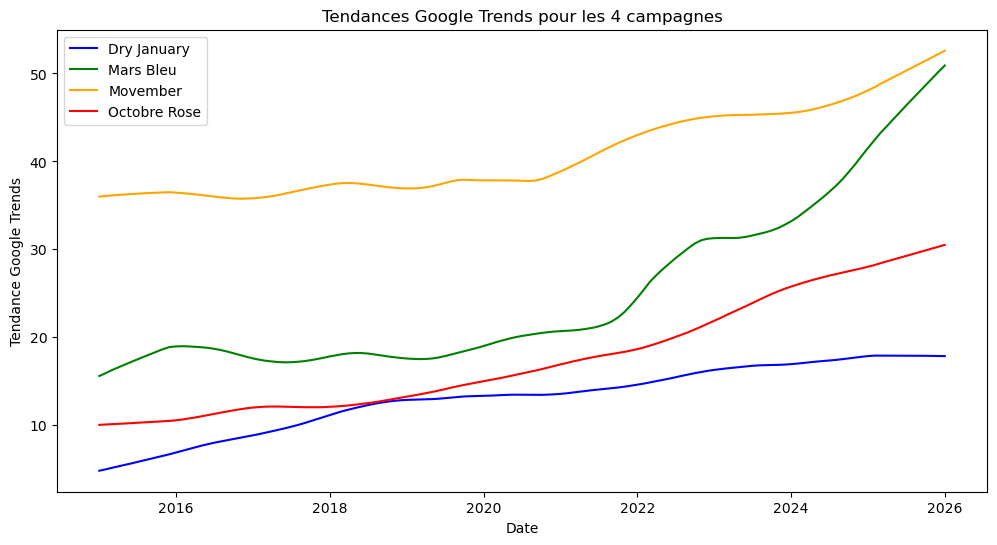

In [37]:
plt.figure(figsize=(12,6))
plt.plot(trend_dry_mc, label="Dry January", color="blue")
plt.plot(trend_ma_mc, label="Mars Bleu", color="green")
plt.plot(trend_mov_mc, label="Movember", color="orange")
plt.plot(trend_oc_mc, label="Octobre Rose", color="red")
plt.title("Tendances MediaCloud non normalisées pour les 4 campagnes")
plt.xlabel("Date")
plt.ylabel("Tendance MediaCloud")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(trend_dry_gt, label="Dry January", color="blue")
plt.plot(trend_ma_gt, label="Mars Bleu", color="green")
plt.plot(trend_mov_gt, label="Movember", color="orange")
plt.plot(trend_oc_gt, label="Octobre Rose", color="red")
plt.title("Tendances Google Trends pour les 4 campagnes")
plt.xlabel("Date")
plt.ylabel("Tendance Google Trends")
plt.legend()

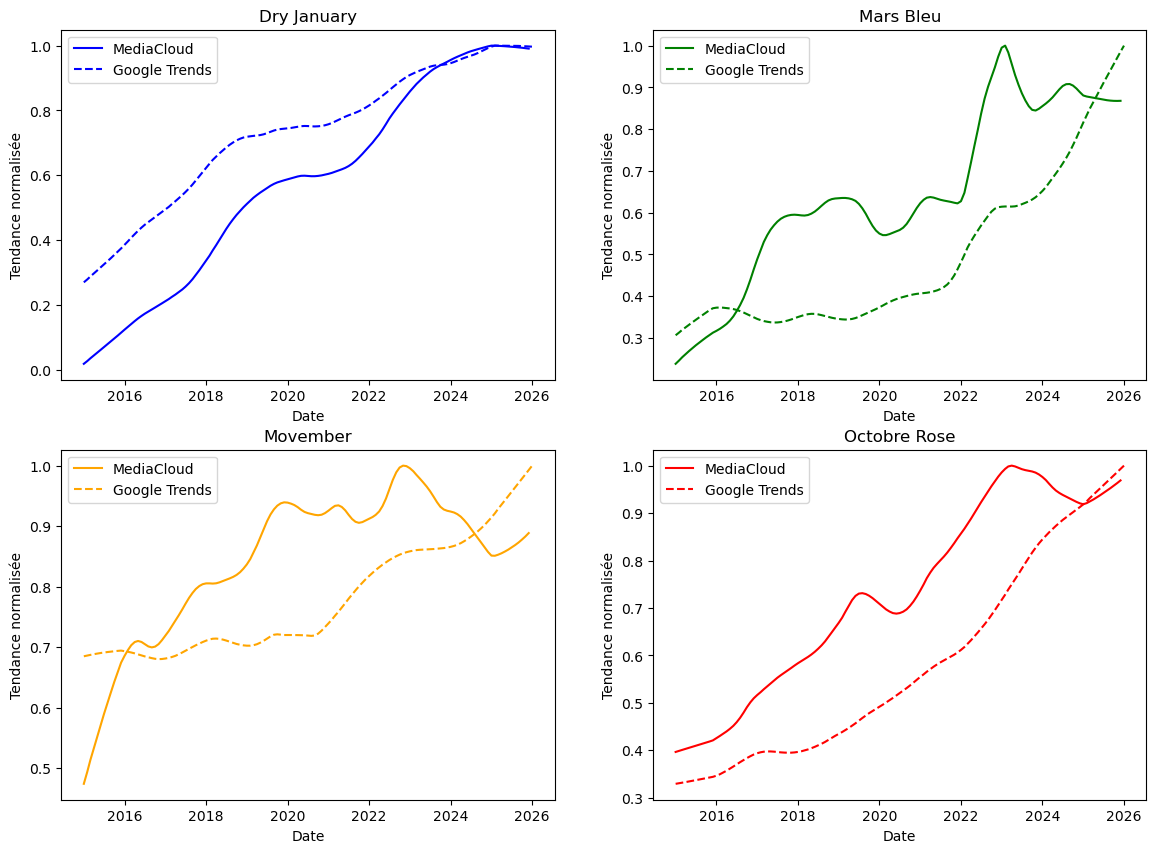

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dry January (bleu)
axes[0, 0].plot(trend_dry_mc / trend_dry_mc.max(), label="MediaCloud", color="blue", linestyle="-")
axes[0, 0].plot(trend_dry_gt / trend_dry_gt.max(), label="Google Trends", color="blue", linestyle="--")
axes[0, 0].set_title("Dry January")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Tendance normalisée")
axes[0, 0].legend()

# Mars Bleu (vert)
axes[0, 1].plot(trend_ma_mc / trend_ma_mc.max(), label="MediaCloud", color="green", linestyle="-")
axes[0, 1].plot(trend_ma_gt / trend_ma_gt.max(), label="Google Trends", color="green", linestyle="--")
axes[0, 1].set_title("Mars Bleu")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Tendance normalisée")
axes[0, 1].legend()

# Movember (orange)
axes[1, 0].plot(trend_mov_mc / trend_mov_mc.max(), label="MediaCloud", color="orange", linestyle="-")
axes[1, 0].plot(trend_mov_gt / trend_mov_gt.max(), label="Google Trends", color="orange", linestyle="--")
axes[1, 0].set_title("Movember")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Tendance normalisée")
axes[1, 0].legend()

# Octobre Rose (rouge)
axes[1, 1].plot(trend_oc_mc / trend_oc_mc.max(), label="MediaCloud", color="red", linestyle="-")
axes[1, 1].plot(trend_oc_gt / trend_oc_gt.max(), label="Google Trends", color="red", linestyle="--")
axes[1, 1].set_title("Octobre Rose")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Tendance normalisée")
axes[1, 1].legend()

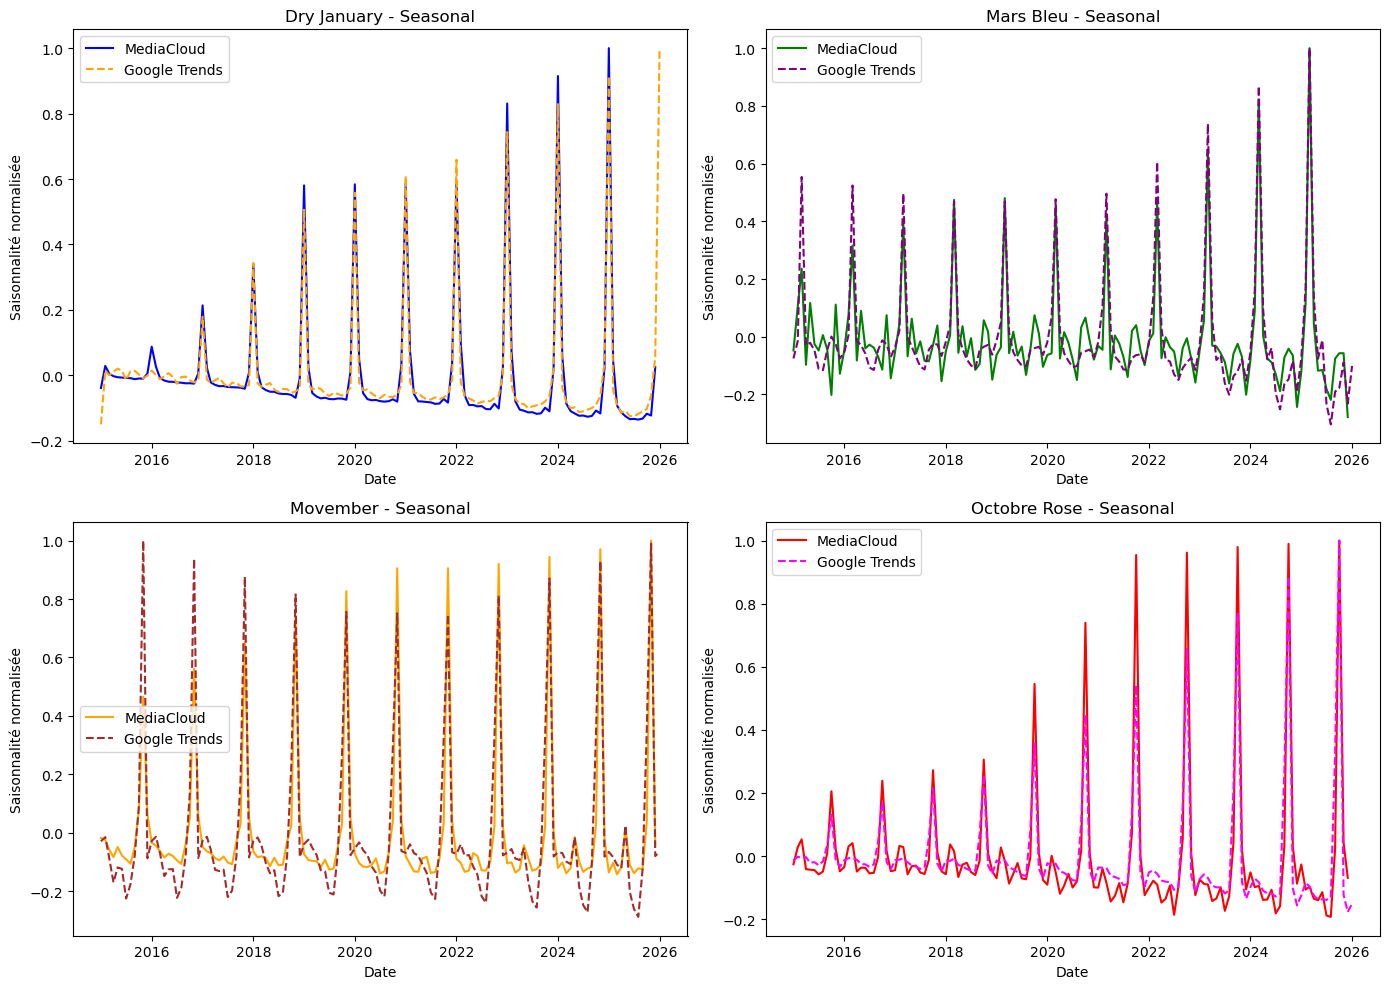

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dry January
axes[0, 0].plot(seasonal_dry_mc / seasonal_dry_mc.max(), label="MediaCloud", color="blue", linestyle="-")
axes[0, 0].plot(seasonal_dry_gt / seasonal_dry_gt.max(), label="Google Trends", color="orange", linestyle="--")
axes[0, 0].set_title("Dry January - Seasonal")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Saisonnalité normalisée")
axes[0, 0].legend()

# Mars Bleu
axes[0, 1].plot(seasonal_ma_mc / seasonal_ma_mc.max(), label="MediaCloud", color="green", linestyle="-")
axes[0, 1].plot(seasonal_ma_gt / seasonal_ma_gt.max(), label="Google Trends", color="purple", linestyle="--")
axes[0, 1].set_title("Mars Bleu - Seasonal")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Saisonnalité normalisée")
axes[0, 1].legend()

# Movember
axes[1, 0].plot(seasonal_mov_mc / seasonal_mov_mc.max(), label="MediaCloud", color="orange", linestyle="-")
axes[1, 0].plot(seasonal_mov_gt / seasonal_mov_gt.max(), label="Google Trends", color="brown", linestyle="--")
axes[1, 0].set_title("Movember - Seasonal")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Saisonnalité normalisée")
axes[1, 0].legend()

# Octobre Rose
axes[1, 1].plot(seasonal_oc_mc / seasonal_oc_mc.max(), label="MediaCloud", color="red", linestyle="-")
axes[1, 1].plot(seasonal_oc_gt / seasonal_oc_gt.max(), label="Google Trends", color="magenta", linestyle="--")
axes[1, 1].set_title("Octobre Rose - Seasonal")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Saisonnalité normalisée")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

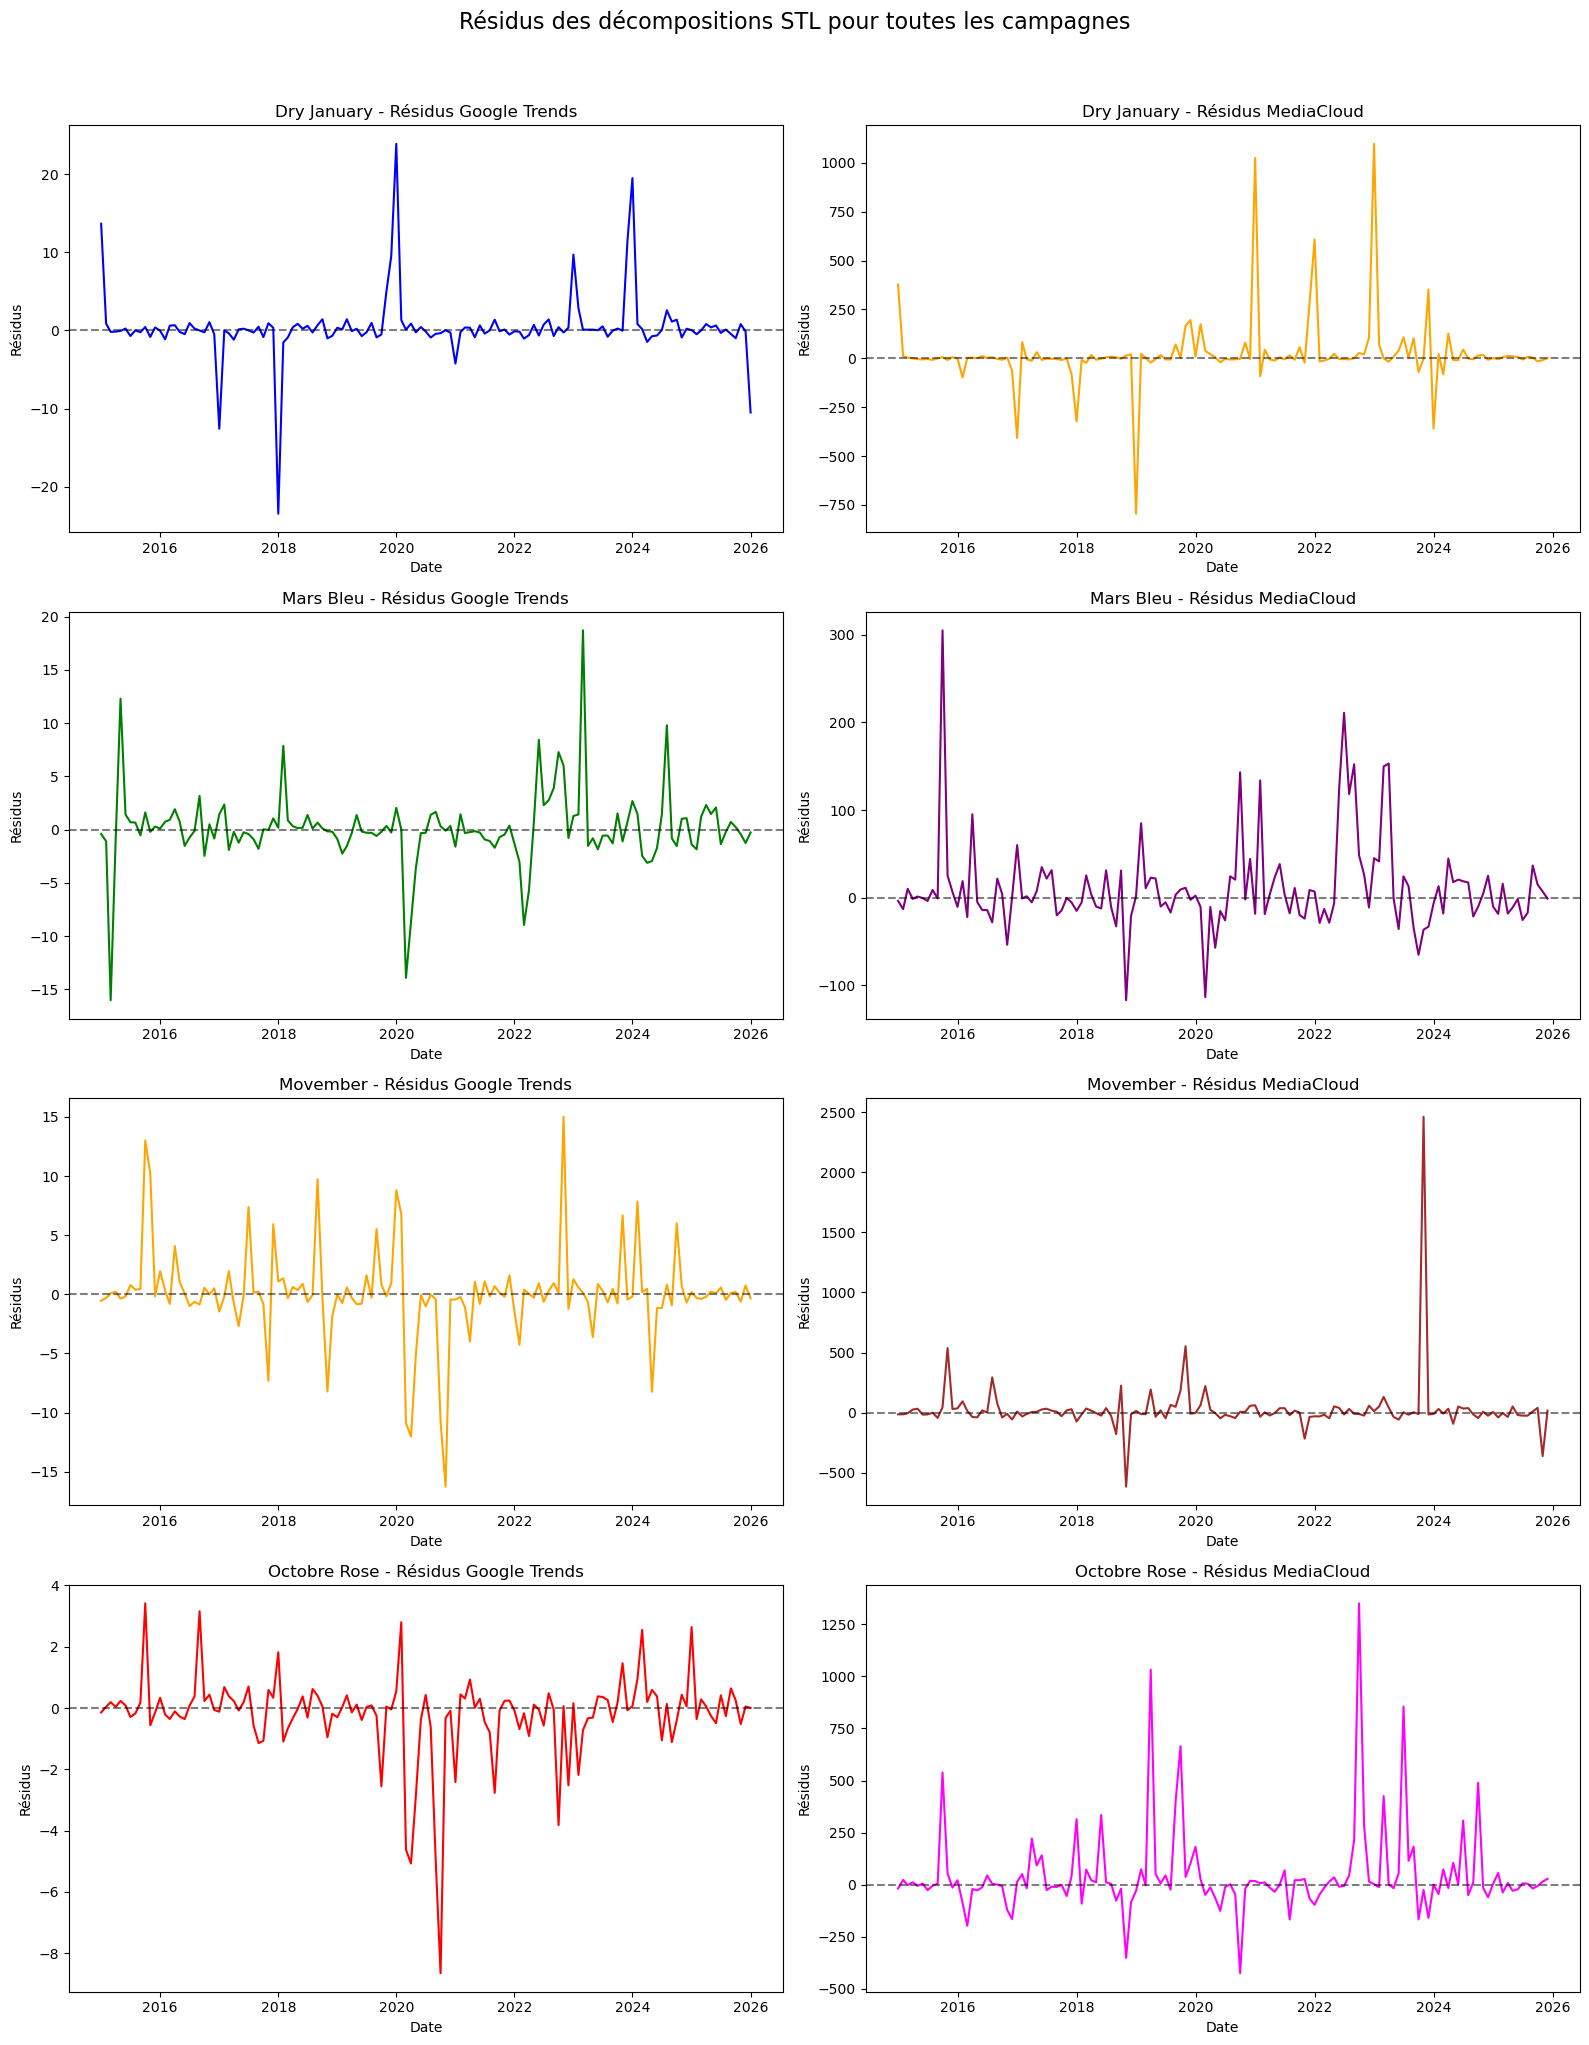

In [41]:
# Affichage des résidus pour toutes les campagnes
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# Dry January
axes[0, 0].plot(residual_dry_gt.index, residual_dry_gt.values, label="Google Trends", color="blue")
axes[0, 0].set_title("Dry January - Résidus Google Trends")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Résidus")
axes[0, 0].axhline(y=0, color="black", linestyle="--", alpha=0.5)

axes[0, 1].plot(residual_dry_mc.index, residual_dry_mc.values, label="MediaCloud", color="orange")
axes[0, 1].set_title("Dry January - Résidus MediaCloud")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Résidus")
axes[0, 1].axhline(y=0, color="black", linestyle="--", alpha=0.5)

# Mars Bleu
axes[1, 0].plot(residual_ma_gt.index, residual_ma_gt.values, label="Google Trends", color="green")
axes[1, 0].set_title("Mars Bleu - Résidus Google Trends")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Résidus")
axes[1, 0].axhline(y=0, color="black", linestyle="--", alpha=0.5)

axes[1, 1].plot(residual_ma_mc.index, residual_ma_mc.values, label="MediaCloud", color="purple")
axes[1, 1].set_title("Mars Bleu - Résidus MediaCloud")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Résidus")
axes[1, 1].axhline(y=0, color="black", linestyle="--", alpha=0.5)

# Movember
axes[2, 0].plot(residual_mov_gt.index, residual_mov_gt.values, label="Google Trends", color="orange")
axes[2, 0].set_title("Movember - Résidus Google Trends")
axes[2, 0].set_xlabel("Date")
axes[2, 0].set_ylabel("Résidus")
axes[2, 0].axhline(y=0, color="black", linestyle="--", alpha=0.5)

axes[2, 1].plot(residual_mov_mc.index, residual_mov_mc.values, label="MediaCloud", color="brown")
axes[2, 1].set_title("Movember - Résidus MediaCloud")
axes[2, 1].set_xlabel("Date")
axes[2, 1].set_ylabel("Résidus")
axes[2, 1].axhline(y=0, color="black", linestyle="--", alpha=0.5)

# Octobre Rose
axes[3, 0].plot(residual_oc_gt.index, residual_oc_gt.values, label="Google Trends", color="red")
axes[3, 0].set_title("Octobre Rose - Résidus Google Trends")
axes[3, 0].set_xlabel("Date")
axes[3, 0].set_ylabel("Résidus")
axes[3, 0].axhline(y=0, color="black", linestyle="--", alpha=0.5)

axes[3, 1].plot(residual_oc_mc.index, residual_oc_mc.values, label="MediaCloud", color="magenta")
axes[3, 1].set_title("Octobre Rose - Résidus MediaCloud")
axes[3, 1].set_xlabel("Date")
axes[3, 1].set_ylabel("Résidus")
axes[3, 1].axhline(y=0, color="black", linestyle="--", alpha=0.5)

plt.suptitle("Résidus des décompositions STL pour toutes les campagnes", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

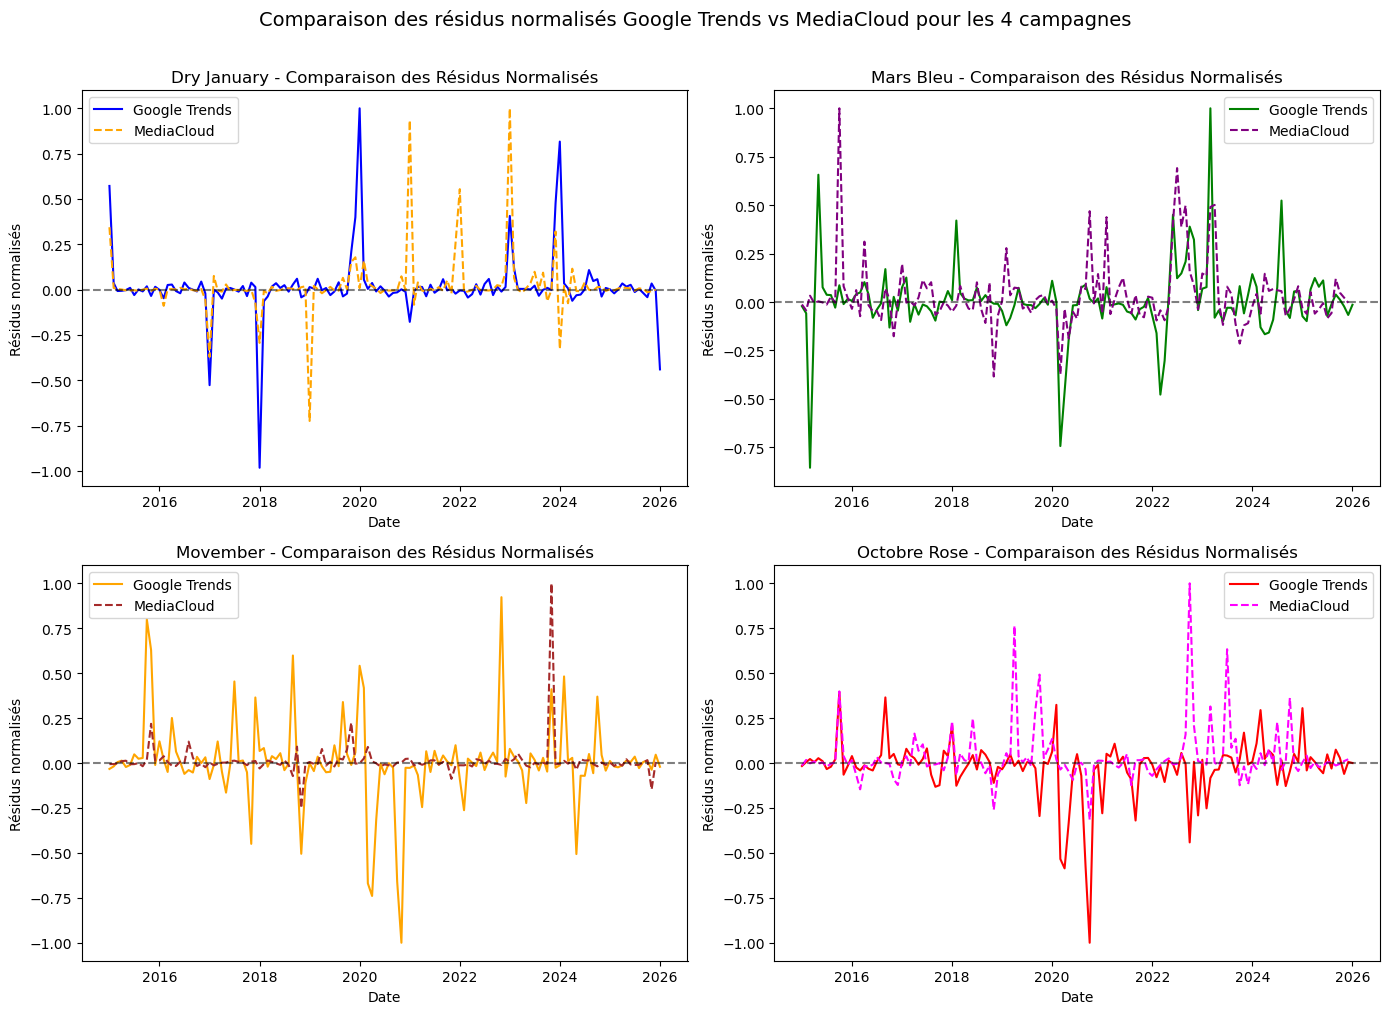

In [43]:
# Comparaison des résidus Google Trends vs MediaCloud pour chaque campagne
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dry January
axes[0, 0].plot(residual_dry_gt.index, residual_dry_gt / residual_dry_gt.abs().max(), label="Google Trends", color="blue", linestyle="-")
axes[0, 0].plot(residual_dry_mc.index, residual_dry_mc / residual_dry_mc.abs().max(), label="MediaCloud", color="orange", linestyle="--")
axes[0, 0].set_title("Dry January - Comparaison des Résidus Normalisés")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Résidus normalisés")
axes[0, 0].axhline(y=0, color="black", linestyle="--", alpha=0.5)
axes[0, 0].legend()

# Mars Bleu
axes[0, 1].plot(residual_ma_gt.index, residual_ma_gt / residual_ma_gt.abs().max(), label="Google Trends", color="green", linestyle="-")
axes[0, 1].plot(residual_ma_mc.index, residual_ma_mc / residual_ma_mc.abs().max(), label="MediaCloud", color="purple", linestyle="--")
axes[0, 1].set_title("Mars Bleu - Comparaison des Résidus Normalisés")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Résidus normalisés")
axes[0, 1].axhline(y=0, color="black", linestyle="--", alpha=0.5)
axes[0, 1].legend()

# Movember
axes[1, 0].plot(residual_mov_gt.index, residual_mov_gt / residual_mov_gt.abs().max(), label="Google Trends", color="orange", linestyle="-")
axes[1, 0].plot(residual_mov_mc.index, residual_mov_mc / residual_mov_mc.abs().max(), label="MediaCloud", color="brown", linestyle="--")
axes[1, 0].set_title("Movember - Comparaison des Résidus Normalisés")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Résidus normalisés")
axes[1, 0].axhline(y=0, color="black", linestyle="--", alpha=0.5)
axes[1, 0].legend()

# Octobre Rose
axes[1, 1].plot(residual_oc_gt.index, residual_oc_gt / residual_oc_gt.abs().max(), label="Google Trends", color="red", linestyle="-")
axes[1, 1].plot(residual_oc_mc.index, residual_oc_mc / residual_oc_mc.abs().max(), label="MediaCloud", color="magenta", linestyle="--")
axes[1, 1].set_title("Octobre Rose - Comparaison des Résidus Normalisés")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Résidus normalisés")
axes[1, 1].axhline(y=0, color="black", linestyle="--", alpha=0.5)
axes[1, 1].legend()

plt.suptitle("Comparaison des résidus normalisés Google Trends vs MediaCloud pour les 4 campagnes", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

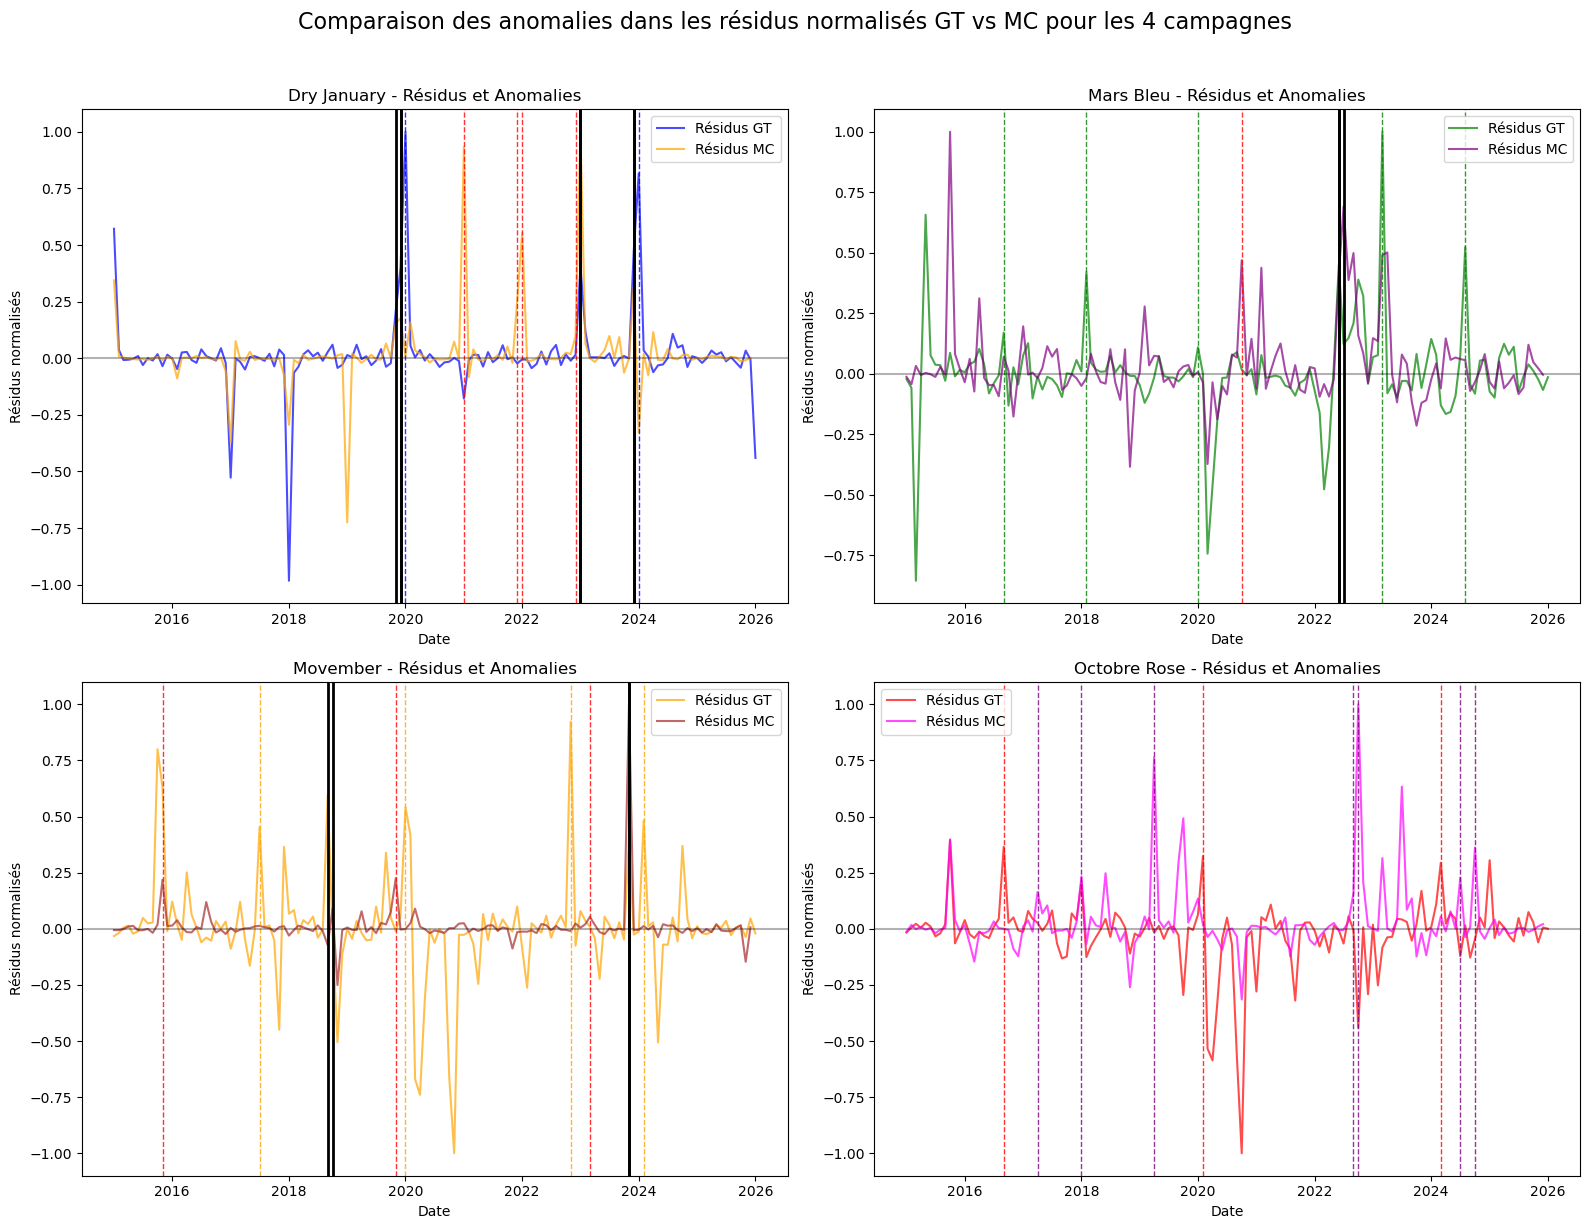

In [48]:
# Détection des anomalies dans les résidus pour chaque campagne
anomalies_dry_gt = detect_anomalies(residual_dry_gt)
anomalies_dry_mc = detect_anomalies(residual_dry_mc)

anomalies_ma_gt = detect_anomalies(residual_ma_gt)
anomalies_ma_mc = detect_anomalies(residual_ma_mc)

anomalies_mov_gt = detect_anomalies(residual_mov_gt)
anomalies_mov_mc = detect_anomalies(residual_mov_mc)

anomalies_oc_gt = detect_anomalies(residual_oc_gt)
anomalies_oc_mc = detect_anomalies(residual_oc_mc)

# Fonction pour obtenir les dates communes
def get_common_dates(anomalies_gt, anomalies_mc, max_diff_days=30):
    common_gt = set()
    common_mc = set()
    for date_gt in anomalies_gt:
        for date_mc in anomalies_mc:
            if abs((date_gt - date_mc).days) <= max_diff_days:
                common_gt.add(date_gt)
                common_mc.add(date_mc)
    return common_gt, common_mc

common_dry_gt, common_dry_mc = get_common_dates(anomalies_dry_gt, anomalies_dry_mc)
common_ma_gt, common_ma_mc = get_common_dates(anomalies_ma_gt, anomalies_ma_mc)
common_mov_gt, common_mov_mc = get_common_dates(anomalies_mov_gt, anomalies_mov_mc)
common_oc_gt, common_oc_mc = get_common_dates(anomalies_oc_gt, anomalies_oc_mc)

# Affichage des anomalies dans un graphique comparatif
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Dry January
axes[0, 0].plot(residual_dry_gt.index, residual_dry_gt / residual_dry_gt.abs().max(), label="Résidus GT", color="blue", alpha=0.7)
axes[0, 0].plot(residual_dry_mc.index, residual_dry_mc / residual_dry_mc.abs().max(), label="Résidus MC", color="orange", alpha=0.7)
# Anomalies uniques GT
for date in [d for d in anomalies_dry_gt if d not in common_dry_gt]:
    axes[0, 0].axvline(x=date, color="blue", linestyle="--", linewidth=1, alpha=0.8)
# Anomalies uniques MC
for date in [d for d in anomalies_dry_mc if d not in common_dry_mc]:
    axes[0, 0].axvline(x=date, color="red", linestyle="--", linewidth=1, alpha=0.8)
# Anomalies communes
for date in common_dry_gt:
    axes[0, 0].axvline(x=date, color="black", linestyle="-", linewidth=2)
for date in common_dry_mc:
    axes[0, 0].axvline(x=date, color="black", linestyle="-", linewidth=2)
axes[0, 0].set_title("Dry January - Résidus et Anomalies")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Résidus normalisés")
axes[0, 0].legend()
axes[0, 0].axhline(y=0, color="black", linestyle="-", alpha=0.3)

# Mars Bleu
axes[0, 1].plot(residual_ma_gt.index, residual_ma_gt / residual_ma_gt.abs().max(), label="Résidus GT", color="green", alpha=0.7)
axes[0, 1].plot(residual_ma_mc.index, residual_ma_mc / residual_ma_mc.abs().max(), label="Résidus MC", color="purple", alpha=0.7)
for date in [d for d in anomalies_ma_gt if d not in common_ma_gt]:
    axes[0, 1].axvline(x=date, color="green", linestyle="--", linewidth=1, alpha=0.8)
for date in [d for d in anomalies_ma_mc if d not in common_ma_mc]:
    axes[0, 1].axvline(x=date, color="red", linestyle="--", linewidth=1, alpha=0.8)
for date in common_ma_gt:
    axes[0, 1].axvline(x=date, color="black", linestyle="-", linewidth=2)
for date in common_ma_mc:
    axes[0, 1].axvline(x=date, color="black", linestyle="-", linewidth=2)
axes[0, 1].set_title("Mars Bleu - Résidus et Anomalies")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Résidus normalisés")
axes[0, 1].legend()
axes[0, 1].axhline(y=0, color="black", linestyle="-", alpha=0.3)

# Movember
axes[1, 0].plot(residual_mov_gt.index, residual_mov_gt / residual_mov_gt.abs().max(), label="Résidus GT", color="orange", alpha=0.7)
axes[1, 0].plot(residual_mov_mc.index, residual_mov_mc / residual_mov_mc.abs().max(), label="Résidus MC", color="brown", alpha=0.7)
for date in [d for d in anomalies_mov_gt if d not in common_mov_gt]:
    axes[1, 0].axvline(x=date, color="orange", linestyle="--", linewidth=1, alpha=0.8)
for date in [d for d in anomalies_mov_mc if d not in common_mov_mc]:
    axes[1, 0].axvline(x=date, color="red", linestyle="--", linewidth=1, alpha=0.8)
for date in common_mov_gt:
    axes[1, 0].axvline(x=date, color="black", linestyle="-", linewidth=2)
for date in common_mov_mc:
    axes[1, 0].axvline(x=date, color="black", linestyle="-", linewidth=2)
axes[1, 0].set_title("Movember - Résidus et Anomalies")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Résidus normalisés")
axes[1, 0].legend()
axes[1, 0].axhline(y=0, color="black", linestyle="-", alpha=0.3)

# Octobre Rose
axes[1, 1].plot(residual_oc_gt.index, residual_oc_gt / residual_oc_gt.abs().max(), label="Résidus GT", color="red", alpha=0.7)
axes[1, 1].plot(residual_oc_mc.index, residual_oc_mc / residual_oc_mc.abs().max(), label="Résidus MC", color="magenta", alpha=0.7)
for date in [d for d in anomalies_oc_gt if d not in common_oc_gt]:
    axes[1, 1].axvline(x=date, color="red", linestyle="--", linewidth=1, alpha=0.8)
for date in [d for d in anomalies_oc_mc if d not in common_oc_mc]:
    axes[1, 1].axvline(x=date, color="purple", linestyle="--", linewidth=1, alpha=0.8)
for date in common_oc_gt:
    axes[1, 1].axvline(x=date, color="black", linestyle="-", linewidth=2)
for date in common_oc_mc:
    axes[1, 1].axvline(x=date, color="black", linestyle="-", linewidth=2)
axes[1, 1].set_title("Octobre Rose - Résidus et Anomalies")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Résidus normalisés")
axes[1, 1].legend()
axes[1, 1].axhline(y=0, color="black", linestyle="-", alpha=0.3)

plt.suptitle("Comparaison des anomalies dans les résidus normalisés GT vs MC pour les 4 campagnes", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [47]:
# Liste des anomalies communes (à 1 mois près) entre GT et MC pour chaque campagne
import pandas as pd

def find_common_anomalies(anomalies_gt, anomalies_mc, max_diff_days=30):
    common = []
    for date_gt in anomalies_gt:
        for date_mc in anomalies_mc:
            diff = abs((date_gt - date_mc).days)
            if diff <= max_diff_days:
                common.append((date_gt, date_mc, diff))
    return common

common_dry = find_common_anomalies(anomalies_dry_gt, anomalies_dry_mc)
common_ma = find_common_anomalies(anomalies_ma_gt, anomalies_ma_mc)
common_mov = find_common_anomalies(anomalies_mov_gt, anomalies_mov_mc)
common_oc = find_common_anomalies(anomalies_oc_gt, anomalies_oc_mc)

print("Anomalies communes (GT et MC à 1 mois près) :")
print("\nDry January:")
for gt, mc, diff in common_dry:
    print(f"  GT: {gt.strftime('%Y-%m-%d')}, MC: {mc.strftime('%Y-%m-%d')}, Diff: {diff} jours")

print("\nMars Bleu:")
for gt, mc, diff in common_ma:
    print(f"  GT: {gt.strftime('%Y-%m-%d')}, MC: {mc.strftime('%Y-%m-%d')}, Diff: {diff} jours")

print("\nMovember:")
for gt, mc, diff in common_mov:
    print(f"  GT: {gt.strftime('%Y-%m-%d')}, MC: {mc.strftime('%Y-%m-%d')}, Diff: {diff} jours")

print("\nOctobre Rose:")
for gt, mc, diff in common_oc:
    print(f"  GT: {gt.strftime('%Y-%m-%d')}, MC: {mc.strftime('%Y-%m-%d')}, Diff: {diff} jours")

Anomalies communes (GT et MC à 1 mois près) :

Dry January:
  GT: 2019-11-01, MC: 2019-12-01, Diff: 30 jours
  GT: 2019-12-01, MC: 2019-12-01, Diff: 0 jours
  GT: 2023-01-01, MC: 2023-01-01, Diff: 0 jours
  GT: 2023-12-01, MC: 2023-12-01, Diff: 0 jours

Mars Bleu:
  GT: 2022-06-01, MC: 2022-06-01, Diff: 0 jours
  GT: 2022-06-01, MC: 2022-07-01, Diff: 30 jours

Movember:
  GT: 2018-09-01, MC: 2018-10-01, Diff: 30 jours
  GT: 2023-11-01, MC: 2023-11-01, Diff: 0 jours

Octobre Rose:
